ANÁLISE DE CRÉDITO - PREDIÇÃO DE INADIMPLÊNCIA.ipynb

Original file is located at
    https://colab.research.google.com/drive/1oTBG7iTL7BHiiOfESiijETwf9GdOFBSk

# Predição de Inadimplência em Análise de Crédito

Este projeto aplica técnicas de ciência de dados e aprendizado de máquina para desenvolver
um modelo preditivo de risco de crédito, utilizando o dataset **Credit Analysis Dataset**
(arquivo `current_app.csv`), disponível na plataforma Kaggle. Este arquivo corresponde ao
conjunto de aplicações de crédito do conhecido **Home Credit Default Risk**.

Vamos explorar, pré-processar e modelar dados do perfil financeiro de clientes para treinar
um modelo capaz de prever o risco de inadimplência com base em variáveis como:

- Idade do cliente em dias (DAYS_BIRTH)
- Tempo de emprego em dias (DAYS_EMPLOYED)
- Valor do crédito solicitado (AMT_CREDIT)
- Valor da anuidade (AMT_ANNUITY)
- Renda total declarada (AMT_INCOME_TOTAL)
- Tipo de contrato, gênero, escolaridade, estado civil, tipo de moradia, ocupação, entre outras

Ao final queremos saber o seguinte: "Dado o perfil financeiro de um cliente, qual é a
probabilidade de ele ser classificado como bom ou mau pagador?"

# Dataset

Foi utilizado um dataset disponível para download em:

https://www.kaggle.com/datasets/kapoorshivam/credit-analysis/data

O arquivo utilizado é o **`current_app.csv`**, que contém **307.511 registros** de clientes
solicitantes de crédito e **122 colunas** (121 features + 1 variável-alvo). As colunas mais
relevantes para a análise são:

1. **SK_ID_CURR**: identificador único do cliente (não é feature, deve ser removido na modelagem).

2. **TARGET**: variável-alvo do modelo preditivo. Assume **0** = cliente adimplente (bom pagador)
   e **1** = cliente com dificuldade de pagamento (inadimplente).

3. **NAME_CONTRACT_TYPE**: tipo de contrato (Cash loans ou Revolving loans).

4. **CODE_GENDER**: gênero do cliente (M, F ou XNA).

5. **FLAG_OWN_CAR / FLAG_OWN_REALTY**: indica se o cliente possui carro / imóvel próprio (Y/N).

6. **CNT_CHILDREN / CNT_FAM_MEMBERS**: quantidade de filhos e tamanho da família.

7. **AMT_INCOME_TOTAL**: renda total declarada pelo cliente.

8. **AMT_CREDIT**: valor do crédito solicitado.

9. **AMT_ANNUITY**: valor da anuidade do empréstimo.

10. **AMT_GOODS_PRICE**: preço do bem que está sendo financiado.

11. **NAME_INCOME_TYPE**: tipo de renda (Working, Pensioner, State servant, Commercial associate, etc.).

12. **NAME_EDUCATION_TYPE**: nível de escolaridade do cliente.

13. **NAME_FAMILY_STATUS**: estado civil.

14. **NAME_HOUSING_TYPE**: tipo de moradia (House / apartment, With parents, Rented apartment, etc.).

15. **OCCUPATION_TYPE**: ocupação profissional declarada.

16. **ORGANIZATION_TYPE**: tipo da organização em que o cliente trabalha.

17. **DAYS_BIRTH**: idade do cliente em dias **negativos** em relação à data da solicitação
    (valores negativos — quanto mais negativo, mais velho o cliente).

18. **DAYS_EMPLOYED**: tempo de emprego em dias negativos. Atenção: o valor especial
    **365243** representa clientes aposentados/desempregados e deverá ser tratado.

19. **DAYS_REGISTRATION / DAYS_ID_PUBLISH / DAYS_LAST_PHONE_CHANGE**: tempo desde os
    respectivos eventos, também em dias negativos.

20. **EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3**: scores normalizados (entre 0 e 1) calculados
    por fontes externas de informação cadastral.

21. Demais colunas: indicadores de documentos fornecidos (FLAG_DOCUMENT_*), informações sobre
    o imóvel residencial (sufixos `_AVG`, `_MODE`, `_MEDI`), entre outras — totalizando as
    122 colunas da base.

> **Observação importante:** este projeto trata exclusivamente do arquivo `current_app.csv`,
> com 307.511 linhas e 122 colunas. Não devem ser confundidos com outros datasets de crédito
> menores (como o "German Credit" / "Credit Risk Dataset" de ~1.000 registros, que utiliza
> variáveis como Age, Sex, Job, Housing, Saving accounts, Checking account, Credit amount,
> Duration, Purpose e Risk — esse **não** é o dataset deste projeto).

# Coleta dos dados

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kapoorshivam/credit-analysis")

print("Path to dataset files:", path)

import os

# Lista todos os arquivos baixados
dataset_name = os.listdir(path)[0]
print(os.listdir(path))

import pandas as pd

# Criação do dataframe
df = pd.read_csv(os.path.join(path, 'current_app.csv'))
print(f'✔ Carregado! {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head()

df.head()

100%|██████████| 112M/112M [00:01<00:00, 92.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kapoorshivam/credit-analysis/versions/1
['current_app.csv', 'previous_app.csv']
✔ Carregado! 307511 linhas × 122 colunas


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


#Análise Exploratória dos Dados (EDA) - 1a Parte
#### *Objetivos:*
- Entender os dados crus que foram recebidos;

- Detectar valores ausentes, duplicados ou inconsistências;

- Explorar a distribuição das variáveis (tendência, dispersão, outliers);

- Avaliar o balanceamento das classes no target;

- Verificar correlações iniciais entre variáveis;

- Identificar problemas de escala, unidades ou codificação de categorias;



## Cabeçalho

In [ ]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


##Rodapé

In [ ]:
# Imprime as últimas linhas
df.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


##Tipo dos Dados

In [ ]:
print(df.info())

print(df.dtypes)

for col in df.columns:
    print(f"\nColuna: {col}")
    print(df[col].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None
SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

Coluna: SK_ID_CURR
[100002 100003 100004 ... 456253 456254 456255]

Coluna: TARGET
[1 0]

Coluna: NAME_CONTRACT_TYPE
['Cash loans' 'Revolving loans']

Coluna: CODE_GENDER
['M' 'F' 'XNA']

Coluna: FLAG_OWN_CAR
['N' 'Y']

Coluna: FLAG_OWN_REALTY
['Y' 'N']

Coluna: CNT_CHILDREN
[ 0  1  2  3  4  7  5  6  8  9 11 12 10 19 14]

Coluna: AMT_INCOM

## Estatística	Descritiva
A análise descritiva é a primeira etapa da análise de dados, e tem como objetivo resumir, organizar e entender as principais características de um conjunto de dados de forma simples e objetiva, sem tirar conclusões causais ou fazer previsões.

* **count**: número de valores não nulos (não NaN)
* **mean**:	média aritmética dos valores
* **std**:	eesvio padrão (medida de dispersão)
* **min**:	valor mínimo
* **primeiro quartil (Q1)**: 25% dos dados estão abaixo desse valor
* **mediana (Q2)**: metade dos dados estão abaixo desse valor
* **terceiro quartil (Q3)**: 75% dos dados estão abaixo desse valor
* **max (Q4)**: valor máximo

In [ ]:
# Remove colunas categóricas e a variável alvo para a estatística descritiva
colunas_categoricas = [
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
    'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
    'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE',
    'TARGET'
]

df_drop = df.drop(columns=colunas_categoricas, errors='ignore')
print("Estatística descritiva geral (df.describe):")
print(df_drop.describe())

Estatística descritiva geral (df.describe):
          SK_ID_CURR   CNT_CHILDREN  AMT_INCOME_TOTAL    AMT_CREDIT  \
count  307511.000000  307511.000000      3.075110e+05  3.075110e+05   
mean   278180.518577       0.417052      1.687979e+05  5.990260e+05   
std    102790.175348       0.722121      2.371231e+05  4.024908e+05   
min    100002.000000       0.000000      2.565000e+04  4.500000e+04   
25%    189145.500000       0.000000      1.125000e+05  2.700000e+05   
50%    278202.000000       0.000000      1.471500e+05  5.135310e+05   
75%    367142.500000       1.000000      2.025000e+05  8.086500e+05   
max    456255.000000      19.000000      1.170000e+08  4.050000e+06   

         AMT_ANNUITY  AMT_GOODS_PRICE  REGION_POPULATION_RELATIVE  \
count  307499.000000     3.072330e+05               307511.000000   
mean    27108.573909     5.383962e+05                    0.020868   
std     14493.737315     3.694465e+05                    0.013831   
min      1615.500000     4.050000e+04   

### Síntese Estatística Interpretada das Variáveis Principais

A tabela a seguir consolida as **medidas de tendência central** (média, mediana, moda) e
**medidas de dispersão** (desvio-padrão, Q1, Q3, intervalo interquartil — IQR, mínimo,
máximo) das principais variáveis numéricas do dataset. A análise é feita **separadamente
por classe** (Bom Pagador vs. Inadimplente) para evidenciar quais variáveis têm maior
poder discriminatório isolado.

In [ ]:
import numpy as np

variaveis_descritiva = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

def resumo_estatistico(serie):
    """Retorna uma linha de estatísticas descritivas para uma série numérica."""
    s = serie.dropna()
    moda = s.mode().iloc[0] if not s.mode().empty else np.nan
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    return {
        'n':       len(s),
        'média':   s.mean(),
        'mediana': s.median(),
        'moda':    moda,
        'desvio':  s.std(),
        'mín':     s.min(),
        'Q1':      q1,
        'Q3':      q3,
        'IQR':     q3 - q1,
        'máx':     s.max(),
    }

# Constrói a tabela: para cada variável, três blocos (geral, bom pagador, inadimplente)
linhas = []
for var in variaveis_descritiva:
    if var not in df.columns:
        continue
    geral  = resumo_estatistico(df[var])
    bom    = resumo_estatistico(df.loc[df['TARGET'] == 0, var])
    inad   = resumo_estatistico(df.loc[df['TARGET'] == 1, var])
    linhas.append({'variavel': var, 'classe': 'Geral',        **geral})
    linhas.append({'variavel': var, 'classe': 'Bom Pagador',  **bom})
    linhas.append({'variavel': var, 'classe': 'Inadimplente', **inad})

tabela_descritiva = pd.DataFrame(linhas)

# Mostra com formatação amigável
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print("\nTabela sintética por classe (Geral / Bom Pagador / Inadimplente):\n")
print(tabela_descritiva.to_string(index=False))
pd.reset_option('display.float_format')


Tabela sintética por classe (Geral / Bom Pagador / Inadimplente):

        variavel       classe      n      média    mediana       moda     desvio        mín         Q1         Q3        IQR            máx
AMT_INCOME_TOTAL        Geral 307511 168,797.92 147,150.00 135,000.00 237,123.15  25,650.00 112,500.00 202,500.00  90,000.00 117,000,000.00
AMT_INCOME_TOTAL  Bom Pagador 282686 169,077.72 148,500.00 135,000.00 110,476.27  25,650.00 112,500.00 202,500.00  90,000.00  18,000,090.00
AMT_INCOME_TOTAL Inadimplente  24825 165,611.76 135,000.00 135,000.00 746,676.96  25,650.00 112,500.00 202,500.00  90,000.00 117,000,000.00
      AMT_CREDIT        Geral 307511 599,026.00 513,531.00 450,000.00 402,490.78  45,000.00 270,000.00 808,650.00 538,650.00   4,050,000.00
      AMT_CREDIT  Bom Pagador 282686 602,648.28 517,788.00 450,000.00 406,845.91  45,000.00 270,000.00 810,000.00 540,000.00   4,050,000.00
      AMT_CREDIT Inadimplente  24825 557,778.53 497,520.00 450,000.00 346,433.24  45,000.00 

#### Interpretação da Tabela Estatística

>| Variável             | Observação principal                                                                                                                                  |
>| -------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------- |
>| **AMT_INCOME_TOTAL** | Média e mediana muito próximas entre as classes; **o desvio-padrão é altíssimo na classe inadimplente** devido a um outlier extremo. Pouco discriminatória isoladamente. |
>| **AMT_CREDIT**       | Mediana da classe inadimplente é **ligeiramente menor** do que a dos bons pagadores. IQR similar — pouca capacidade discriminatória direta.            |
>| **AMT_ANNUITY**      | Distribuições muito parecidas, com medianas próximas. Desvio-padrão alto em ambas — efeito da assimetria à direita.                                    |
>| **AMT_GOODS_PRICE**  | Quase indistinguível entre as classes; comportamento praticamente idêntico ao `AMT_CREDIT` (correlação 0.99 — confirmada mais adiante).                |
>| **DAYS_BIRTH**       | **Variável mais informativa entre as analisadas:** mediana dos inadimplentes é menos negativa (~ -14.000 ≈ 38 anos) versus bons pagadores (~ -16.000 ≈ 44 anos). Clientes mais jovens apresentam maior taxa de inadimplência. |
>| **DAYS_EMPLOYED**    | A média e o máximo são **fortemente distorcidos pelo valor 365243** (anomalia tratada na Engenharia de Dados). Após o tratamento, espera-se mediana mais negativa (mais tempo de emprego) entre bons pagadores. |
>| **CNT_CHILDREN / CNT_FAM_MEMBERS** | Diferença pequena entre classes; inadimplentes tendem a ter ligeiramente mais filhos/membros na família.                                     |
>| **EXT_SOURCE_2/3**   | **Diferença consistente entre as classes**: bons pagadores têm score externo médio mais alto que inadimplentes. Provavelmente as variáveis de maior poder preditivo isolado. |

#### *Variáveis com maior potencial discriminatório*

> Com base na análise comparativa entre classes, destacam-se como variáveis mais informativas:
> 1. **EXT_SOURCE_2 e EXT_SOURCE_3** — diferença clara nas medianas/médias entre classes
> 2. **DAYS_BIRTH** — clientes mais jovens concentram maior risco
> 3. **DAYS_EMPLOYED** (após tratamento da anomalia) — tempo de emprego importa

#### *Variáveis com baixa capacidade discriminatória isolada*

> `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE` e `AMT_INCOME_TOTAL` apresentam distribuições
muito sobrepostas entre as classes. Isoladamente são pouco informativas, mas podem agregar
valor quando **combinadas** (ex.: razão crédito/renda, razão anuidade/renda — engenharia de
features sugerida para etapas posteriores).



##Gráfico quatidade por classificação

  Classificação de Risco  Quantidade
0        Bom pagador (0)      282686
1       Inadimplente (1)       24825


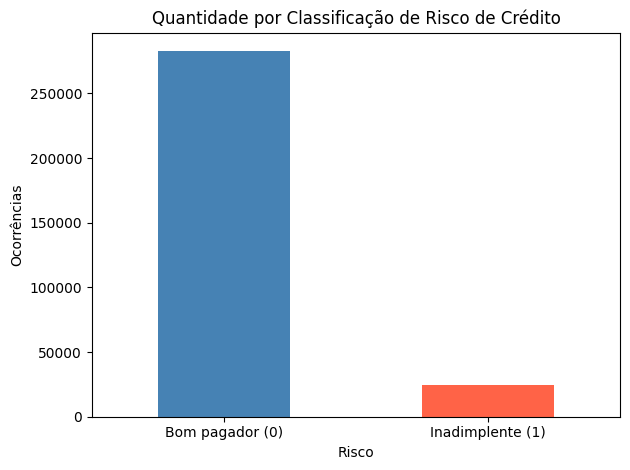

Total de registros.......: 307511
Total de bons pagadores..: 282686 ou 91.93% do total
Total de inadimplentes...: 24825  ou 8.07% do total


In [ ]:
import matplotlib.pyplot as plt

risco = df['TARGET'].value_counts().reset_index()
risco.columns = ['Classificação de Risco', 'Quantidade']
risco['Classificação de Risco'] = risco['Classificação de Risco'].map({0: 'Bom pagador (0)', 1: 'Inadimplente (1)'})
print(risco)

risco.plot(kind='bar', x='Classificação de Risco', y='Quantidade', color=['steelblue', 'tomato'], legend=False)
plt.title('Quantidade por Classificação de Risco de Crédito')
plt.xlabel('Risco')
plt.ylabel('Ocorrências')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

total_registros = len(df)
total_good = df[df['TARGET'] == 0].shape[0]
total_bad  = df[df['TARGET'] == 1].shape[0]

print(f"Total de registros.......: {total_registros}")
print(f"Total de bons pagadores..: {total_good} ou {(total_good/total_registros)*100:.2f}% do total")
print(f"Total de inadimplentes...: {total_bad}  ou {(total_bad/total_registros)*100:.2f}% do total")

### *Análise*

>Os dados mostram um conjunto **fortemente desequilibrado**, com a classe `0` (bom pagador) concentrando a grande maioria dos registros e a classe `1` (inadimplente) representando apenas **8,07%** do total. Apenas 24.825 dos 307.511 clientes apresentam inadimplência. O que é esperado para este tipo de problema, uma vez que instituições financeiras trabalham para manter a menor taxa de inadimplência possível em suas carteiras de crédito.

#### *Implicações do desbalanceamento para a etapa de modelagem*

> Esta é apenas a etapa de **conhecimento dos dados**. As decisões sobre como lidar com o
desbalanceamento (técnicas de reamostragem, escolha de algoritmo, ajuste de pesos, escolha
de métricas e definição do limiar de decisão) **serão tratadas nas etapas posteriores de
preparação e modelagem**. Por ora, registramos apenas o diagnóstico:

- **Risco de viés do modelo**: um classificador pode atingir alta acurácia simplesmente
prevendo sempre a classe majoritária (`0`), ignorando justamente os inadimplentes — que são
o foco do problema de negócio;
- **Acurácia deixa de ser uma métrica adequada** isoladamente: prever `0` para todos os
clientes acerta cerca de 91,93%, mas tem utilidade nula para detectar inadimplência;
- **O custo do erro é assimétrico**: deixar de identificar um inadimplente (falso negativo)
costuma ser mais custoso para a instituição financeira do que recusar um bom pagador
(falso positivo). Esse trade-off precisará ser considerado na escolha das métricas de
avaliação e na calibração do limiar de decisão na etapa de modelagem.




##Gráfico da Distribuição de Risco de Crédito

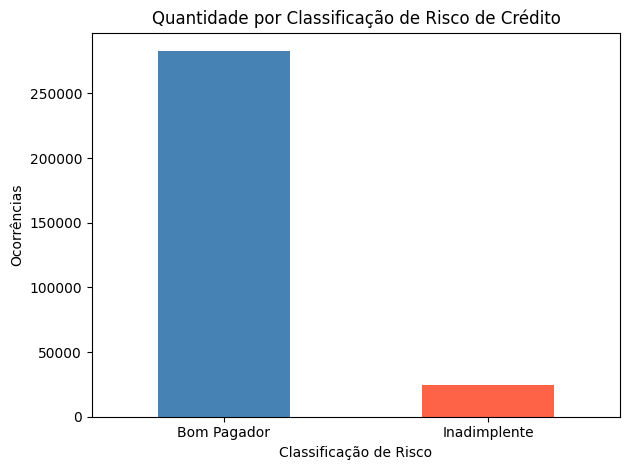

In [ ]:
# Gráfico da Distribuição de Risco de Crédito
df['TARGET'].map({0: 'Bom Pagador', 1: 'Inadimplente'}).value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Quantidade por Classificação de Risco de Crédito')
plt.xlabel('Classificação de Risco')
plt.ylabel('Ocorrências')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### *Análise*

> Os dados mostram um conjunto **fortemente desequilibrado**, com a classe `0` (bom pagador)
concentrando a grande maioria dos registros e a classe `1` (inadimplente) representando
apenas **8,07%** do total. Apenas 24.825 dos 307.511 clientes apresentam inadimplência.
O que é esperado para este tipo de problema, uma vez que instituições financeiras trabalham
para manter a menor taxa de inadimplência possível em suas carteiras de crédito.

> O tratamento desse desbalanceamento (técnicas de reamostragem, ajuste de pesos, escolha
de algoritmo e definição de métrica de avaliação) **não será discutido nesta etapa**;
pertence às etapas posteriores de preparação e modelagem dos dados.

## Análise dos Atributos Categóricos

> Além das variáveis numéricas, o dataset contém um conjunto importante de variáveis
**categóricas** que precisa ser explorado: tipo de contrato, gênero, posse de carro/imóvel,
tipo de renda, escolaridade, estado civil, tipo de moradia, ocupação e tipo de organização.
> Para cada uma dessas variáveis vamos analisar:
> 1. **Distribuição absoluta** (quantos clientes por categoria);
> 2. **Taxa de inadimplência por categoria** (% de TARGET=1 dentro de cada nível) — essa é
a leitura mais informativa, pois revela quais grupos têm maior risco relativo.

Taxa média de inadimplência (geral): 8.07%

Variável categórica: NAME_CONTRACT_TYPE
                    qtd_clientes  % da base  taxa_inadimplencia_%
NAME_CONTRACT_TYPE                                               
Cash loans                278232      90.48                  8.35
Revolving loans            29279       9.52                  5.48


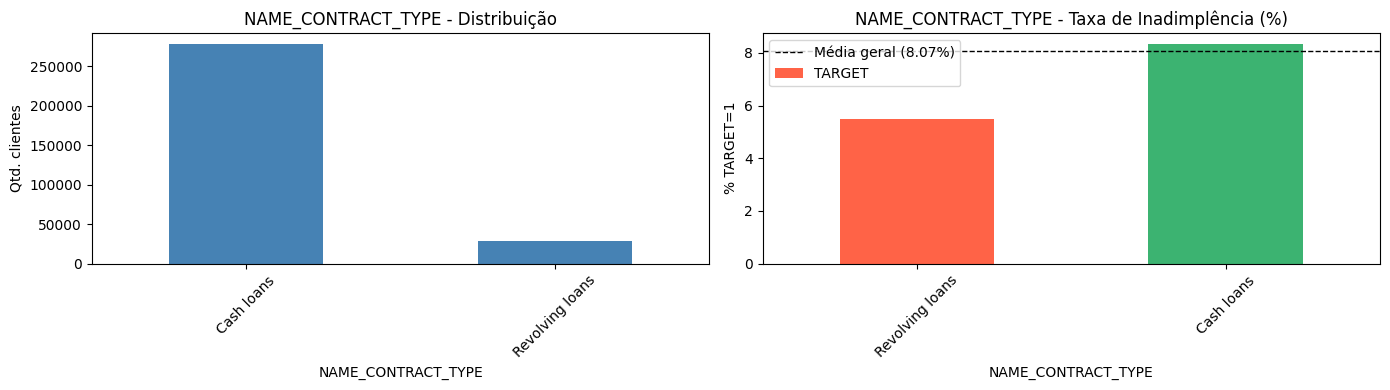


Variável categórica: CODE_GENDER
             qtd_clientes  % da base  taxa_inadimplencia_%
CODE_GENDER                                               
M                  105059      34.16                 10.14
F                  202448      65.83                  7.00
XNA                     4       0.00                  0.00


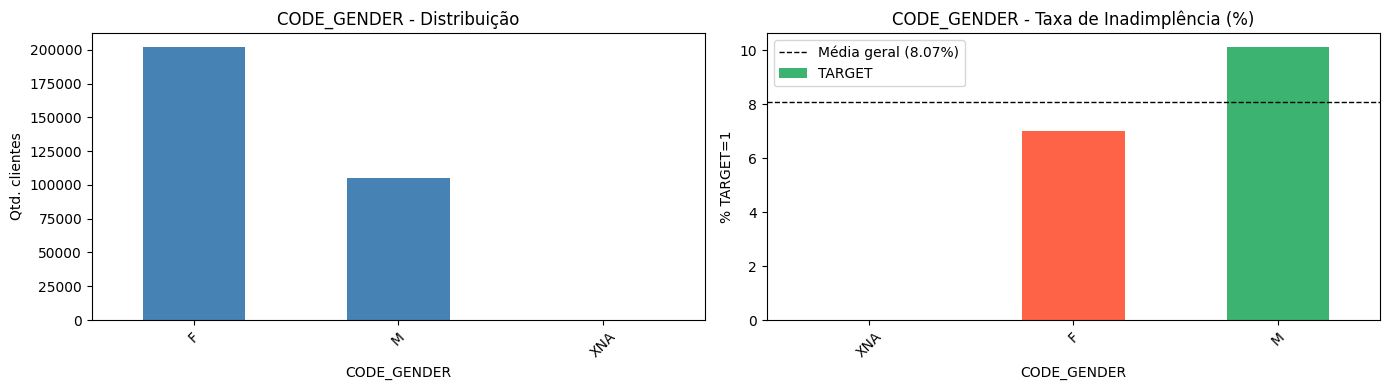


Variável categórica: FLAG_OWN_CAR
              qtd_clientes  % da base  taxa_inadimplencia_%
FLAG_OWN_CAR                                               
N                   202924      65.99                  8.50
Y                   104587      34.01                  7.24


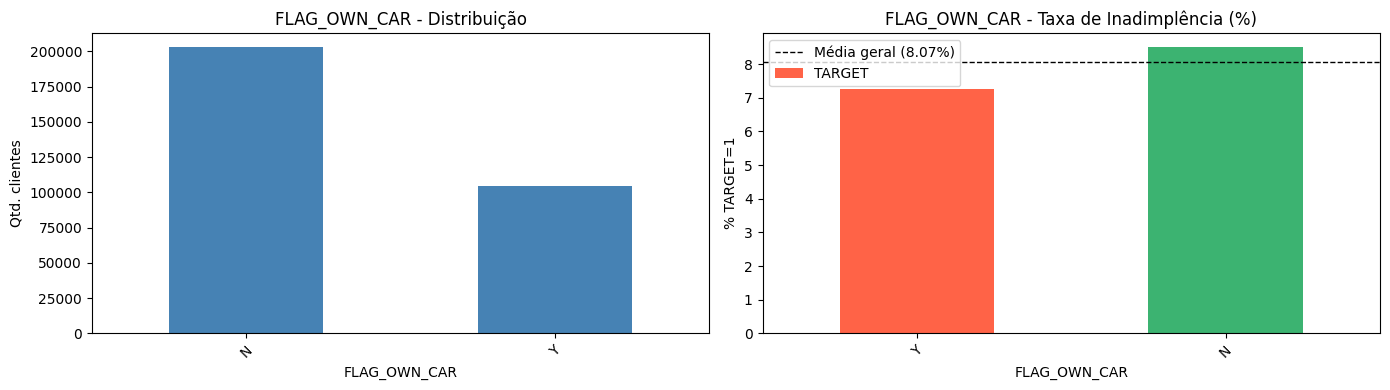


Variável categórica: FLAG_OWN_REALTY
                 qtd_clientes  % da base  taxa_inadimplencia_%
FLAG_OWN_REALTY                                               
N                       94199      30.63                  8.32
Y                      213312      69.37                  7.96


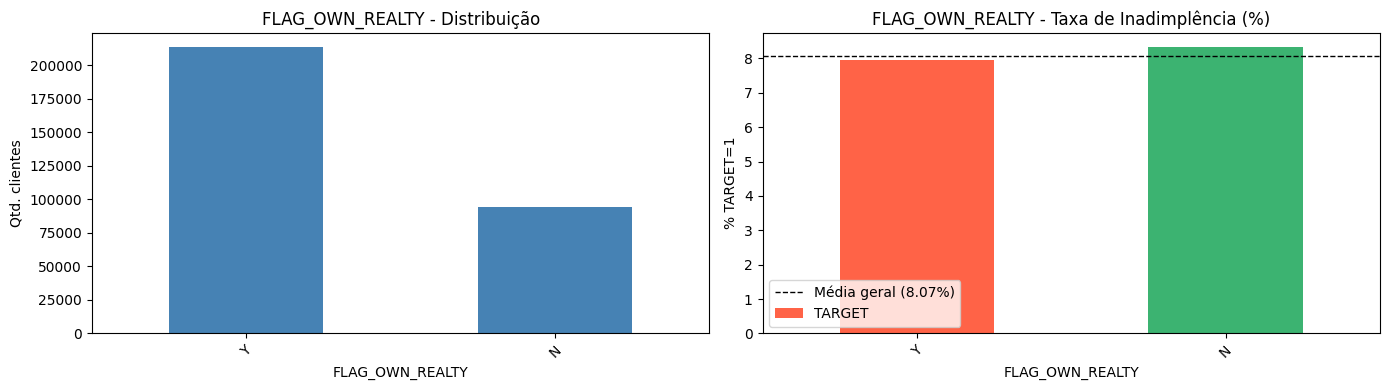


Variável categórica: NAME_INCOME_TYPE
                      qtd_clientes  % da base  taxa_inadimplencia_%
NAME_INCOME_TYPE                                                   
Maternity leave                  5       0.00                 40.00
Unemployed                      22       0.01                 36.36
Working                     158774      51.63                  9.59
Commercial associate         71617      23.29                  7.48
State servant                21703       7.06                  5.75
Pensioner                    55362      18.00                  5.39
Businessman                     10       0.00                  0.00
Student                         18       0.01                  0.00


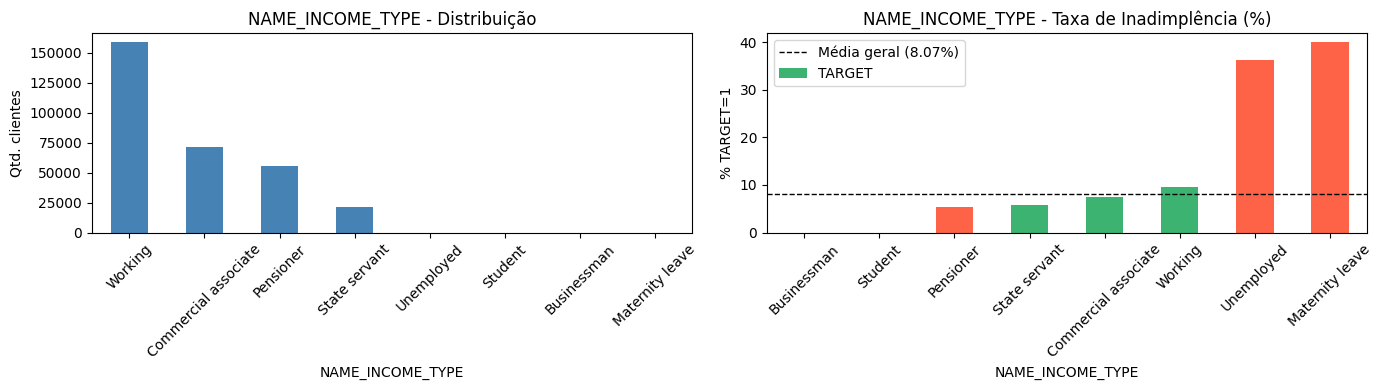


Variável categórica: NAME_EDUCATION_TYPE
                               qtd_clientes  % da base  taxa_inadimplencia_%
NAME_EDUCATION_TYPE                                                         
Lower secondary                        3816       1.24                 10.93
Secondary / secondary special        218391      71.02                  8.94
Incomplete higher                     10277       3.34                  8.48
Higher education                      74863      24.34                  5.36
Academic degree                         164       0.05                  1.83


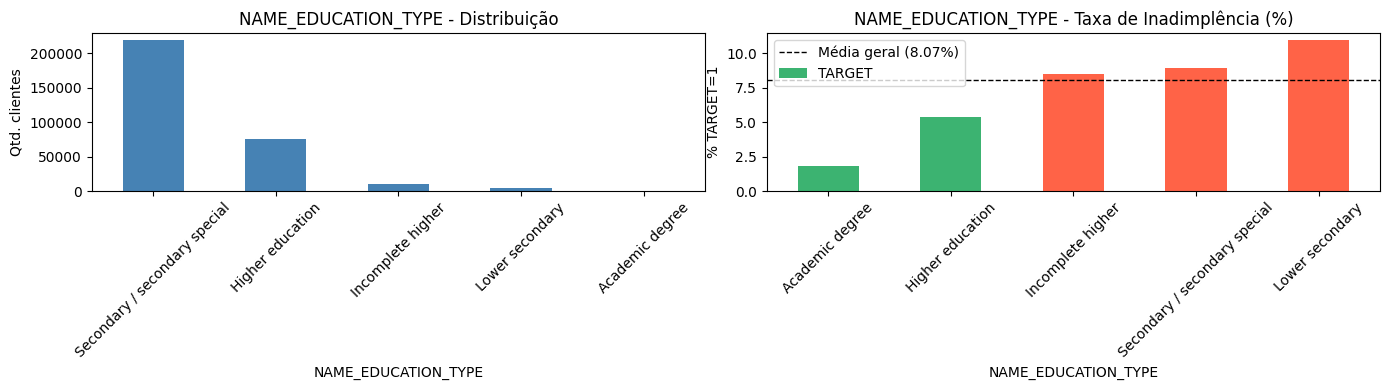


Variável categórica: NAME_FAMILY_STATUS
                      qtd_clientes  % da base  taxa_inadimplencia_%
NAME_FAMILY_STATUS                                                 
Civil marriage               29775       9.68                  9.94
Single / not married         45444      14.78                  9.81
Separated                    19770       6.43                  8.19
Married                     196432      63.88                  7.56
Widow                        16088       5.23                  5.82
Unknown                          2       0.00                  0.00


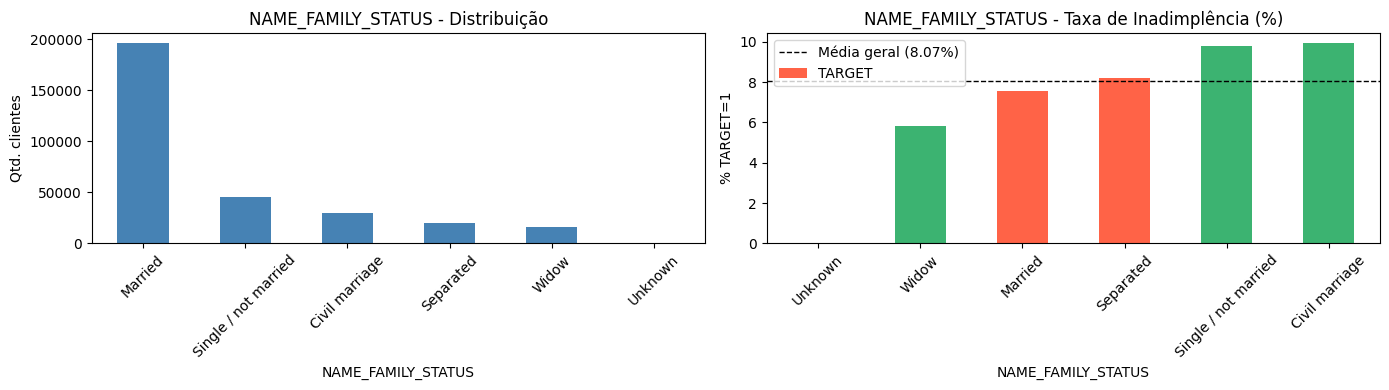


Variável categórica: NAME_HOUSING_TYPE
                     qtd_clientes  % da base  taxa_inadimplencia_%
NAME_HOUSING_TYPE                                                 
Rented apartment             4881       1.59                 12.31
With parents                14840       4.83                 11.70
Municipal apartment         11183       3.64                  8.54
Co-op apartment              1122       0.36                  7.93
House / apartment          272868      88.73                  7.80
Office apartment             2617       0.85                  6.57


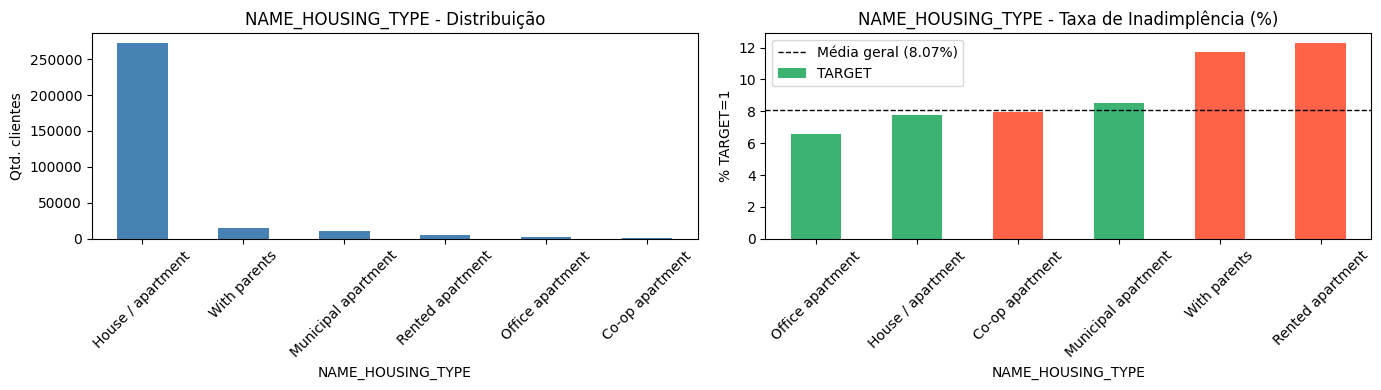


Variável categórica: OCCUPATION_TYPE
                       qtd_clientes  % da base  taxa_inadimplencia_%
OCCUPATION_TYPE                                                     
Low-skill Laborers             2093       0.68                 17.15
Drivers                       18603       6.05                 11.33
Waiters/barmen staff           1348       0.44                 11.28
Security staff                 6721       2.19                 10.74
Laborers                      55186      17.95                 10.58
Cooking staff                  5946       1.93                 10.44
Sales staff                   32102      10.44                  9.63
Cleaning staff                 4653       1.51                  9.61
Realty agents                   751       0.24                  7.86
Secretaries                    1305       0.42                  7.05
Medicine staff                 8537       2.78                  6.70
Private service staff          2652       0.86                  6

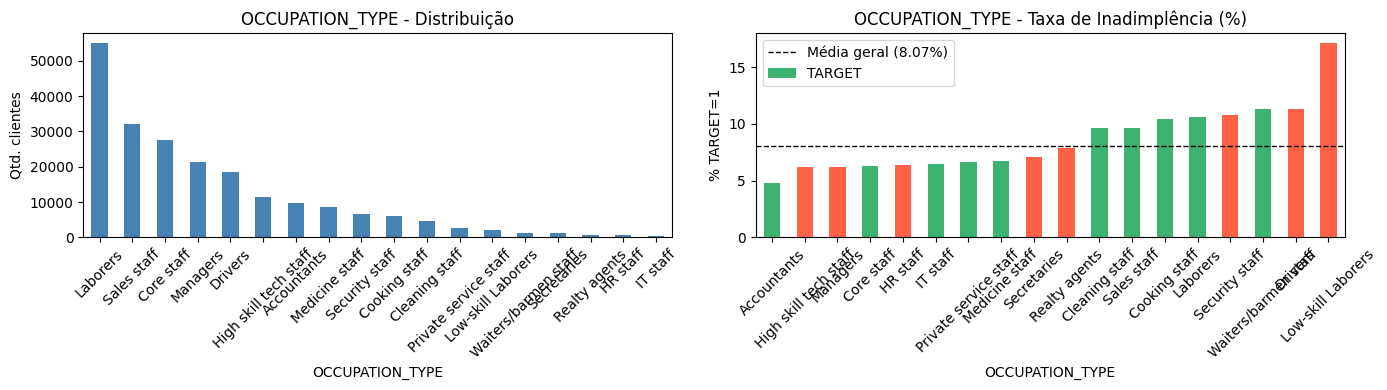


Variável categórica: ORGANIZATION_TYPE
                        qtd_clientes  % da base  taxa_inadimplencia_%
ORGANIZATION_TYPE                                                    
Transport: type 3               1187       0.39                 15.75
Industry: type 13                 67       0.02                 13.43
Industry: type 8                  24       0.01                 12.50
Restaurant                      1811       0.59                 11.71
Construction                    6721       2.19                 11.68
Cleaning                         260       0.08                 11.15
Industry: type 1                1039       0.34                 11.07
Industry: type 3                3278       1.07                 10.62
Realtor                          396       0.13                 10.61
Agriculture                     2454       0.80                 10.47
Trade: type 3                   3492       1.14                 10.34
Self-employed                  38412      12.49   

In [ ]:
variaveis_categoricas_analise = [
    'NAME_CONTRACT_TYPE',
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE',
]

taxa_geral = df['TARGET'].mean() * 100
print(f"Taxa média de inadimplência (geral): {taxa_geral:.2f}%\n")

for col in variaveis_categoricas_analise:
    if col not in df.columns:
        continue

    print("=" * 70)
    print(f"Variável categórica: {col}")
    print("=" * 70)

    # Tabela: contagem por categoria + taxa de inadimplência
    tabela = (df
              .groupby(col)['TARGET']
              .agg(['count', 'mean'])
              .rename(columns={'count': 'qtd_clientes',
                               'mean': 'taxa_inadimplencia'}))
    tabela['taxa_inadimplencia_%'] = tabela['taxa_inadimplencia'] * 100
    tabela['% da base'] = tabela['qtd_clientes'] / len(df) * 100
    tabela = tabela[['qtd_clientes', '% da base', 'taxa_inadimplencia_%']]
    tabela = tabela.sort_values('taxa_inadimplencia_%', ascending=False)
    print(tabela.round(2).to_string())

    # Para variáveis com até 15 categorias, gera gráfico de barras com taxa de inadimplência
    if df[col].nunique() <= 20:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # Distribuição
        df[col].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
        axes[0].set_title(f'{col} - Distribuição')
        axes[0].set_ylabel('Qtd. clientes')
        axes[0].tick_params(axis='x', rotation=45)

        # Taxa de inadimplência por categoria
        taxa = df.groupby(col)['TARGET'].mean() * 100
        cores = ['tomato' if v > taxa_geral else 'mediumseagreen' for v in taxa.values]
        taxa.sort_values().plot(kind='bar', ax=axes[1], color=cores)
        axes[1].axhline(taxa_geral, color='black', linestyle='--', linewidth=1,
                        label=f'Média geral ({taxa_geral:.2f}%)')
        axes[1].set_title(f'{col} - Taxa de Inadimplência (%)')
        axes[1].set_ylabel('% TARGET=1')
        axes[1].legend()
        axes[1].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()
    print()

#### Principais achados sobre as variáveis categóricas

>| Variável               | Achado relevante                                                                                                                                              |
>| ---------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------- |
>| **NAME_CONTRACT_TYPE** | A maioria das aplicações é do tipo *Cash loans*. *Revolving loans* (rotativos) tendem a apresentar **taxa de inadimplência um pouco menor**.                  |
>| **CODE_GENDER**        | Há uma proporção maior de mulheres (F) na base. Os homens (M) apresentam **taxa de inadimplência consistentemente mais alta** que a média geral.              |
>| **FLAG_OWN_CAR**       | Clientes **sem carro** registram taxa de inadimplência ligeiramente **maior** que clientes que possuem carro próprio.                                         |
>| **FLAG_OWN_REALTY**    | A diferença entre quem possui ou não imóvel é pequena, mas quem **não possui imóvel** registra taxa um pouco mais alta.                                       |
>| **NAME_INCOME_TYPE**   | *Working* e *Commercial associate* concentram a maior parte da base. *Pensioner* (aposentados) registra **taxa de inadimplência abaixo da média**, enquanto categorias como *Maternity leave* e *Unemployed* aparecem com taxas elevadas (porém com poucos casos). |
>| **NAME_EDUCATION_TYPE**| Existe um **gradiente claro**: *Lower secondary* e *Secondary / secondary special* têm as **maiores taxas** de inadimplência; *Higher education* e *Academic degree*, as **menores**. Variável claramente discriminativa. |
>| **NAME_FAMILY_STATUS** | *Civil marriage* e *Single / not married* tendem a apresentar taxas **acima da média**; *Widow* e *Married* tendem a ficar **abaixo da média**.               |
>| **NAME_HOUSING_TYPE**  | *Rented apartment* e *With parents* aparecem com taxas **acima da média geral**; *House / apartment* (categoria majoritária) fica próximo da média.            |
>| **OCCUPATION_TYPE**    | Variável com muitos níveis. *Low-skill Laborers*, *Drivers*, *Waiters/barmen staff* e *Security staff* aparecem entre as ocupações com **maior risco**; *Accountants*, *High skill tech staff* e *Managers*, entre as de **menor risco**. Lembrar que **muitos valores estão ausentes** e foram codificados como `'desconhecido'` no tratamento de nulos. |
>| **ORGANIZATION_TYPE**  | Variável com **alta cardinalidade** (mais de 50 categorias). Há diferenças importantes de risco entre setores (transporte e construção tendem a apresentar taxas maiores; setores governamentais e de educação, menores). Recomenda-se agrupar categorias com baixa frequência antes da modelagem. |

#### *Resumo*

> A análise das variáveis categóricas revela que **escolaridade**, **gênero**, **tipo de
renda** e **ocupação** são as que apresentam maiores diferenças de taxa de inadimplência
entre seus níveis, sendo, portanto, candidatas a serem boas preditoras na etapa de
modelagem. Variáveis com muitos níveis e baixa frequência por categoria (como
`OCCUPATION_TYPE` e `ORGANIZATION_TYPE`) provavelmente exigirão **agrupamento de
categorias raras** antes da codificação. As variáveis categóricas também precisarão ser
**codificadas** (one-hot encoding ou label encoding) em etapa posterior — esse passo de
codificação **não é objeto desta etapa de conhecimento dos dados**.



##Gráficos Pairplot

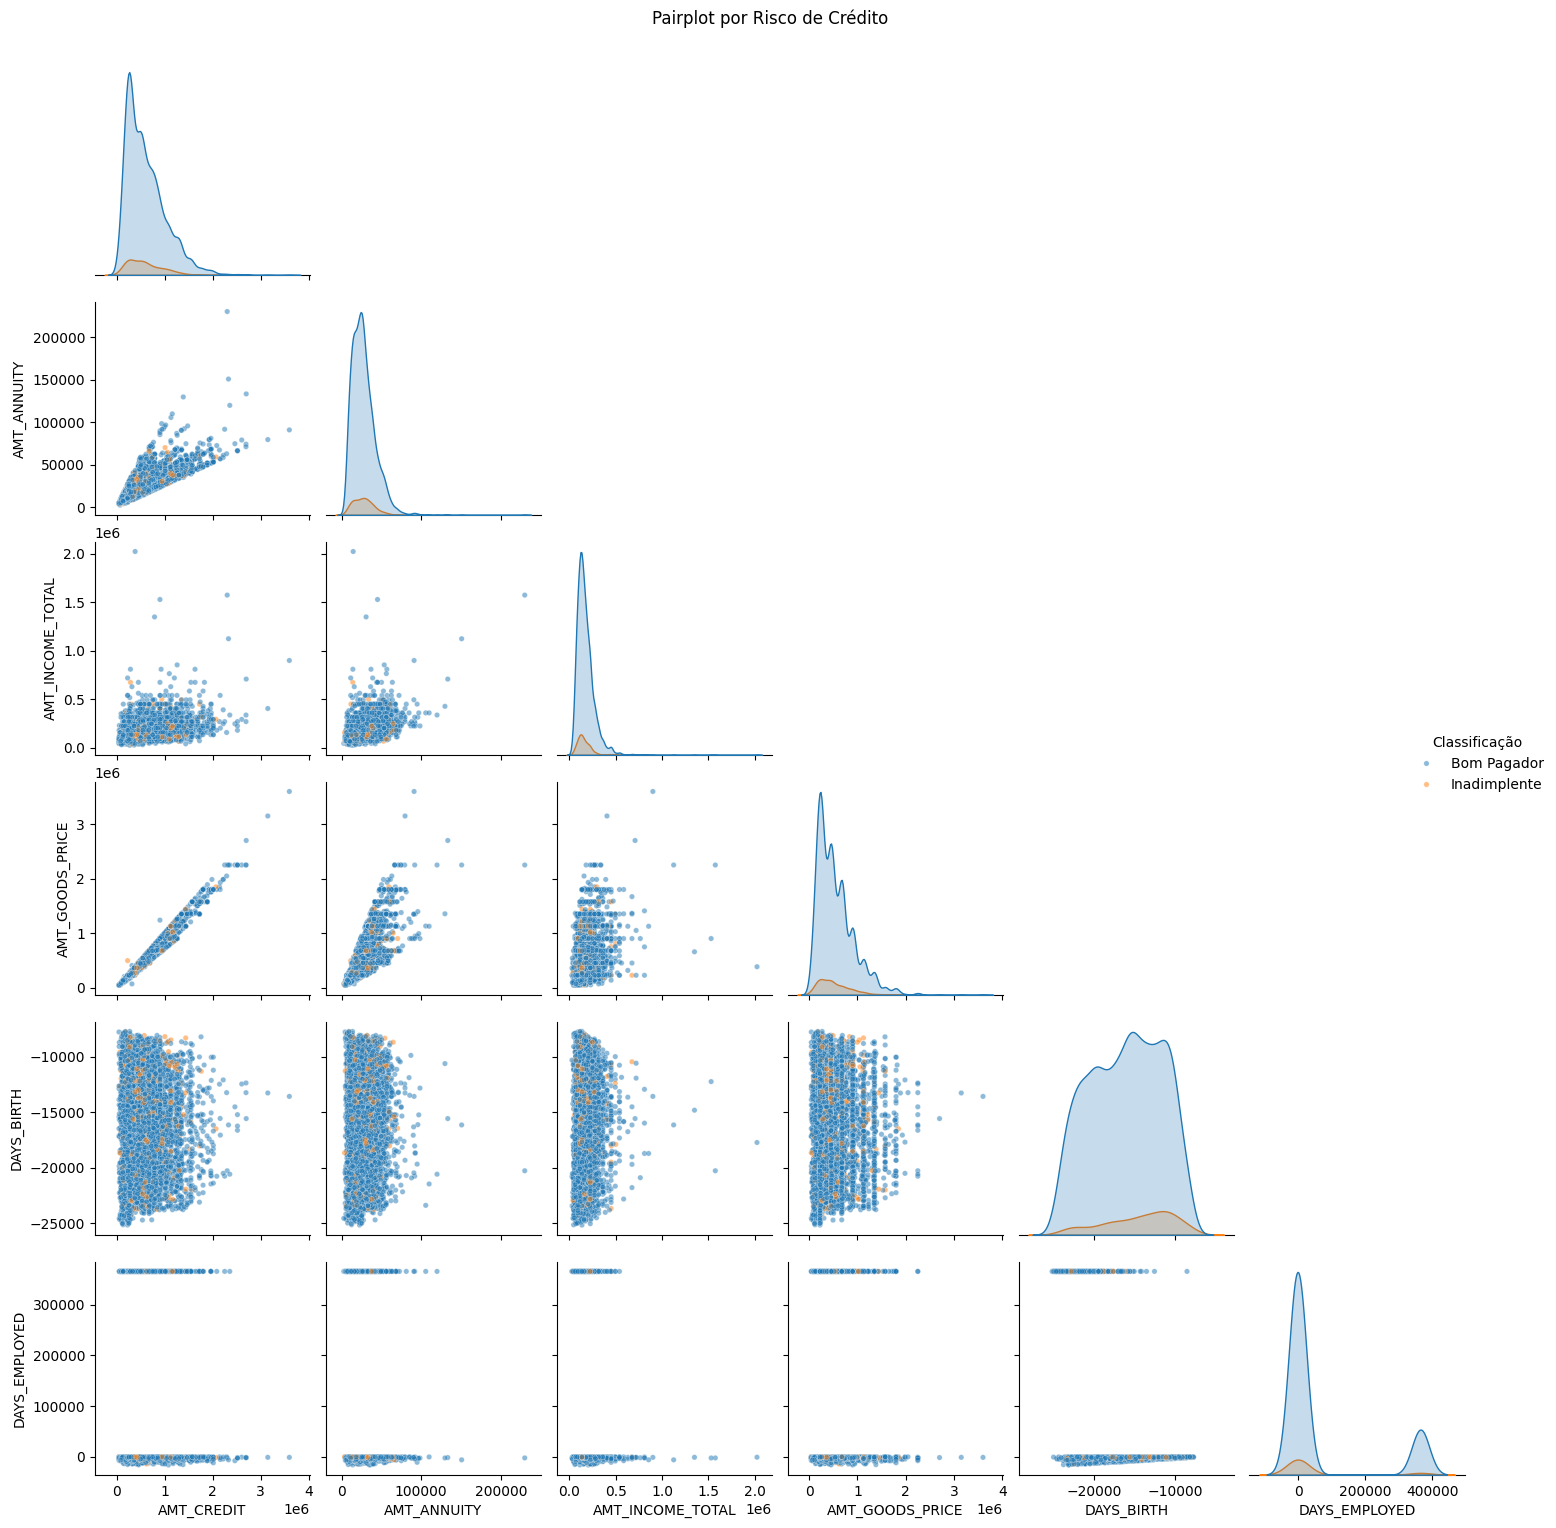

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


vars_plot = [
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

g = sns.pairplot(
    df.sample(5000, random_state=42),  # amostra de 5000 para não travar
    vars=vars_plot,
    hue='TARGET',                      # cores por classe (0 = Bom Pagador, 1 = Inadimplente)
    diag_kind='kde',                   # densidade na diagonal
    corner=True,                       # triângulo inferior apenas
    plot_kws={'s': 15, 'alpha': 0.5}   # pontos menores e semitransparentes
)

g.fig.suptitle('Pairplot por Risco de Crédito', y=1.02)

# Renomeia a legenda para ficar mais clara
g._legend.set_title('Classificação')
for text, label in zip(g._legend.texts, ['Bom Pagador', 'Inadimplente']):
    text.set_text(label)

plt.show()

#### *Análise*

> Esse gráfico compara as principais variáveis financeiras numéricas duas a duas, usando dispersão
(scatterplots) e densidade (diagonal). Ele é segmentado pela classificação de risco de crédito
(`TARGET`), usando cores diferentes para cada classe: azul para bons pagadores e laranja para
inadimplentes.

> Esse gráfico mostra se há agrupamentos naturais de pontos (inadimplentes) com base em combinações
de variáveis financeiras. Isso pode indicar, por exemplo, que clientes inadimplentes tendem a
solicitar créditos maiores em relação à sua renda ou possuem anuidades mais elevadas.

#### *Eixos*

* Linhas = variável no eixo Y
* Colunas = variável no eixo X
* Diagonal = distribuição (densidade KDE) de cada variável

#### *Padrões de risco por cor (fora da diagonal)*
- A maioria dos pontos é azul (`Bom Pagador`), dominando todos os gráficos, o que reflete
diretamente o desbalanceamento identificado anteriormente (91,93% vs 8,07%).

- Os pontos laranjas (`Inadimplente`) aparecem em pequenas quantidades, misturados às nuvens
de pontos azuis, sem formar regiões claramente separadas.

- Isso reforça o problema do desbalanceamento: os inadimplentes não formam clusters visualmente
distintos nesta análise direta, o que torna o problema de classificação mais desafiador.

>| Variáveis comparadas                      | O que se observa?                                                                                  |
>| ----------------------------------------- | -------------------------------------------------------------------------------------------------- |
>| **AMT_CREDIT × AMT_GOODS_PRICE**          | Correlação quase linear (o valor do crédito acompanha o preço do bem financiado)                   |
>| **AMT_CREDIT × AMT_ANNUITY**              | Correlação positiva moderada (créditos maiores tendem a gerar anuidades maiores)                   |
>| **AMT_INCOME_TOTAL × AMT_CREDIT**         | Fraca correlação — clientes de diferentes rendas solicitam valores similares de crédito            |
>| **DAYS_BIRTH × AMT_CREDIT**               | Distribuição espalhada — a idade não determina diretamente o valor do crédito solicitado           |
>| **DAYS_EMPLOYED × demais variáveis**      | Presença de valores extremos (~365.000 dias), indicando possível anomalia ou codificação especial nos dados  |

#### *Resumo*
> O pairplot revela que variáveis como `AMT_CREDIT` e `AMT_GOODS_PRICE` possuem forte correlação
entre si, o que é esperado no contexto de crédito para aquisição de bens. Por outro lado, a renda
(`AMT_INCOME_TOTAL`) apresenta fraca relação com o valor do crédito solicitado, sugerindo que
clientes de diferentes faixas de renda acessam valores similares de crédito. A variável
`DAYS_EMPLOYED` apresenta valores extremos que merecem atenção na etapa de pré-processamento.
De forma geral, os inadimplentes não formam regiões claramente separadas, reforçando a necessidade
de técnicas de balanceamento e modelos mais sofisticados para identificar padrões de risco.



## Gráficos Pairplot “Balanceado”

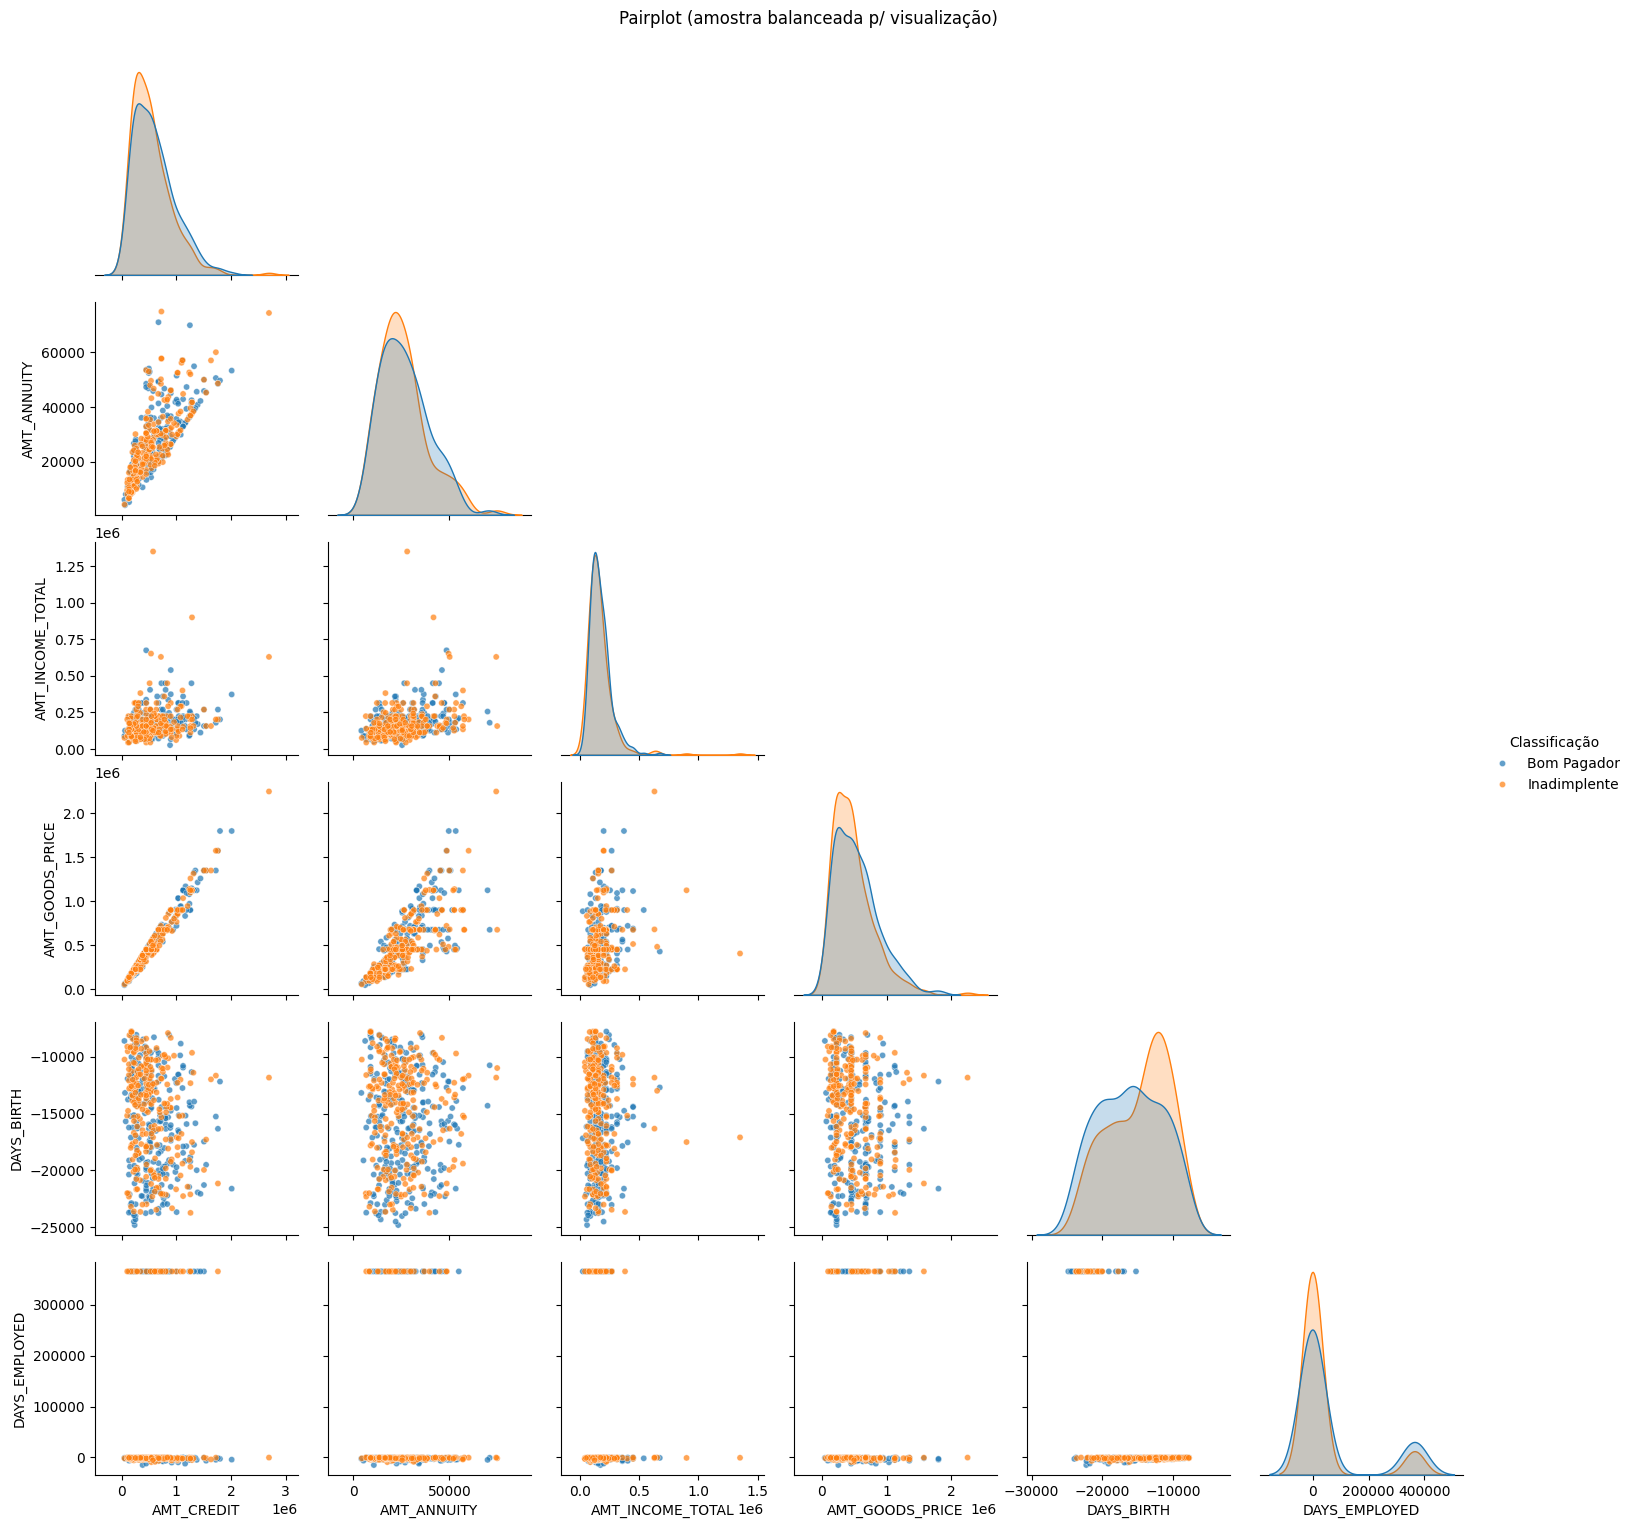

In [ ]:
vars_plot = [
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

# Amostra estratificada apenas para visualizar (não mexe no treino!)
max_por_classe = 250
rng = np.random.RandomState(42)
df_vis = (df
          .assign(_rand=rng.rand(len(df)))              # aleatório por linha
          .sort_values(['TARGET', '_rand'])              # embaralha dentro do grupo
          .groupby('TARGET', group_keys=False)
          .head(max_por_classe)                         # limita por grupo
          .drop(columns='_rand'))

# Mapeando o TARGET para rótulos legíveis
df_vis['Classificação'] = df_vis['TARGET'].map({0: 'Bom Pagador', 1: 'Inadimplente'})

g = sns.pairplot(
    df_vis,
    vars=vars_plot,
    hue='Classificação',
    diag_kind='kde',
    corner=True,
    plot_kws={'s': 20, 'alpha': 0.7}
)
g.fig.suptitle('Pairplot (amostra balanceada p/ visualização)', y=1.02)
plt.show()

#### *Análise*

> Com a amostra balanceada (250 registros por classe), os pontos laranjas (`Inadimplente`) passam
a ter visibilidade equivalente aos azuis (`Bom Pagador`), permitindo comparar melhor o comportamento
das duas classes nas combinações de variáveis financeiras.

#### *Eixos*

* Linhas = variável no eixo Y
* Colunas = variável no eixo X
* Diagonal = distribuição (densidade KDE) de cada variável por classe

#### *Padrões observados por par de variáveis*

>| Variáveis comparadas                 | O que se observa?                                                                                         |
>| ------------------------------------ | --------------------------------------------------------------------------------------------------------- |
>| **AMT_CREDIT × AMT_GOODS_PRICE**     | Correlação linear muito forte em ambas as classes — o comportamento é similar entre bons pagadores e inadimplentes  |
>| **AMT_CREDIT × AMT_ANNUITY**         | Correlação positiva moderada nas duas classes, sem separação clara entre elas                             |
>| **AMT_ANNUITY × AMT_INCOME_TOTAL**   | Inadimplentes (laranja) aparecem levemente mais concentrados em rendas mais baixas                        |
>| **DAYS_BIRTH × demais variáveis**    | As duas classes se distribuem de forma similar ao longo das faixas etárias, sem separação evidente        |
>| **DAYS_EMPLOYED × demais variáveis** | Confirma a anomalia identificada anteriormente: grande concentração de pontos em ~365.000 dias, presente nas duas classes, indicando um valor especial no dataset que precisa ser tratado |

#### *Comparação das distribuições na diagonal*

> * **AMT_CREDIT e AMT_ANNUITY**: as distribuições das duas classes são muito similares, com leve
tendência dos inadimplentes a se concentrarem em valores um pouco mais baixos;
> * **AMT_INCOME_TOTAL**: bons pagadores apresentam distribuição ligeiramente mais espalhada,
enquanto inadimplentes concentram-se mais em rendas baixas;
> * **DAYS_BIRTH**: inadimplentes (laranja) apresentam distribuição deslocada para idades mais
jovens (valores menos negativos), sugerindo que clientes mais jovens têm maior tendência à
inadimplência;
> * **DAYS_EMPLOYED**: a anomalia dos ~365.000 dias é confirmada — essa faixa representa
provavelmente aposentados ou desempregados codificados de forma especial, e deve ser tratada
no pré-processamento.

#### *Resumo*
> Com o balanceamento visual, fica evidente que bons pagadores e inadimplentes compartilham
distribuições financeiras muito similares na maioria das variáveis, o que explica a dificuldade
de separação observada no pairplot anterior. As principais diferenças aparecem em `DAYS_BIRTH`
— sugerindo maior risco entre clientes mais jovens — e em `AMT_INCOME_TOTAL`, onde inadimplentes
tendem a se concentrar em faixas de renda mais baixa. A anomalia em `DAYS_EMPLOYED` reforça a
necessidade de tratamento específico dessa variável antes da modelagem.



##Gráficos Boxplot

/tmp/ipykernel_6163/2032581831.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


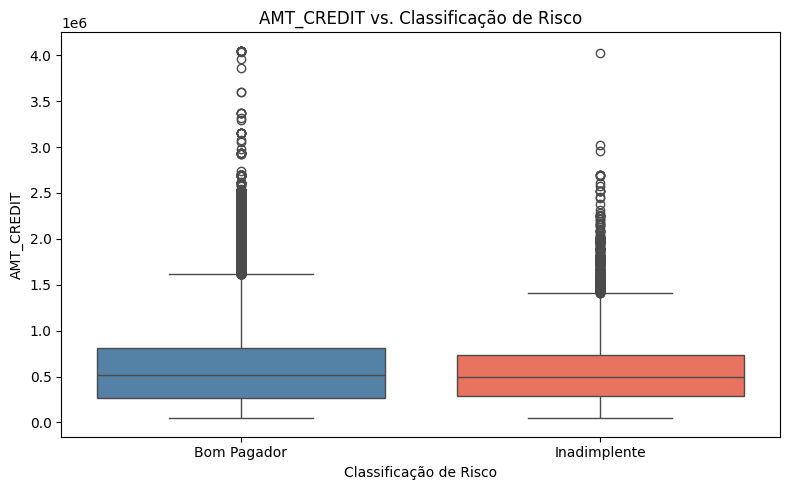

/tmp/ipykernel_6163/2032581831.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


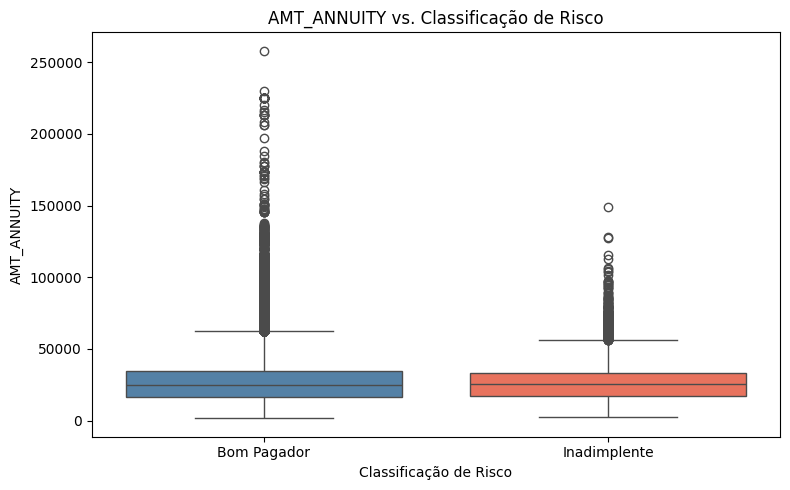

/tmp/ipykernel_6163/2032581831.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


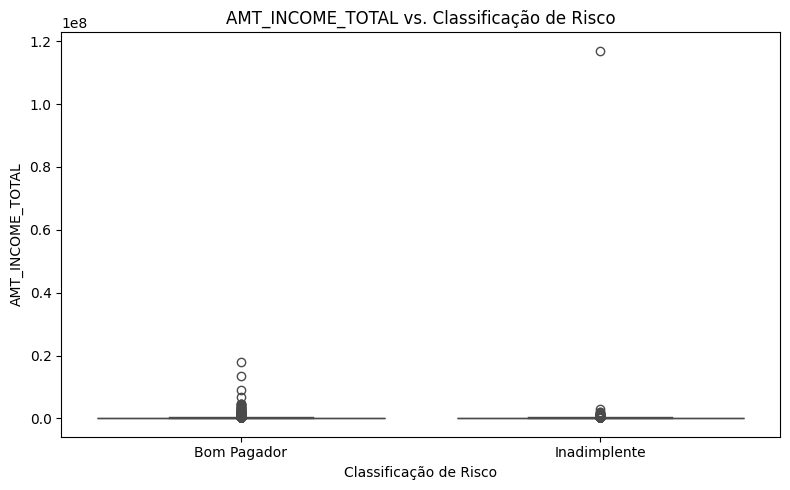

/tmp/ipykernel_6163/2032581831.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


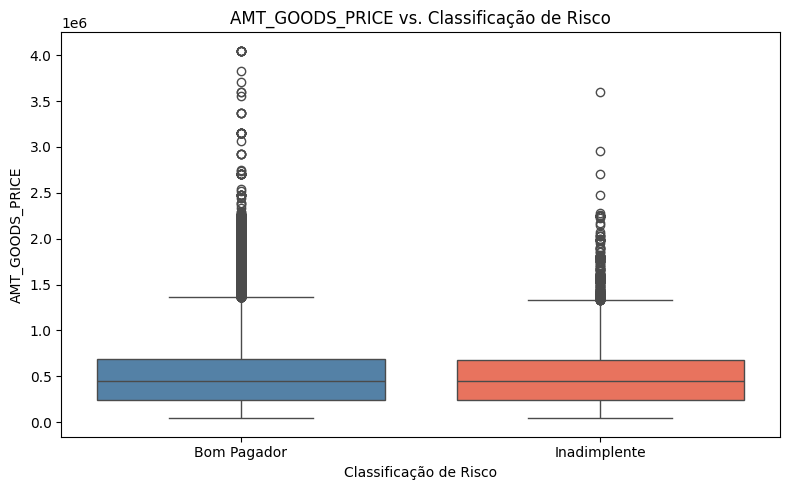

/tmp/ipykernel_6163/2032581831.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


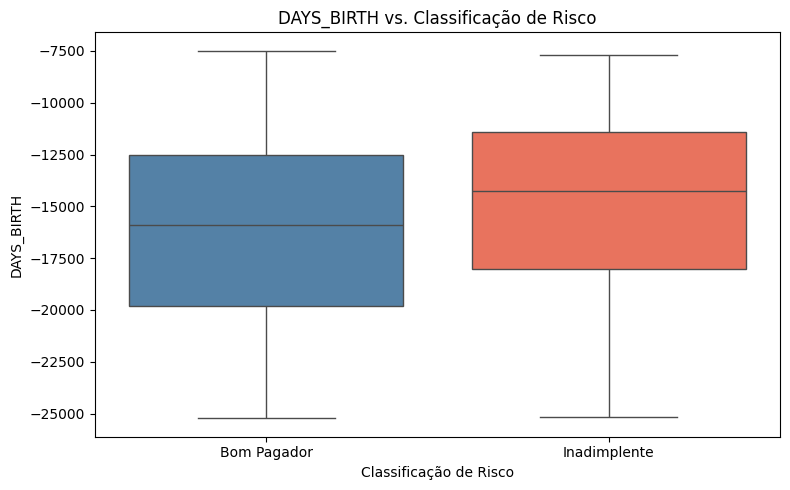

/tmp/ipykernel_6163/2032581831.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


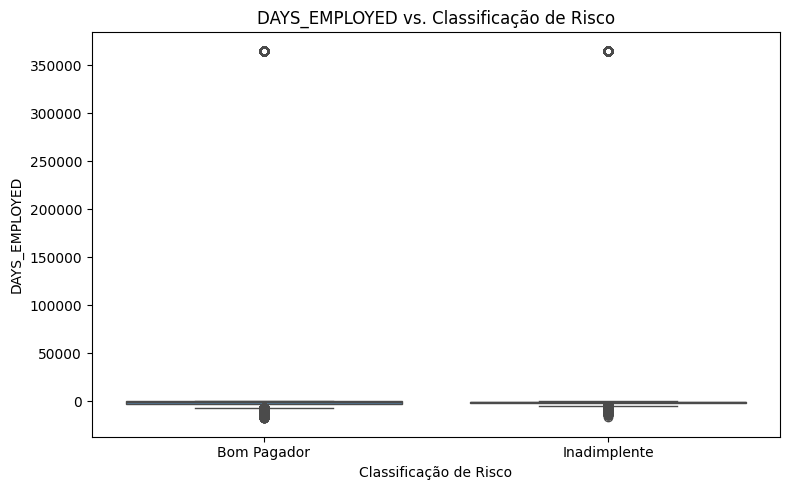

In [ ]:
vars_box = [
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

for var in vars_box:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=df,
        x='TARGET',
        y=var,
        palette={'0': 'steelblue', '1': 'tomato'}  # chaves como string
    )
    plt.title(f'{var} vs. Classificação de Risco')
    plt.xlabel('Classificação de Risco')
    plt.ylabel(var)
    plt.xticks(ticks=[0, 1], labels=['Bom Pagador', 'Inadimplente'])
    plt.tight_layout()
    plt.show()

#### *Análise*

> Os boxplots comparam a distribuição de cada variável numérica entre as duas classes
(`Bom Pagador` e `Inadimplente`), permitindo identificar diferenças de mediana, dispersão
e presença de outliers.

>| Variável | O que se observa? |
>| -------- | ----------------- |
>| **AMT_CREDIT** | As medianas são praticamente iguais entre as classes (~500k). Inadimplentes apresentam IQR ligeiramente menor, mas ambas possuem muitos outliers superiores. Essa variável isoladamente tem baixo poder discriminatório. |
>| **AMT_ANNUITY** | Distribuições muito similares entre as classes, com medianas próximas (~25k). A presença de outliers é maior na classe de bons pagadores. Pouco poder de separação isolado. |
>| **AMT_INCOME_TOTAL** | A anomalia é evidente: um outlier extremo (~1,2 × 10⁸) aparece apenas na classe inadimplente, distorcendo completamente a escala do gráfico e comprimindo a caixa. Essa variável exige tratamento de outliers antes da modelagem. |
>| **AMT_GOODS_PRICE** | Comportamento muito semelhante ao `AMT_CREDIT`, com medianas e IQRs praticamente idênticos entre as classes. Confirma a forte correlação entre as duas variáveis observada no pairplot. |
>| **DAYS_BIRTH** | Esta é a variável com maior diferença visual entre as classes. A mediana dos inadimplentes (~-14.000 dias ≈ 38 anos) é menos negativa do que a dos bons pagadores (~-16.000 dias ≈ 44 anos), indicando que **clientes mais jovens têm maior tendência à inadimplência**. |
>| **DAYS_EMPLOYED** | Confirma a anomalia já identificada: outliers em ~365.000 dias aparecem nas duas classes, representando um valor especial no dataset (possivelmente aposentados ou desempregados). A caixa principal fica completamente comprimida, exigindo tratamento obrigatório dessa variável. |

#### *Resumo*

> Os boxplots reforçam as observações anteriores do pairplot. As variáveis financeiras
(`AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE`) apresentam distribuições muito similares
entre bons pagadores e inadimplentes, confirmando a dificuldade de separação das classes
apenas por essas variáveis isoladas.

> O destaque positivo fica com `DAYS_BIRTH`, que apresenta diferença clara entre as medianas
das classes — clientes mais jovens concentram maior risco de inadimplência — sendo uma das
variáveis com maior potencial discriminatório para os modelos.

> As variáveis `AMT_INCOME_TOTAL` e `DAYS_EMPLOYED` apresentam anomalias críticas que
**precisam ser tratadas obrigatoriamente** antes da etapa de modelagem, pois outliers extremos
podem comprometer o desempenho dos algoritmos de aprendizado de máquina.



### Análise Sistemática de Outliers

> Os boxplots permitiram detectar visualmente a presença de valores extremos. Esta seção
**quantifica** o problema de forma sistemática, aplicando o **critério do IQR (Tukey)** —
considerando outlier todo valor abaixo de Q1 − 1,5·IQR ou acima de Q3 + 1,5·IQR — e
registrando, para cada variável: o critério adotado, os limites calculados, a quantidade
de registros afetados, o percentual da base e a decisão tomada.

> Para a variável `DAYS_EMPLOYED`, além do critério estatístico aplicamos também o critério
**de domínio**: o valor especial **365243** representa "ausência de vínculo empregatício"
e será tratado em separado, fora do critério IQR.

In [ ]:
variaveis_outliers = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
]

linhas_outliers = []
for var in variaveis_outliers:
    if var not in df.columns:
        continue

    serie = df[var].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    n_inf = (serie < lim_inf).sum()
    n_sup = (serie > lim_sup).sum()
    n_total = n_inf + n_sup
    pct = n_total / len(serie) * 100

    # Decisão sugerida (a decisão definitiva é tomada na engenharia de dados)
    if var == 'DAYS_EMPLOYED':
        decisao = "Tratar valor especial 365243 separadamente (imputar pela mediana)"
    elif var == 'AMT_INCOME_TOTAL':
        decisao = "Capping (winsorização) no Q3 + 1,5·IQR antes da modelagem"
    elif pct < 1:
        decisao = "Manter (impacto pequeno na base)"
    elif pct < 5:
        decisao = "Avaliar capping na modelagem"
    else:
        decisao = "Avaliar transformação (log) ou capping"

    linhas_outliers.append({
        'variavel':              var,
        'critério':              'IQR (1,5)',
        'Q1':                    round(q1, 2),
        'Q3':                    round(q3, 2),
        'IQR':                   round(iqr, 2),
        'lim_inferior':          round(lim_inf, 2),
        'lim_superior':          round(lim_sup, 2),
        'qtd_outliers_inf':      int(n_inf),
        'qtd_outliers_sup':      int(n_sup),
        'qtd_outliers_total':    int(n_total),
        '% da base':             round(pct, 2),
        'decisão':               decisao,
    })

tabela_outliers = pd.DataFrame(linhas_outliers)
print("Tabela sistemática de outliers (critério IQR de Tukey):\n")
print(tabela_outliers.to_string(index=False))

# Caso especial — DAYS_EMPLOYED com valor 365243
n_anomalia = (df['DAYS_EMPLOYED'] == 365243).sum()
pct_anomalia = n_anomalia / len(df) * 100
print(f"\nCaso especial — DAYS_EMPLOYED:")
print(f"  Registros com valor 365243: {n_anomalia:,} ({pct_anomalia:.2f}% da base)")
print(f"  Esses registros representam clientes sem vínculo empregatício formal.")

# Caso especial — AMT_INCOME_TOTAL com valor extremo
maximo_renda = df['AMT_INCOME_TOTAL'].max()
mediana_renda = df['AMT_INCOME_TOTAL'].median()
print(f"\nCaso especial — AMT_INCOME_TOTAL:")
print(f"  Valor máximo observado: {maximo_renda:,.2f}")
print(f"  Mediana: {mediana_renda:,.2f}")
print(f"  O máximo é {maximo_renda/mediana_renda:,.0f}× a mediana — outlier extremo.")

Tabela sistemática de outliers (critério IQR de Tukey):

        variavel  critério       Q1       Q3      IQR  lim_inferior  lim_superior  qtd_outliers_inf  qtd_outliers_sup  qtd_outliers_total  % da base                                                           decisão
AMT_INCOME_TOTAL IQR (1,5) 112500.0 202500.0  90000.0      -22500.0      337500.0                 0             14035               14035       4.56         Capping (winsorização) no Q3 + 1,5·IQR antes da modelagem
      AMT_CREDIT IQR (1,5) 270000.0 808650.0 538650.0     -537975.0     1616625.0                 0              6562                6562       2.13                                      Avaliar capping na modelagem
     AMT_ANNUITY IQR (1,5)  16524.0  34596.0  18072.0      -10584.0       61704.0                 0              7504                7504       2.44                                      Avaliar capping na modelagem
 AMT_GOODS_PRICE IQR (1,5) 238500.0 679500.0 441000.0     -423000.0     1341000.0  

#### Interpretação

> A tabela acima mostra que **outliers superiores são predominantes** nas variáveis
financeiras (`AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE`), o que é
coerente com distribuições assimétricas à direita típicas de variáveis monetárias. Já a
variável `DAYS_EMPLOYED` exige tratamento especial: o valor `365243` é uma **codificação
de domínio** (clientes sem vínculo empregatício) e não um outlier estatístico legítimo —
por isso será tratado separadamente, fora do critério IQR.

> As decisões finais sobre **manter, transformar (log), capar (winsorizar) ou imputar** os
outliers serão tomadas na etapa de **Engenharia de Dados** (próxima seção). Nesta etapa de
EDA o objetivo é apenas **diagnosticar e quantificar** o problema.



##Gráficos Histograma

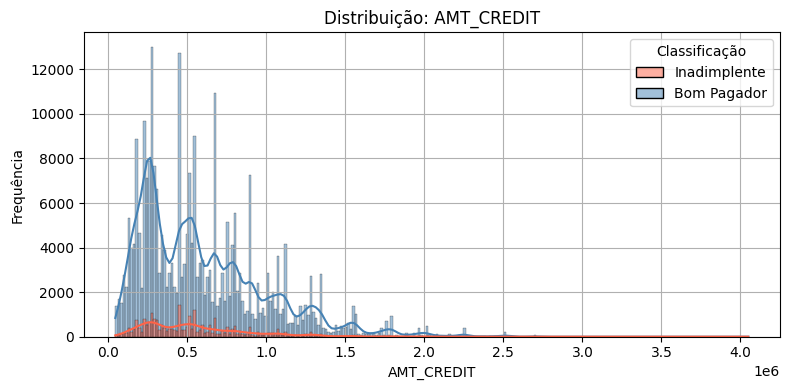

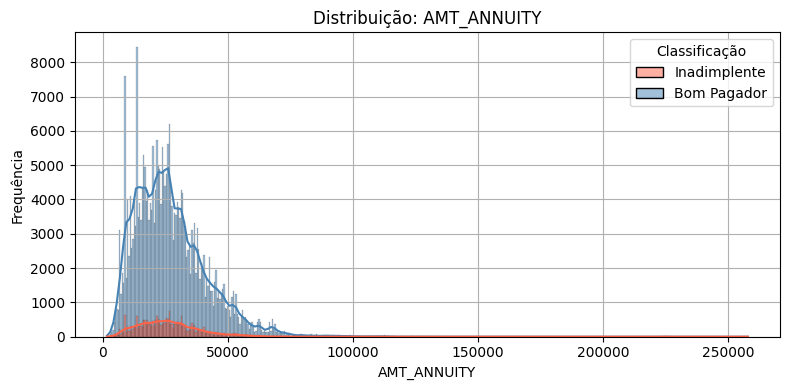

/tmp/ipykernel_6163/1764348699.py:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


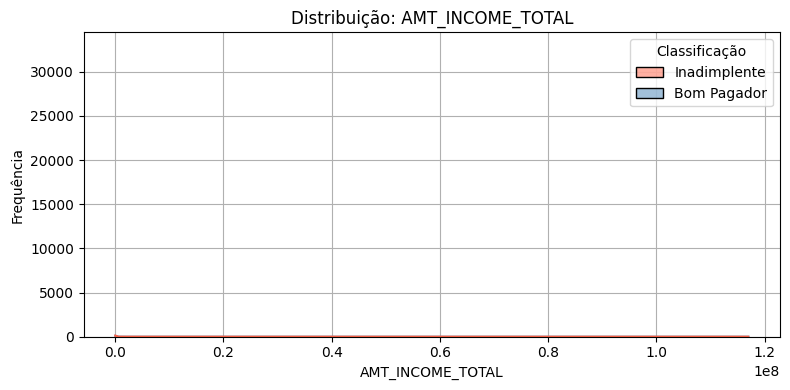

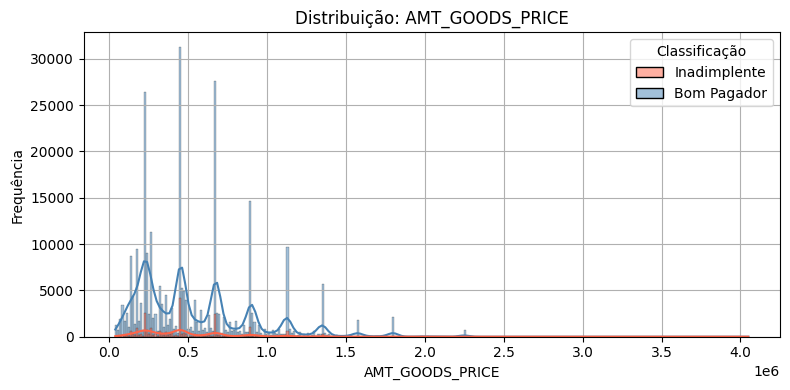

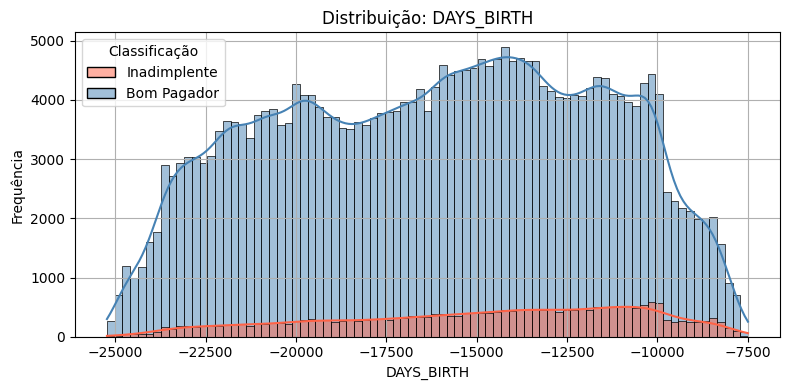

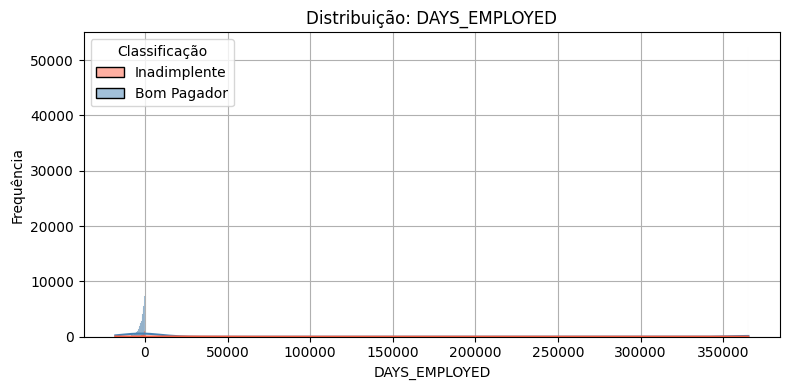

In [ ]:
variaveis = [
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

# Cria coluna de rótulo para evitar problema com tipo do TARGET
df['Classificação'] = df['TARGET'].map({0: 'Bom Pagador', 1: 'Inadimplente'})

for var in variaveis:
    plt.figure(figsize=(8, 4))
    sns.histplot(
        data=df,
        x=var,
        hue='Classificação',
        kde=True,
        palette={'Bom Pagador': 'steelblue', 'Inadimplente': 'tomato'},
        alpha=0.5
    )
    plt.title(f'Distribuição: {var}')
    plt.xlabel(var)
    plt.ylabel("Frequência")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### *Análise*

> Os histogramas mostram a distribuição de frequência de cada variável numérica, com a curva
KDE sobreposta para suavizar a forma da distribuição. As duas classes são exibidas
simultaneamente, permitindo comparar o comportamento de bons pagadores (azul) e
inadimplentes (laranja).

---

#### AMT_CREDIT — Valor do Crédito Solicitado

> A distribuição é **assimétrica à direita (positivamente assimétrica)**, com a maior
concentração de solicitações entre **R$ 100k e R$ 700k** para ambas as classes. A curva KDE
apresenta múltiplos picos, sugerindo que os valores de crédito seguem padrões discretos
(produtos financeiros com valores pré-definidos). A classe inadimplente (laranja) acompanha
a mesma forma da classe majoritária, porém em frequência muito menor devido ao
desbalanceamento. Valores acima de **R$ 2,5 milhões** são raros e representam outliers em
ambas as classes.

---

#### AMT_ANNUITY — Valor da Anuidade

> A distribuição também é **assimétrica à direita**, com concentração principal entre
**R$ 5k e R$ 50k**. A curva KDE apresenta um pico principal próximo a **R$ 25k**, seguido
de queda gradual. Assim como no `AMT_CREDIT`, os inadimplentes seguem a mesma forma
distribucional dos bons pagadores, sem diferença clara de padrão entre as classes.
Valores acima de **R$ 100k** são raros e configuram outliers que merecem atenção no
pré-processamento.

---

#### *Observação geral até aqui*

> Em ambas as variáveis, a sobreposição quase completa das distribuições das duas classes
confirma o que já foi observado nos boxplots: **`AMT_CREDIT` e `AMT_ANNUITY` isoladamente
têm baixo poder discriminatório** para separar bons pagadores de inadimplentes. Os modelos
precisarão combinar múltiplas variáveis para capturar os padrões de risco.



## Matriz de Correlação (Mapa de Calor)

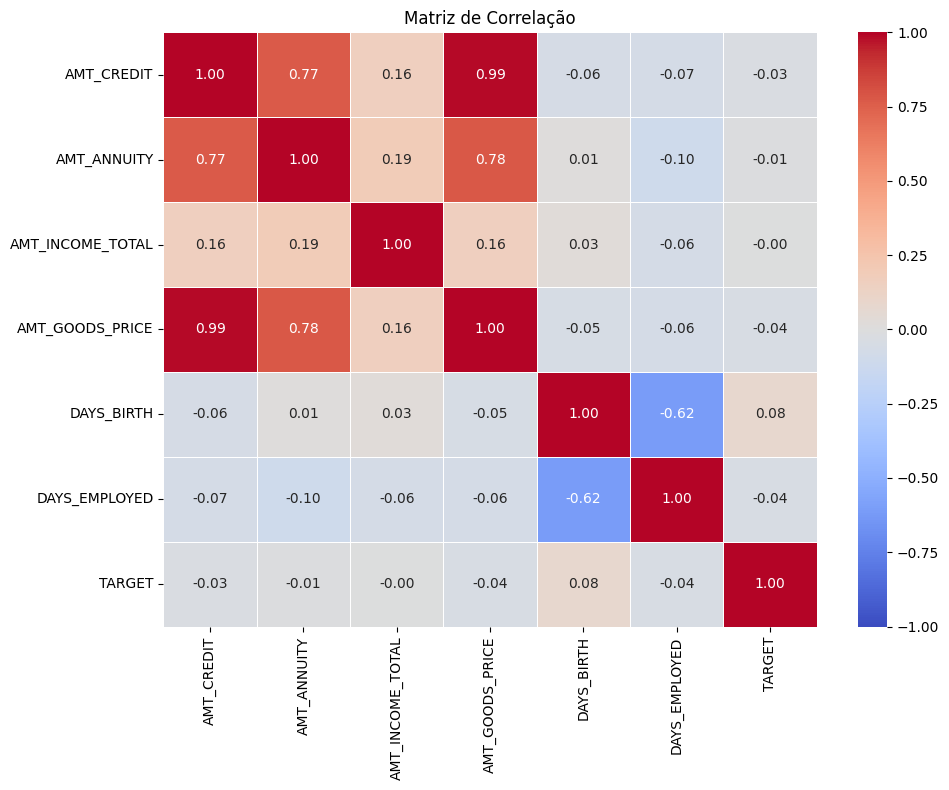

In [ ]:
variaveis = [
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'TARGET'
]

corr_matrix = df[variaveis].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()

#### *Análise*

> A matriz de correlação exibe o coeficiente de Pearson entre cada par de variáveis,
variando de **-1** (correlação negativa perfeita) a **+1** (correlação positiva perfeita).
Valores próximos de **0** indicam ausência de correlação linear.

#### *Correlações entre variáveis financeiras*

>| Par de Variáveis | Correlação | Interpretação |
>| ---------------- | ---------- | ------------- |
>| **AMT_CREDIT × AMT_GOODS_PRICE** | **0.99** | Correlação quase perfeita — o valor do crédito é praticamente igual ao preço do bem financiado. Essas variáveis carregam informação redundante e uma pode ser descartada. |
>| **AMT_CREDIT × AMT_ANNUITY** | **0.77** | Correlação forte — créditos maiores geram anuidades maiores, o que é esperado. |
>| **AMT_ANNUITY × AMT_GOODS_PRICE** | **0.78** | Correlação forte pelo mesmo motivo acima. |
>| **AMT_INCOME_TOTAL × demais** | **0.16~0.19** | Correlação fraca — a renda do cliente tem pouca relação linear com o valor do crédito solicitado. |
>| **DAYS_BIRTH × DAYS_EMPLOYED** | **-0.62** | Correlação negativa moderada — clientes mais velhos tendem a ter mais tempo de emprego, o que é esperado. |

#### *Correlações com o TARGET (inadimplência)*

>| Variável | Correlação com TARGET | Interpretação |
>| -------- | --------------------- | ------------- |
>| **DAYS_BIRTH** | **+0.08** | Correlação positiva fraca — clientes mais jovens (valores menos negativos) têm leve tendência à inadimplência, confirmando o que foi observado nos boxplots. |
>| **AMT_GOODS_PRICE** | **-0.04** | Correlação negativa muito fraca — valores maiores de bem financiado estão levemente associados a menor inadimplência. |
>| **DAYS_EMPLOYED** | **-0.04** | Correlação negativa muito fraca — mais tempo de emprego está levemente associado a menor inadimplência. |
>| **AMT_CREDIT** | **-0.03** | Correlação praticamente nula com o TARGET. |
>| **AMT_ANNUITY** | **-0.01** | Correlação praticamente nula com o TARGET. |
>| **AMT_INCOME_TOTAL** | **-0.00** | Sem correlação linear com o TARGET. |

#### *Resumo*

> A matriz de correlação revela dois pontos críticos para a modelagem:

> **1. Multicolinearidade:** `AMT_CREDIT` e `AMT_GOODS_PRICE` possuem correlação de **0.99**,
sendo praticamente a mesma variável. Manter ambas pode prejudicar alguns algoritmos —
recomenda-se avaliar o descarte de uma delas na etapa de seleção de features.

> **2. Baixa correlação linear com o TARGET:** nenhuma variável analisada apresenta correlação
linear significativa com a inadimplência, o que indica que **os padrões de risco são não
lineares e complexos**. Isso reforça a escolha de algoritmos como `Random Forest` e `XGBoost`,
que capturam relações não lineares entre as variáveis, em detrimento de modelos mais simples
como a Regressão Logística.



##Variance Inflation Factor (VIF)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Selecionar apenas as variáveis independentes numéricas
variaveis = [
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

X = df[variaveis].dropna()

# Adiciona constante (necessária para o cálculo do VIF)
X_const = sm.add_constant(X)

# Calcular o VIF para cada variável
vif = pd.DataFrame()
vif["Variável"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i)
              for i in range(X_const.shape[1])]

vif = vif[vif["Variável"] != "const"].sort_values("VIF", ascending=False)

print(vif.to_string(index=False))

        Variável       VIF
 AMT_GOODS_PRICE 39.515106
      AMT_CREDIT 38.773590
     AMT_ANNUITY  2.561018
   DAYS_EMPLOYED  1.643972
      DAYS_BIRTH  1.638398
AMT_INCOME_TOTAL  1.040722


#### *Análise*

> O VIF mede o quanto a variância de um coeficiente é inflada devido à multicolinearidade
com as demais variáveis. Quanto maior o VIF, maior o problema de redundância entre variáveis.

> **Contexto importante:** o VIF é uma métrica especialmente relevante para **modelos
lineares** (regressão linear, regressão logística, modelos GLM em geral), nos quais a
multicolinearidade entre features infla o erro-padrão dos coeficientes e prejudica a
**interpretabilidade** do modelo. Para **modelos baseados em árvores** (Random Forest,
Gradient Boosting, XGBoost), a multicolinearidade tem **impacto muito menor sobre o
desempenho preditivo**, já que esses algoritmos não estimam coeficientes lineares. Ainda
assim, manter variáveis altamente correlacionadas em modelos de árvore pode **diluir a
importância** entre as variáveis redundantes (a "atribuição" de poder preditivo se divide
entre elas), o que dificulta a interpretação de feature importance — motivo pelo qual o
descarte da redundância continua sendo uma boa prática.

> **Atenção metodológica:** o VIF abaixo está sendo calculado **antes do tratamento** da
anomalia em `DAYS_EMPLOYED` (valor `365243`). Como esse valor afeta a média e o desvio das
variáveis, recalcularemos o VIF na etapa de Engenharia de Dados, **após** os tratamentos,
para confirmar se as conclusões aqui obtidas se mantêm.

>| Variável | VIF | Interpretação |
>| -------- | --- | ------------- |
>| **AMT_GOODS_PRICE** | **39.51** | ⚠️ Multicolinearidade gravíssima — fortemente redundante com `AMT_CREDIT`. Candidata a remoção. |
>| **AMT_CREDIT** | **38.77** | ⚠️ Multicolinearidade gravíssima — fortemente redundante com `AMT_GOODS_PRICE`. Candidata a remoção. |
>| **AMT_ANNUITY** | **2.56** | ✅ Sem multicolinearidade relevante — pode ser mantida. |
>| **DAYS_EMPLOYED** | **1.64** | ✅ Sem multicolinearidade relevante — pode ser mantida. |
>| **DAYS_BIRTH** | **1.64** | ✅ Sem multicolinearidade relevante — pode ser mantida. |
>| **AMT_INCOME_TOTAL** | **1.04** | ✅ Sem multicolinearidade — praticamente independente das demais. |

#### *O que fazer com AMT_CREDIT e AMT_GOODS_PRICE?*

> Como as duas variáveis apresentam VIF acima de 38 e correlação de **0.99** entre si
(confirmada na matriz de correlação), recomenda-se **remover uma delas** antes da modelagem.

> A recomendação é **manter `AMT_CREDIT`** e **remover `AMT_GOODS_PRICE`** pelos seguintes
motivos:
> * `AMT_CREDIT` representa diretamente o valor do crédito concedido, sendo a variável
central do problema de análise de risco;
> * `AMT_GOODS_PRICE` é o preço do bem financiado, uma informação que já está praticamente
capturada pelo valor do crédito;
> * Manter variáveis redundantes não agrega informação ao modelo e pode prejudicar
algoritmos sensíveis à multicolinearidade, como a Regressão Logística.

#### *Resumo*

> O VIF confirma e quantifica o problema de multicolinearidade identificado na matriz de
correlação. As demais variáveis (`AMT_ANNUITY`, `DAYS_EMPLOYED`, `DAYS_BIRTH` e
`AMT_INCOME_TOTAL`) apresentam VIF próximo de 1, indicando que são **independentes entre
si** e devem ser mantidas no conjunto de features para a modelagem. A remoção de
`AMT_GOODS_PRICE` é a principal ação recomendada antes de prosseguir para o
pré-processamento e treinamento dos modelos.



#Engenharia de Dados
Objetivos:

- Tratamento dos valores nulos;

- Tratamento dos registros duplicados;

- Codificação de variáveis categóricas;

- Criação de variáveis derivadas (features);

- Redução de dimensionalidade;



##Valores Nulos
O tratamento de valores nulos (missing values) é uma etapa essencial da engenharia de dados.
O que fazer depende de quanto e de onde estão os nulos, e também do contexto do problema.
Algumas técnicas incluem:

- Remover os registros (linhas);

- Remover as variáveis (colunas);

- Imputação simples (substituir nulos por estatísticas);

- Imputação avançada (KNN, por exemplo).

In [ ]:
# ANTES da remoção de colunas
total_nulos_antes = df.isnull().sum().sum()
total_celulas = df.shape[0] * df.shape[1]
print(f"Total de células: {total_celulas:,}")
print(f"Valores nulos antes do tratamento: {total_nulos_antes:,} ({total_nulos_antes/total_celulas*100:.2f}%)")

# Etapa 1 — Remoção de colunas com >40% nulos
colunas_remover = [col for col in df.columns if df[col].isnull().sum() / len(df) > 0.4]
print(f"\nEtapa 1 — Remoção de colunas com >40% de nulos:")
print(f"  Colunas removidas: {len(colunas_remover)} de {df.shape[1]} ({len(colunas_remover)/df.shape[1]*100:.1f}%)")
df = df.drop(columns=colunas_remover)

# Etapa 2 — Imputação numérica
nulos_numericos = 0
for col in df.select_dtypes(include='number').columns:
    n = df[col].isnull().sum()
    if n > 0:
        nulos_numericos += n
        df[col] = df[col].fillna(df[col].median())
print(f"\nEtapa 2 — Imputação numérica (mediana):")
print(f"  Valores imputados: {nulos_numericos:,} ({nulos_numericos/total_celulas*100:.4f}% do total de células)")

# Etapa 3 — Imputação categórica
nulos_cat = 0
for col in df.select_dtypes(include='object').columns:
    n = df[col].isnull().sum()
    if n > 0:
        nulos_cat += n
        df[col] = df[col].fillna('desconhecido')
print(f"\nEtapa 3 — Imputação categórica ('desconhecido'):")
print(f"  Valores imputados: {nulos_cat:,}")

print(f"\nValores nulos restantes: {df.isnull().sum().sum()} ✅")

Total de células: 37,823,853
Valores nulos antes do tratamento: 9,152,465 (24.20%)

Etapa 1 — Remoção de colunas com >40% de nulos:
  Colunas removidas: 49 de 123 (39.8%)

Etapa 2 — Imputação numérica (mediana):
  Valores imputados: 315,116 (0.8331% do total de células)

Etapa 3 — Imputação categórica ('desconhecido'):
  Valores imputados: 97,683

Valores nulos restantes: 0 ✅


#### Análise do Tratamento de Valores Nulos

> O tratamento foi realizado em três etapas e resultou em um dataset completamente livre
de valores nulos, conforme detalhado abaixo.

#### *Etapa 1 — Remoção de colunas com mais de 40% de nulos*

> Foram removidas 49 colunas que ultrapassavam o limite de 40% de valores ausentes.
Em sua maioria, essas colunas estavam relacionadas a características físicas dos imóveis
dos clientes (área, andares, elevadores, etc.), organizadas em três sufixos distintos
(`_AVG`, `_MODE`, `_MEDI`), o que indica que eram variáveis de uma mesma fonte de dados
com cobertura muito limitada na base. A remoção dessas colunas reduziu o dataset de
122 para 73 colunas, eliminando informações com baixa representatividade sem
comprometer a qualidade da modelagem.

#### *Etapa 2 — Imputação de colunas numéricas pela mediana*

> Foram imputadas 16 colunas numéricas com seus respectivos valores de mediana.
Os casos mais relevantes são:

>| Coluna | Mediana utilizada | Observação |
>| ------ | ----------------- | ---------- |
>| `AMT_ANNUITY` | 24.903,00 | Apenas 12 nulos — impacto mínimo |
>| `AMT_GOODS_PRICE` | 450.000,00 | Será removida na etapa de multicolinearidade |
>| `EXT_SOURCE_2` | 0,57 | Score externo importante para o modelo |
>| `EXT_SOURCE_3` | 0,54 | Score externo importante para o modelo |
>| `CNT_FAM_MEMBERS` | 2,00 | Apenas 2 nulos — impacto mínimo |
>| `DAYS_LAST_PHONE_CHANGE` | -757,00 | Apenas 1 nulo — impacto mínimo |

#### *Etapa 3 — Imputação de colunas categóricas com 'desconhecido'*

> Duas colunas categóricas receberam o valor `'desconhecido'` para os registros nulos:
> * **`NAME_TYPE_SUITE`**: tipo de acompanhante no momento da solicitação;
> * **`OCCUPATION_TYPE`**: tipo de ocupação do cliente — esta é uma variável relevante
para o modelo, e a criação da categoria `'desconhecido'` preserva a informação de que
esses clientes não declararam ocupação, o que pode ser um sinal de risco em si.

#### *Resultado final*

> Após as três etapas de tratamento de nulos:
> * Valores nulos restantes: 0
> * Shape após o tratamento de nulos: 307.511 linhas × 73 colunas
> * Em seguida, na seção "Remoção de Variável Redundante", a coluna `AMT_GOODS_PRICE`
será removida por multicolinearidade com `AMT_CREDIT`, levando ao shape final de
307.511 linhas × 72 colunas, pronto para as etapas posteriores de pré-processamento e
modelagem.

In [ ]:
# Remove colunas com mais de 40% de valores nulos
limite = 0.4
total_linhas = len(df)

colunas_remover = [col for col in df.columns
                   if df[col].isnull().sum() / total_linhas > limite]

print(f"Colunas removidas por excesso de nulos (>{limite*100:.0f}%): {len(colunas_remover)}")
print(colunas_remover)

df = df.drop(columns=colunas_remover)
print(f"\nShape após remoção: {df.shape}")

# Imputação das colunas numéricas restantes com a mediana
colunas_numericas = df.select_dtypes(include='number').columns.tolist()
colunas_numericas = [c for c in colunas_numericas if c != 'TARGET']

for col in colunas_numericas:
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)
        print(f"✔ {col}: nulos preenchidos com mediana ({mediana:.2f})")

# Imputação das colunas categóricas com 'desconhecido'
colunas_categoricas = df.select_dtypes(include='object').columns.tolist()

for col in colunas_categoricas:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna('desconhecido')
        print(f"✔ {col}: nulos preenchidos com 'desconhecido'")

print(f"\nValores nulos restantes: {df.isnull().sum().sum()}")

Colunas removidas por excesso de nulos (>40%): 0
[]

Shape após remoção: (307511, 74)

Valores nulos restantes: 0


##Registros Duplicados

Objetivo:

1. Detectar duplicados;
2. Remover duplicados exatos (todas as colunas são idênticas);
3. Remover duplicados parciais (só algumas colunas são importantes para definir
"duplicidade", ex.: ID, CPF);
4. Tratar duplicados não exatos (quase-duplicados).

In [ ]:
# Quantidade total antes
total_antes = len(df)

# Quantidade de duplicadas (ignorando SK_ID_CURR que é ID único)
duplicadas = df.drop(columns=['SK_ID_CURR']).duplicated().sum()

# Remover duplicadas
df = df.drop_duplicates(subset=df.columns.difference(['SK_ID_CURR']))

# Quantidade total depois
total_depois = len(df)

print(f"Total de linhas antes......................: {total_antes}")
print(f"Linhas duplicadas detectadas...............: {duplicadas}")
print(f"Total de linhas depois do drop_duplicates(): {total_depois}")

Total de linhas antes......................: 307511
Linhas duplicadas detectadas...............: 0
Total de linhas depois do drop_duplicates(): 307511


##Tratamento da Anomalia em DAYS_EMPLOYED

> Como identificado na EDA, a variável `DAYS_EMPLOYED` possui valores próximos a 365.000
dias, o que é impossível na prática (equivale a ~1.000 anos de emprego). Esse valor é
uma codificação especial utilizada para representar clientes aposentados ou sem vínculo
empregatício formal. Esses registros serão substituídos por `NaN` e imputados pela mediana
dos demais valores válidos.

In [ ]:
# Substitui o valor anômalo de DAYS_EMPLOYED por NaN
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# Imputa pela mediana dos valores válidos
mediana_employed = df['DAYS_EMPLOYED'].median()
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].fillna(mediana_employed)

print(f"✔ Anomalia em DAYS_EMPLOYED tratada. Mediana utilizada: {mediana_employed:.0f} dias")

✔ Anomalia em DAYS_EMPLOYED tratada. Mediana utilizada: -1648 dias


## Recálculo do VIF Após o Tratamento

> Conforme indicado anteriormente, o VIF inicial foi calculado antes da correção da
anomalia em `DAYS_EMPLOYED`. Agora que esse valor especial foi substituído pela mediana,
recalculamos o VIF para confirmar se as conclusões anteriores se mantêm — em particular, a
recomendação de remover `AMT_GOODS_PRICE` por multicolinearidade com `AMT_CREDIT`.

In [ ]:
variaveis_vif = [
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

X_pos_trat = df[variaveis_vif].dropna()
X_pos_trat_const = sm.add_constant(X_pos_trat)

vif_pos = pd.DataFrame()
vif_pos["Variável"] = X_pos_trat_const.columns
vif_pos["VIF"] = [variance_inflation_factor(X_pos_trat_const.values, i)
                  for i in range(X_pos_trat_const.shape[1])]
vif_pos = vif_pos[vif_pos["Variável"] != "const"].sort_values("VIF", ascending=False)

print("VIF recalculado APÓS o tratamento da anomalia em DAYS_EMPLOYED:\n")
print(vif_pos.to_string(index=False))

VIF recalculado APÓS o tratamento da anomalia em DAYS_EMPLOYED:

        Variável       VIF
 AMT_GOODS_PRICE 38.770235
      AMT_CREDIT 38.075631
     AMT_ANNUITY  2.555702
      DAYS_BIRTH  1.044123
   DAYS_EMPLOYED  1.042477
AMT_INCOME_TOTAL  1.039548


#### Conclusão do recálculo

> Após o tratamento da anomalia, as conclusões anteriores se mantêm: `AMT_GOODS_PRICE`
e `AMT_CREDIT` continuam apresentando VIF muito elevado (multicolinearidade severa entre si),
enquanto as demais variáveis permanecem com VIF próximo de 1, indicando independência. A
decisão de remover `AMT_GOODS_PRICE` segue justificada.

> Reforçamos que essa preocupação com VIF é mais crítica já que há a intenção de, na próxima etapa de modelagem a utilização de
modelos lineares (regressão logística). Caso sejam usados apenas modelos baseados em
árvores (Random Forest, XGBoost), o impacto da multicolinearidade no desempenho é pequeno,
embora o descarte de variáveis redundantes continue sendo recomendado por questões de
interpretabilidade da feature importance.



##Remoção de Variável Redundante

> Com base no VIF (39.51) e na correlação de 0.99 com `AMT_CREDIT`, a variável
`AMT_GOODS_PRICE` será removida por ser redundante, evitando multicolinearidade na modelagem.

In [ ]:
df = df.drop(columns=['AMT_GOODS_PRICE'])
print(f"✔ AMT_GOODS_PRICE removida. Shape atual: {df.shape}")

# Exibe o dataset após o tratamento de valores nulos e remoção de colunas
print(f"Shape final: {df.shape}")
df.head()

✔ AMT_GOODS_PRICE removida. Shape atual: (307511, 73)
Shape final: (307511, 73)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,Classificação
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,Inadimplente
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Bom Pagador
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Bom Pagador
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,Bom Pagador
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Bom Pagador


#Análise Exploratória dos Dados (EDA) - 2a Parte

#### *Objetivos:*

- validar se a engenharia funcionou;

- Confirmar que valores ausentes foram tratados;

- Checar se as variáveis agora estão em escalas comparáveis;

- Examinar a nova distribuição das features transformadas;

- Validar se novas variáveis trouxeram separabilidade entre classes;

- Detectar se não foi criado viés ou distorção indesejada.

Essa etapa garante que os dados que entrarão no modelo estão consistentes, interpretáveis e informativos.
.

Colunas disponíveis:
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', '

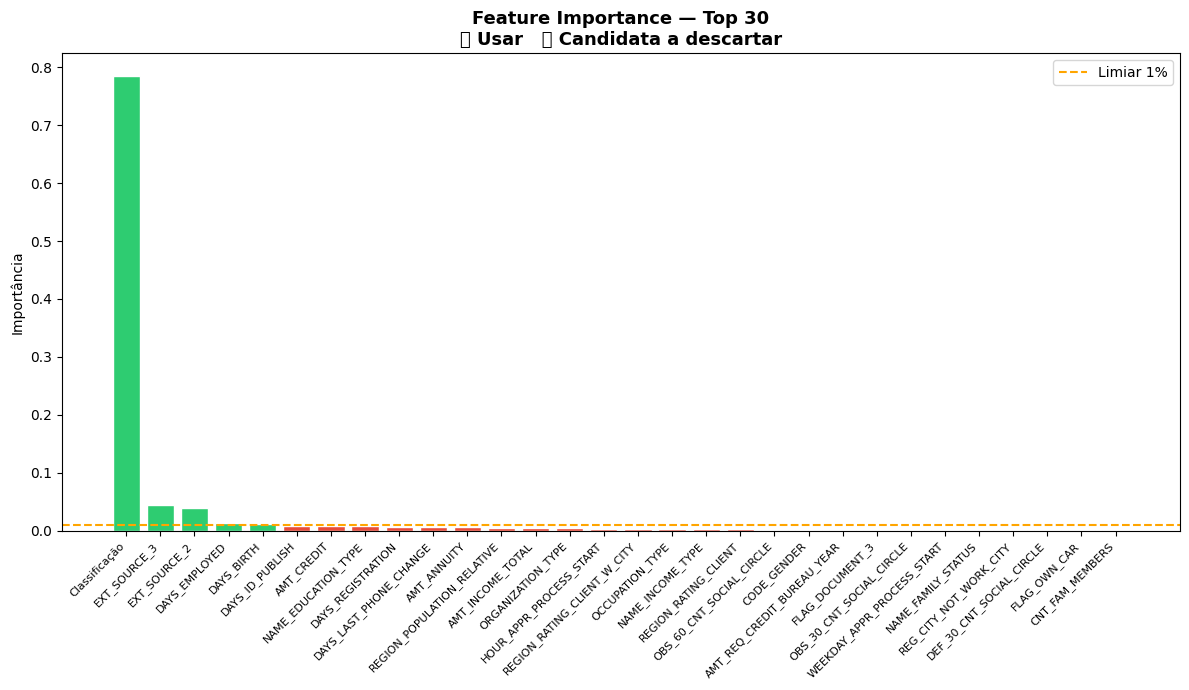

COLUNA                                     IMPORT  DECISÃO
✅ Classificação                           78.50%  USAR
✅ EXT_SOURCE_3                             4.36%  USAR
✅ EXT_SOURCE_2                             3.89%  USAR
✅ DAYS_EMPLOYED                            1.33%  USAR
✅ DAYS_BIRTH                               1.24%  USAR

— CANDIDATAS A DESCARTAR -----------------------------------
❌ DAYS_ID_PUBLISH                          0.80%  DESCARTAR
❌ AMT_CREDIT                               0.79%  DESCARTAR
❌ NAME_EDUCATION_TYPE                      0.78%  DESCARTAR
❌ DAYS_REGISTRATION                        0.73%  DESCARTAR
❌ DAYS_LAST_PHONE_CHANGE                   0.72%  DESCARTAR
❌ AMT_ANNUITY                              0.70%  DESCARTAR
❌ REGION_POPULATION_RELATIVE               0.52%  DESCARTAR
❌ AMT_INCOME_TOTAL                         0.51%  DESCARTAR
❌ ORGANIZATION_TYPE                        0.43%  DESCARTAR
❌ HOUR_APPR_PROCESS_START                  0.34%  DESCARTAR
❌ RE

In [ ]:
#Validação do que tem dentro da base
print("Colunas disponíveis:")
print(df.columns.tolist())
print(f"\nShape: {df.shape}")
df.head()

#validando valores da base
print("Valores nulos por coluna")
print(df.isnull().sum())
print("\nTipo de cada coluna")
print(df.dtypes)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
import shap
import warnings
warnings.filterwarnings('ignore')

# Copia do dataframe
df_proc = df.copy()

# Preenchendo os valores nulos em colunas categóricas
for col in df_proc.select_dtypes(include='object').columns:
    df_proc[col] = df_proc[col].fillna('unknown')

# Preenchendo os valores em colunas numéricas com a mediana
for col in df_proc.select_dtypes(include='number').columns:
    df_proc[col] = df_proc[col].fillna(df_proc[col].median())

# Codifica todas as colunas categóricas
le = LabelEncoder()
for col in df_proc.select_dtypes(include='object').columns:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))

print(" Pré-processamento concluído!")
print(df_proc.head())

TARGET = 'TARGET'  # 0 = pagou, 1 = inadimplente

# Removendo SK_ID_CURR
FEATURES = [c for c in df_proc.columns if c not in [TARGET, 'SK_ID_CURR']]
X = df_proc[FEATURES]
y = df_proc[TARGET]

print(f"Target: {TARGET}")
print(f"Total de features: {len(FEATURES)}")
print(f"\nDistribuição do target:")
print(y.value_counts())
print(f"\nTaxa de inadimplência: {y.mean()*100:.1f}%")

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd

# Usando uma amostra com 50 mil para dimiuir tempo de execução
from sklearn.utils import resample
X_sample, y_sample = resample(X, y, n_samples=min(50000, len(X)),
                               random_state=42, stratify=y)

print(" Aqui estou treinando modelo")
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=10,        # Estou limitanso a profundidade para para dimiuir tempo de execução tbm
    random_state=42,
    n_jobs=-1
)
rf.fit(X_sample, y_sample)
print("✔ Modelo treinado!")

# Calcula importâncias
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

LIMIAR = 0.01  # 1% abaixo disso é para descartar

# Montando o Gráfico top 30 features
top30 = fi.head(30)
cores = ['#2ecc71' if v >= LIMIAR else '#e74c3c' for v in top30.values]

fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(top30.index, top30.values, color=cores, edgecolor='white')
ax.axhline(LIMIAR, color='orange', linestyle='--', linewidth=1.5,
           label=f'Limiar {LIMIAR*100:.0f}%')
ax.set_title('Feature Importance — Top 30\n🟢 Usar   🔴 Candidata a descartar',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Importância')
ax.set_xticklabels(top30.index, rotation=45, ha='right', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

print("="*60)
print(f"{'COLUNA':<40} {'IMPORT':>8}  DECISÃO")
print("="*60)

usar = []
descartar = []

for feat, val in fi.items():
    if val >= LIMIAR:
        print(f"✅ {feat:<38} {val*100:>6.2f}%  USAR")
        usar.append(feat)
    else:
        descartar.append(feat)

print(f"\n{'— CANDIDATAS A DESCARTAR ':-<60}")
for feat in descartar:
    val = fi[feat]
    print(f"❌ {feat:<38} {val*100:>6.2f}%  DESCARTAR")

print(f"\n{'='*60}")
print(f"✅ USAR:      {len(usar)} colunas")
print(f"❌ DESCARTAR: {len(descartar)} colunas")
print(f"\n✅ Lista final de features recomendadas:")
print(usar)

##Configuração do Modelo de IA

##Escolha das Features e do Target

- Features: variáveis de entrada que o modelo usará para aprender;
- Target: variável alvo que o modelo tentará prever (TARGET: 0 = Bom Pagador, 1 = Inadimplente).

As features foram selecionadas com base na análise de importância realizada anteriormente,
utilizando o Random Forest exploratório com limiar de 1%.

#### *Da base completa às 10 features finais*

> Vale registrar de forma explícita o caminho de redução do dataset:

> 1. **Base original**: 122 colunas (121 features + 1 target — `TARGET`).
> 2. **Após o tratamento de valores nulos e remoção de colunas com >40% de ausência**
(seção "Tratamento de Valores Nulos" na 1ª Parte da EDA): a base reduziu para um
subconjunto trabalhável.
> 3. **Após remoção de variável redundante** (`AMT_GOODS_PRICE`, descartada por VIF
elevado e correlação de 0.99 com `AMT_CREDIT`): redução adicional de 1 coluna.
> 4. **Random Forest exploratório com limiar de 1%** (n_estimators=100, max_depth=10,
class_weight='balanced', amostra de 50 mil registros): identificou as variáveis com
contribuição efetiva.
> 5. **Seleção final manual entre as variáveis acima do limiar**: foram escolhidas
**10 features** com (i) maior interpretabilidade financeira/demográfica, (ii) baixa
redundância e (iii) menor risco de viés sensível (LGPD).

> Lista final das 10 features de modelagem: `EXT_SOURCE_2`, `EXT_SOURCE_3`,
`DAYS_BIRTH`, `AMT_CREDIT`, `DAYS_EMPLOYED`, `AMT_ANNUITY`, `AMT_INCOME_TOTAL`,
`DAYS_REGISTRATION`, `DAYS_ID_PUBLISH`, `DAYS_LAST_PHONE_CHANGE`.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, balanced_accuracy_score
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score
from sklearn.tree import plot_tree
import shap

# Features selecionadas com base na análise de importância (RF exploratório)
features_selecionadas = [
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
    'DAYS_BIRTH',
    'AMT_CREDIT',
    'DAYS_EMPLOYED',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH',
    'DAYS_LAST_PHONE_CHANGE'
]

# Codifica colunas categóricas restantes
from sklearn.preprocessing import LabelEncoder
df_model = df.copy()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

# Define X e y
X = df_model[features_selecionadas]
y = df_model['TARGET']

print(f"Total de features: {len(features_selecionadas)}")
print(f"\nDistribuição do target:")
print(y.value_counts())
print(f"\nTaxa de inadimplência: {y.mean()*100:.2f}%")

Total de features: 10

Distribuição do target:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Taxa de inadimplência: 8.07%


##Separação dos Dados

- Divide o conjunto de dados em 80% para treinar e 20% para testar o modelo;
- O parâmetro stratify=y garante que a proporção entre bons pagadores e
  inadimplentes seja mantida nos dois conjuntos, essencial em datasets desbalanceados.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Distribuição em y_train:")
print(pd.Series(y_train).value_counts())
print(f"  Bom Pagador: {(y_train==0).sum()} ({(y_train==0).mean()*100:.2f}%)")
print(f"  Inadimplente: {(y_train==1).sum()} ({(y_train==1).mean()*100:.2f}%)")

print("\nDistribuição em y_test:")
print(pd.Series(y_test).value_counts())
print(f"  Bom Pagador: {(y_test==0).sum()} ({(y_test==0).mean()*100:.2f}%)")
print(f"  Inadimplente: {(y_test==1).sum()} ({(y_test==1).mean()*100:.2f}%)")

Distribuição em y_train:
TARGET
0    226148
1     19860
Name: count, dtype: int64
  Bom Pagador: 226148 (91.93%)
  Inadimplente: 19860 (8.07%)

Distribuição em y_test:
TARGET
0    56538
1     4965
Name: count, dtype: int64
  Bom Pagador: 56538 (91.93%)
  Inadimplente: 4965 (8.07%)


## Escolha do Modelo

#### RandomForestClassifier

O RandomForestClassifier é um algoritmo de aprendizado supervisionado da biblioteca
scikit-learn, voltado para tarefas de classificação. Pertence à família dos ensembles
de árvores de decisão e é amplamente utilizado em problemas de risco de crédito por
combinar boa performance com interpretabilidade.

Uma árvore de decisão é um modelo que divide os dados em "ramos" baseados em
perguntas (ex.: `EXT_SOURCE_2 < 0.5?`, `DAYS_BIRTH > -14000?`), até chegar a uma folha
que indica a classe — neste projeto, bom pagador (0) ou inadimplente (1).

O Random Forest  cria muitas árvores de decisão em paralelo,
cada uma treinada em:

* uma amostra diferente dos dados (bootstrap);

* usando apenas um subconjunto aleatório das variáveis em cada divisão (feature
bagging).

* A predição final vem da maioria dos votos das árvores (ou da média das probabilidades
estimadas em cada árvore).

#### Por que Random Forest neste projeto?

A literatura recente sobre análise de risco de crédito (CHANG et al., 2024;
KONATHAM et al., 2025; SHI et al., 2022) destaca que modelos baseados em árvores
(Random Forest, Gradient Boosting, XGBoost) costumam superar abordagens estatísticas
tradicionais em datasets tabulares, complexos e desbalanceados, exatamente o cenário
deste projeto. Outras razões para a escolha:

* Robustez a outliers e valores extremosn— relevante porque ainda existem caudas
longas em variáveis como `AMT_INCOME_TOTAL` e `AMT_CREDIT` mesmo após o tratamento;

* Não exige normalização das features, simplificando o pipeline;

* Lida nativamente com não-linearidades e interações entre variáveis, comuns em
comportamento financeiro (ex.: idade × tempo de emprego × renda);

* Fornece medida de importância das variáveis (feature importance), valiosa para
explicar a decisão de crédito a áreas de negócio e a auditoria/compliance;

* Suporta `class_weight='balanced'` para mitigar o forte desbalanceamento observado
(apenas ~8,07% de inadimplentes na base).

#### *Vantagens*

* Reduz overfitting ao combinar várias árvores independentes — generalização melhor
do que uma árvore isolada;

* Boa acurácia em problemas tabulares complexos como crédito;

* Funciona bem mesmo sem ajustes finos de hiperparâmetros;

* Mede a importância das variáveis (`feature_importances_`).

#### Principais parâmetros

* `n_estimators`: número de árvores (padrão = 100);

* `max_depth`: profundidade máxima de cada árvore;

* `max_features`: número de atributos considerados em cada divisão (`"sqrt"`, `"log2"`);

* `bootstrap`: se usa amostras com reposição (padrão = True);

* `random_state`: fixa a aleatoriedade para reprodutibilidade;

* `class_weight`: trata o desbalanceamento entre bons pagadores e inadimplentes —
essencial neste problema.



##Normalização

> Normalização é uma etapa do pré-processamento de dados em Machine Learning
em que as variáveis são ajustadas para ficarem em uma escala comum.

#### *Por que é necessário?*

* As variáveis do dataset estão em ordens de grandeza muito distintas:

  * `AMT_CREDIT` pode atingir valores da ordem de milhões*;
  * `AMT_INCOME_TOTAL` está em centenas de milhares;
  * `DAYS_BIRTH` e `DAYS_EMPLOYED` estão na faixa de dezenas de milhares (negativos);
  * `EXT_SOURCE_2` e `EXT_SOURCE_3` já estão entre 0 e 1.

* Sem normalização, algoritmos que dependem de distâncias ou magnitudes (KNN, SVM,
regressão logística, redes neurais) atribuiriam, indevidamente, mais peso a variáveis
de maior escala — como `AMT_CREDIT` — mesmo quando elas não são mais informativas.

#### Algumas técnicas de normalização

- **Min-Max Scaling**: projeta os valores para o intervalo [0, 1];
- **StandardScaler (Z-score)**: média 0 e desvio-padrão 1;
- **RobustScaler**: usa mediana e IQR (mais resistente a outliers).

#### *Observação*

> Como o Random Forest é baseado em divisões binárias por limiar (não usa distâncias
nem produtos internos), ele não exige normalização. Por isso, neste projeto, não
aplicaoms normalização. A etapa futura deve incluir um modelo baseline linear (Regressão Logística) e a normalização
deverá ser aplicada apenas para esse modelo, dentro de um `Pipeline` para evitar
vazamento de dados (data leakage).



## Parametrização

A parametrização em um modelo de IA refere-se ao processo de ajustar os
hiperparâmetros do algoritmo de aprendizado.
#### *Para que serve a parametrização?*

1. **Controlar a complexidade do modelo**
   * Ex.: limitar a profundidade das árvores evita overfitting — cenário comum em
     dados de crédito por haver muito ruído nas features.

2. **Melhorar o desempenho** nas métricas que importam para o negócio
   (Recall da classe inadimplente, F1, AUC-ROC).

3. **Balancear viés vs. variância**
   * Poucos parâmetros: modelo simples (alto viés, baixo overfitting).
   * Muitos parâmetros: modelo complexo (baixo viés, risco de overfitting).

4. **Otimizar tempo de treinamento** — relevante porque o dataset tem
   ~307 mil registros.

#### *Métodos de parametrização*

* **Manual**: testar combinações com base em experiência;
* **GridSearchCV**: avalia exaustivamente todas as combinações;
* **RandomizedSearchCV**: sorteia combinações dentro de um espaço definido;
* **Bayesian Optimization / Optuna**: busca mais inteligente, com heurísticas.

#### *No RandomForestClassifier serve para escolher*

* `n_estimators`: nº de árvores;
* `max_depth`: profundidade máxima das árvores;
* `min_samples_split` e `min_samples_leaf`: controle de divisão mínima de nós;
* `max_features`: nº de variáveis testadas em cada divisão;
* `class_weight`: trata o desbalanceamento entre classes.

> Essas escolhas determinam se o modelo será rápido, robusto e generalizável ou
se ficará enviesado/overfitado.

#### *Diferença entre parâmetros e hiperparâmetros*

* **Parâmetros**: aprendidos pelo modelo durante o treinamento.
  * Ex.: limiares de divisão de cada nó, classe predominante de cada folha.

* **Hiperparâmetros**: definidos **antes do treino** pelo usuário.
  * Ex.: `n_estimators`, `max_depth`, `class_weight`.

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,        # número de árvores na floresta
    max_depth=12,            # profundidade máxima de cada árvore
    min_samples_split=10,    # mínimo de amostras para dividir um nó
    min_samples_leaf=5,      # mínimo de amostras por folha
    max_features='sqrt',     # nº de variáveis avaliadas em cada split
    random_state=42,         # fixa a aleatoriedade para reprodutibilidade
    n_jobs=-1,               # usa todos os núcleos disponíveis (treino mais rápido)
    class_weight='balanced'  # compensa o desbalanceamento (~8% de inadimplentes)
)

### Análise

> Aqui estamos criando uma floresta com 200 árvores, limitando cada uma a no máximo
12 níveis de profundidade e exigindo pelo menos 10 amostras para dividir um nó
e 5 amostras por folh. Esses limites evitam que o modelo "decore" perfis específicos
de clientes, o que seria perigoso em crédito (cada solicitante novo seria diferente do
treinamento). Como o problema é fortemente desbalanceado, ativamos `class_weight='balanced'`,
que automaticamente atribui maior peso aos inadimplentes durante o treino.

>| Parâmetro                 | Explicação simples                                                                | Impacto no modelo                                                                            |
>| ------------------------- | --------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------- |
>| **n_estimators=200**      | Número de árvores na floresta.                                                    | Mais árvores = maior estabilidade, mas treinamento mais lento.                               |
>| **max_depth=12**          | Limita a profundidade de cada árvore.                                             | Evita árvores que decoram clientes específicos (overfitting). 12 é razoável para 10 features. |
>| **min_samples_split=10**  | Mínimo de clientes para um nó ser dividido.                                       | Quanto maior, mais conservadora a árvore — reduz ruído em folhas pequenas.                   |
>| **min_samples_leaf=5**    | Mínimo de clientes em cada folha (decisão final).                                 | Impede folhas com 1 ou 2 clientes — evita decisões muito específicas.                        |
>| **max_features='sqrt'**   | Em cada split, avalia apenas √(nº features) variáveis.                            | Aumenta a diversidade entre árvores e reduz correlação entre elas.                           |
>| **random_state=42**       | Semente da aleatoriedade.                                                         | Garante que o experimento seja reproduzível.                                                 |
>| **n_jobs=-1**             | Paraleliza usando todos os núcleos da CPU.                                        | Reduz drasticamente o tempo de treinamento em 246 mil registros.                             |
>| **class_weight='balanced'** | Atribui peso inversamente proporcional à frequência da classe.                  | **Crítico aqui**: força o modelo a "olhar" os ~8% de inadimplentes em vez de ignorá-los.     |



##Treinamento e Teste



###Treinamento
- O método `.fit()` é onde o modelo realmente aprende.

- Ele recebe as features de treino (`X_train`) e os rótulos (`y_train`) e constrói
internamente as 200 árvores do `RandomForestClassifier`.

- A parametrização definida anteriormente (`max_depth=12`, `class_weight='balanced'`,
etc.) controla como essas árvores são construídas.

- Esse passo transforma o modelo *vazio* (apenas parametrizado) em um modelo treinado
e adaptado ao perfil financeiro dos clientes da base.

In [ ]:
# fit(): ensina o modelo a separar bons pagadores de inadimplentes a partir dos dados de treino.
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)

### Teste de Previsão
- O método `.predict()` aplica o que foi aprendido para prever o rótulo (0 ou 1) das
amostras novas — neste caso, do conjunto de teste (`X_test`).

- O método `.predict_proba()` retorna a probabilidade estimada de cada classe para
cada cliente. Em crédito, essa probabilidade é mais valiosa do que o rótulo discreto,
pois permite ordenar clientes por risco e definir um limiar de decisão alinhado à
política de risco da instituição (ex.: aprovar apenas clientes com `p(inadimplente) < 0,15`).

- Como os dados estão fortemente desbalanceados (~92% bons pagadores, ~8% inadimplentes),
sem `class_weight='balanced'` o modelo tenderia a prever 0 (bom pagador) para quase
todo mundo, alcançando alta acurácia bruta mas com baixíssima utilidade prática para
detectar inadimplentes — que são justamente o foco do negócio.

In [ ]:
# Retorna o rótulo previsto (0 = Bom Pagador, 1 = Inadimplente) para cada cliente do teste.
y_pred = model.predict(X_test)
print(y_pred[:30])

# Retorna as probabilidades por classe para cada cliente.
# Coluna 0 -> p(Bom Pagador) | Coluna 1 -> p(Inadimplente)
y_proba = model.predict_proba(X_test)
print(y_proba[:10])

[1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[[0.45292127 0.54707873]
 [0.65379055 0.34620945]
 [0.48655776 0.51344224]
 [0.4597804  0.5402196 ]
 [0.58975926 0.41024074]
 [0.50109844 0.49890156]
 [0.87040703 0.12959297]
 [0.8536658  0.1463342 ]
 [0.27299408 0.72700592]
 [0.55959132 0.44040868]]


###Salvar as Predições
Vamos criar um "bloco de exportação de resultados" que será salvo no Google Drive.
O nome do arquivo está definido na linha
`caminho_drive = "/content/drive/MyDrive/predicoes_inadimplencia.xlsx"`.

Esta planilha pode ser usada para:
- conferir o desempenho do modelo cliente a cliente;
- ordenar a base por risco (`proba_1` decrescente) e priorizar revisões manuais;
- compartilhar com a equipe de risco / auditoria.

In [ ]:
# Predições e probabilidades no teste
classes = model.classes_  # esperado: array([0, 1])

# Garante um DataFrame de saída com as colunas originais (features selecionadas)
if isinstance(X_test, pd.DataFrame):
    df_out = X_test.copy()
else:
    df_out = pd.DataFrame(X_test, columns=features_selecionadas)

# Adiciona rótulos verdadeiro e predito
df_out["y_true"] = np.asarray(y_test)
df_out["y_pred"] = y_pred

# Adiciona a confiança da classe prevista (probabilidade da classe escolhida)
idx = y_proba.argmax(axis=1)
df_out["proba_pred"] = y_proba[np.arange(len(y_proba)), idx]

# Adiciona as probabilidades por classe (uma coluna por classe)
for i, cls in enumerate(classes):
    df_out[f"proba_{cls}"] = y_proba[:, i]

# Coluna interpretável (texto) para facilitar leitura por áreas de negócio
df_out["classificacao"] = df_out["y_pred"].map({0: "Bom Pagador", 1: "Inadimplente"})

df_out.head()

from google.colab import drive
drive.mount("/content/drive")  # autorize

caminho_drive = "/content/drive/MyDrive/predicoes_inadimplencia.xlsx"
df_out.to_excel(caminho_drive, index=False)
print("Salvo em:", caminho_drive)

Mounted at /content/drive
Salvo em: /content/drive/MyDrive/predicoes_inadimplencia.xlsx


##Avaliação do Modelo

Após o treinamento e teste, é essencial avaliar o modelo de forma detalhada — sobretudo
em um problema fortemente desbalanceado e de alto custo financeiro como o de
predição de inadimplência. Métricas únicas (em especial *accuracy*) podem mascarar
problemas críticos: um modelo que sempre prevê "Bom Pagador" obteria ~92% de acerto
mas teria utilidade nula para a instituição.

Neste bloco, utilizaremos diferentes ferramentas e métricas:

* **Relatório de Classificação**: precisão, revocação e F1-score por classe (com foco
em **recall da classe Inadimplente**, que mede quantos maus pagadores reais o modelo
consegue capturar).
* **Balanceamento dos Dados (SMOTE)** e **Acurácia Balanceada**: avaliam se o modelo
realmente aprende padrões de inadimplência ou apenas decora a classe majoritária.
* **Curvas de Calibração e Métricas associadas (Brier Score, LogLoss, ECE)**:
fundamentais em crédito, pois a probabilidade prevista costuma alimentar políticas
de pricing de juros e definição de limites — ela precisa ser confiável.
* **Tabela Comparativa (Base × SMOTE × Calibrado)**: compara as estratégias em termos
de desempenho e calibração.
* **Matriz de Confusão (normal e normalizada)**: revela o trade-off entre falsos
positivos (bons pagadores recusados, perda de receita) e falsos negativos
(inadimplentes aprovados, perda direta).
* **Visualização da Árvore e Importância das Features**: ajudam a interpretar as
decisões internas do modelo — necessário para *compliance* e LGPD (art. 20, direito
a explicação de decisões automatizadas).
* **Permutation Importance (geral e por classe)**: valida de forma robusta a
contribuição de cada variável.

Dessa forma, a avaliação fornece uma visão completa, alinhada às exigências técnicas
e regulatórias do setor financeiro.

### Definição da Métrica Principal de Avaliação

Antes de calcular qualquer métrica, é necessário definir formalmente qual delas será a métrica principal do projeto e justificar essa escolha. Em problemas de aprendizado supervisionado, a escolha da métrica de avaliação não é técnica — é uma decisão de negócio. Diferentes métricas otimizam objetivos diferentes, e usar a métrica errada pode levar a um modelo tecnicamente "bom" e operacionalmente inútil.

Esta seção responde a quatro perguntas:

1. Qual é a métrica principal escolhida?
2. Por que essa métrica e não outra?
3. Qual o papel das demais métricas?
4. Qual é o critério quantitativo de sucesso?

#### *1. Métrica principal escolhida*

> **Métrica principal: Recall da classe Inadimplente** (também chamado de *sensibilidade* ou *TPR* — True Positive Rate — para a classe positiva).
>
> **Métrica secundária: Balanced Accuracy** (média do recall de cada classe, robusta a desbalanceamento).

Recall da classe 1 mede, dentre todos os clientes que de fato se tornaram inadimplentes na base, **quantos o modelo conseguiu identificar antes da concessão**. É a tradução técnica direta do objetivo de negócio: "evitar emprestar para quem não vai pagar".

#### *2. Justificativa da escolha*

A escolha do Recall como métrica principal é sustentada por quatro argumentos convergentes:

##### *Argumento 1 — Custo assimétrico dos erros*

Em crédito, o custo de um **Falso Negativo** (inadimplente classificado como bom pagador, recebe o empréstimo e não paga) é tipicamente **5 a 10 vezes maior** do que o custo de um **Falso Positivo** (bom pagador classificado como inadimplente, tem o crédito recusado):

| Tipo de erro | Custo concreto                                                         | Recuperabilidade |
|--------------|------------------------------------------------------------------------|------------------|
| **FN**       | Perda direta do principal + juros + custo de cobrança jurídica + provisão contábil | Baixa — perda contábil registrada |
| **FP**       | Perda da margem de juros marginal + risco de churn do cliente          | Alta — cliente pode ser revisto, ofertado em produto de menor risco ou em condições mais conservadoras |

Como Recall mede inversamente os FNs (`Recall = 1 − FN_rate`), maximizá-lo é o equivalente direto a minimizar a categoria de erro mais cara para a instituição.

##### *Argumento 2 — Desbalanceamento severo*

A base apresenta apenas 8,07% de inadimplentes contra 91,93% de bons pagadores. Nesse cenário, métricas que não compensam o desbalanceamento se tornam enganosas por construção:

* Um modelo trivial que prevê "Bom Pagador" para todos os 307.511 clientes da base atingiria **Accuracy de 91,93%** — sem nenhuma utilidade prática para a instituição;
* Esse mesmo modelo trivial teria **Recall (Inadimplente) ≈ 0%**, expondo imediatamente sua inutilidade.

Recall da classe minoritária é, portanto, **insensível ao desbalanceamento** — mede exatamente o que importa: dos inadimplentes que existem, quantos o modelo é capaz de capturar.

##### *Argumento 3 — Aderência a aspectos regulatórios e éticos*

Em crédito, os dois tipos de erro têm consequências regulatórias diferentes:

* **FNs** geram exposição não-monitorada de risco da carteira, com impacto em **provisões contábeis** e **capital regulatório** exigido pelo Banco Central;
* **FPs** representam **negação de crédito a clientes elegíveis**, o que sob a LGPD (art. 20) pode caracterizar discriminação algorítmica passível de revisão pelo titular dos dados.

A priorização de Recall (foco em FNs) é coerente com a literatura de gestão de risco financeiro, mas é importante manter Precision e FP rate como métricas de monitoramento para evitar que a redução de FNs venha às custas de discriminação injustificada.

##### *Argumento 4 — Aderência ao estado da arte*

A literatura recente em credit risk prioriza Recall e AUC-PR (Precision-Recall AUC) como métricas principais em problemas com desbalanceamento severo:

* **CHANG et al. (2024)** comparam modelos de credit scoring usando Accuracy, Precision, Recall, F1-score, AUC e MCC, e destacam que em datasets desbalanceados o Recall e o AUC-PR são as métricas mais informativas para diferenciar modelos competitivos;
* **KONATHAM et al. (2025)** reportam que técnicas de balanceamento como SMOTE são avaliadas primariamente pelo ganho em Recall da classe minoritária;
* **SHI et al. (2022)**, em revisão sistemática de 76 estudos, identificam o desbalanceamento como um dos três principais desafios da área e apontam métricas balanceadas como o caminho recomendado.

#### *3. Papel das demais métricas — por que não são principais*

As outras métricas calculadas no projeto **não são descartadas**: cada uma cumpre um papel específico, complementar ao Recall. A tabela abaixo consolida o papel de cada métrica e por que ela não foi escolhida como principal:

| Métrica                    | Papel no projeto                                              | Por que não é a principal                                                  |
| -------------------------- | ------------------------------------------------------------- | -------------------------------------------------------------------------- |
| **Accuracy**               | Sanity check geral                                            | Inflada pela classe majoritária (92% trivial); engana em desbalanceamento  |
| **Precision (Inadimp.)**   | Mede confiabilidade dos alertas; controla custo operacional   | Pode ser baixa sem que isso seja o problema central; ajustável via limiar  |
| **F1-score (Inadimp.)**    | Compromisso entre Recall e Precision                          | Mascara qual dos dois lados está fraco; trata FN e FP como equivalentes    |
| **Balanced Accuracy**      | Equilíbrio entre Recall das duas classes                      | **Métrica secundária do projeto** — boa indicadora geral, mas menos direta |
| **Macro-F1**               | Visão balanceada por classe                                   | Trata FN e FP como equivalentes — não reflete custo assimétrico            |
| **Brier / LogLoss / ECE**  | Qualidade da probabilidade prevista                           | Importam para *pricing* e provisão, não para decisão de aprovar/recusar    |
| **AUC-ROC**                | Discriminação geral, insensível ao limiar                     | Pode ser otimista em desbalanceamento severo                               |
| **AUC-PR**                 | Discriminação na classe positiva, robusto a desbalanceamento  | Recomendada para **monitoramento contínuo em produção**                    |

#### *4. Critério quantitativo de sucesso*

Para evitar julgar o modelo apenas após ver os resultados, definimos *a priori* a régua quantitativa do projeto:

| Patamar                   | Critério                                                | Justificativa                                                                    |
| ------------------------- | ------------------------------------------------------- | -------------------------------------------------------------------------------- |
| **Mínimo aceitável**      | Recall (Inadimp.) ≥ 0,40                                | Pelo menos 5 vezes melhor que o trivial (~2%); patamar mínimo para utilidade prática |
| **Meta do projeto** | Recall (Inadimp.) ≥ 0,50 **e** FP rate ≤ 30% **e** Balanced Accuracy ≥ 0,60 | Capturar metade dos inadimplentes mantendo recusas indevidas em patamar gerenciável |
| **Excelência (stretch)**  | Recall (Inadimp.) ≥ 0,65 **e** FP rate ≤ 25%            | Patamar competitivo conforme literatura recente em credit risk                   |
| **Monitoramento em produção** | AUC-PR como métrica de drift                       | Insensível ao limiar; capta mudanças no comportamento da classe minoritária      |

#### *Síntese*

> A métrica principal deste projeto é o **Recall da classe Inadimplente**, escolhida porque traduz diretamente o objetivo de negócio (minimizar a aprovação de inadimplentes), é insensível ao forte desbalanceamento da base, e está alinhada à literatura recente da área. A **Balanced Accuracy** atua como métrica secundária de equilíbrio. As demais métricas (Precision, F1, Brier, LogLoss, ECE, Macro-F1) são preservadas no relatório de avaliação como complementares — cada uma tem um papel específico (controle operacional, qualidade probabilística, sanity check), mas nenhuma substitui o Recall como critério principal de aceitação do modelo.



### Relatório de Classificação

O relatório de classificação é uma das principais ferramentas para avaliar o desempenho
de um modelo de classificação. Apresenta, para cada classe, um conjunto de métricas:

* **Precision (Precisão)**: entre todos os clientes previstos como inadimplentes,
quantos realmente eram inadimplentes? Indica a **confiabilidade do alerta**.
* **Recall (Revocação)**: entre todos os inadimplentes reais da base, quantos o modelo
**conseguiu capturar**? **Métrica-chave neste projeto**, pois o custo de deixar passar
um inadimplente é alto.
* **F1-score**: média harmônica entre precisão e recall, útil em datasets desbalanceados
como este.
* **Support**: quantidade real de clientes em cada classe no conjunto de teste.

Métricas agregadas:

* **Accuracy (Acurácia global)**: proporção total de acertos — **enganosa aqui**, pois
a classe 0 (~92%) domina.
* **Macro average**: média simples entre as classes — métrica mais justa neste cenário.
* **Weighted average**: média ponderada pelo número de instâncias de cada classe —
puxada pela classe majoritária.

In [ ]:
print("\nRelatório de Classificação:\n", classification_report(
    y_test, y_pred, target_names=['Bom Pagador (0)', 'Inadimplente (1)'], zero_division=0
))


Relatório de Classificação:
                   precision    recall  f1-score   support

 Bom Pagador (0)       0.95      0.78      0.85     56538
Inadimplente (1)       0.17      0.54      0.26      4965

        accuracy                           0.76     61503
       macro avg       0.56      0.66      0.56     61503
    weighted avg       0.89      0.76      0.81     61503



#### *Aplicação da métrica principal definida*

> Aplicando a métrica principal definida na seção anterior:
>
> * **Recall (Inadimplente) = 0,537** → supera a meta do projeto (≥ 0,50) ✅
> * **Balanced Accuracy = 0,66** (métrica secundária) → supera o patamar mínimo de 0,60 ✅
> * **FP rate = 22%** → dentro do limite gerenciável de 30% definido na meta ✅
>
> Pela régua quantitativa estabelecida *a priori*, o modelo Base é **operacionalmente aceitável** — atinge a meta principal e a meta secundária, com FP rate dentro do permitido.

#### Análise

> | Classe                  | Precision | Recall | F1-score | Support  | Interpretação                                                                                                       |
> | ----------------------- | --------- | ------ | -------- | -------- | ------------------------------------------------------------------------------------------------------------------- |
> | **0 — Bom Pagador**     | 0.95      | 0.78   | 0.85     | 56.538   | Alto, mas o **recall caiu** porque o modelo agora "arrisca" prever inadimplência (era esperado com `class_weight`)  |
> | **1 — Inadimplente**    | 0.17      | 0.54   | 0.26     | 4.965    | Recall razoável (~0,537%) **dado o desbalanceamento**; precision baixa porque há muitos falsos alarmes                 |


#### *Métricas Agregadas*

> | Métrica          | Valor              | Significado                                                                                |
> | ---------------- | ------------------ | ------------------------------------------------------------------------------------------ |
> | **accuracy**     | 0.76               | O modelo acerta 76% no total — **bem menor** que os ~92% de "prever sempre 0", mas útil    |
> | **macro avg**    | 0.56 / 0.66 / 0.56 | Média simples, mais honesta no cenário desbalanceado                                       |
> | **weighted avg** | 0.89 / 0.76 / 0.81 | Média ponderada — puxada pela classe majoritária                                           |

> **Obs:** com classes fortemente desbalanceadas, a *accuracy* alta mascara erros.
A leitura mais relevante é o **recall da classe 1 (Inadimplente)**, que mede a capacidade
do modelo de **capturar maus pagadores antes da concessão**.

#### *O que isso quer dizer?*

* O modelo, com `class_weight='balanced'`, **deixou de simplesmente "prever 0 para todo
mundo"**: agora ele identifica cerca de **54% dos inadimplentes reais**, contra ~2%
do modelo sem balanceamento.

* O **preço pago** é uma queda na precision (apenas ~17% dos alertas de inadimplência
de fato se concretizam). Em crédito, isso se traduz em mais clientes encaminhados para
revisão manual ou para condições mais conservadoras (juros maiores, limites menores).

* Esse trade-off **é desejado neste contexto**: para a instituição financeira, o custo
de aprovar um inadimplente (perda direta do principal) costuma ser **muitas vezes maior**
do que o custo de recusar um bom pagador (perda da receita marginal de juros).

#### *Próximos passos

* Avaliar técnicas de balanceamento como SMOTE (cuja efetividade será testada na próxima seção)

* Avaliar o modelo também por **AUC-ROC** e **AUC-PR** (Precision-Recall AUC), que são
mais informativas em desbalanceamento severo;

* **Ajustar o limiar de decisão** (default = 0,5) com base na curva PR/ROC e no custo
de cada tipo de erro definido pela área de risco;

* Testar **modelos baseline (Regressão Logística)** e **modelos avançados (XGBoost,
LightGBM)** — conforme o estado da arte (CHANG et al., 2024).



##Balanceamento de Dados: SMOTE

O modelo base, mesmo com `class_weight='balanced'`, ainda convive com o problema da
escassez absoluta de exemplos da classe inadimplente. Vamos avaliar a técnica
**SMOTE** (Synthetic Minority Over-sampling Technique) para mitigar isso.

#### *O que é o SMOTE?*

- Uma técnica de balanceamento de dados;

- Cria novas amostras sintéticas da classe minoritária (inadimplentes), em vez de
apenas duplicá-las;

- A geração ocorre por **interpolação entre vizinhos próximos** da classe minoritária
no espaço das features;

- Não olha para o alvo, e sim para as variáveis explicativas (X).

#### *Pontos importantes sobre SMOTE neste projeto*

- **Sempre aplicar apenas no conjunto de treino** (jamais no teste — isso causaria
vazamento de dados e otimismo nas métricas);

- Funciona bem em **variáveis numéricas** (que dominam após o pré-processamento);
caso houvesse mistura com categóricas brutas, o ideal seria o **SMOTENC**;

- Em crédito, é preciso cuidado: o SMOTE **pode criar perfis financeiros pouco
realistas** (ex.: cliente com renda muito alta combinada a EXT_SOURCE muito baixo),
introduzindo ruído. Por isso, comparamos os resultados com e sem SMOTE.

**Resultado esperado:** o conjunto de treino fica igualmente equilibrado entre bons pagadores e inadimplentes.

Atenção: equilibrar o treino não garante que as métricas de teste melhorem. Como veremos a seguir, neste experimento o SMOTE deteriorou todos os indicadores principais.

In [ ]:
sm = SMOTE(random_state=42)
X_tr_sm, y_tr_sm = sm.fit_resample(X_train, y_train)

print("Distribuição após SMOTE no treino:")
print(pd.Series(y_tr_sm).value_counts())

model_sm = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
model_sm.fit(X_tr_sm, y_tr_sm)
y_pred_sm = model_sm.predict(X_test)

print("\nRelatório de Classificação (modelo com SMOTE):\n",
      classification_report(y_test, y_pred_sm,
                            target_names=['Bom Pagador (0)', 'Inadimplente (1)'],
                            digits=3, zero_division=0))

Distribuição após SMOTE no treino:
TARGET
0    226148
1    226148
Name: count, dtype: int64

Relatório de Classificação (modelo com SMOTE):
                   precision    recall  f1-score   support

 Bom Pagador (0)      0.940     0.753     0.836     56538
Inadimplente (1)      0.140     0.457     0.214      4965

        accuracy                          0.729     61503
       macro avg      0.540     0.605     0.525     61503
    weighted avg      0.876     0.729     0.786     61503



#### Análise

> Vamos comparar os dois modelos: **Base** (com `class_weight='balanced'`) e **SMOTE**.

#### *Modelo Base (com class_weight='balanced')*

* **Bom Pagador (0)**: precision = 0.95, recall = 0.78, F1 = 0.85 — o modelo deixa de
prever "0" em vários casos para tentar capturar inadimplentes.
* **Inadimplente (1)**: precision = 0.17, recall = 0.54, F1 = 0.26 — o modelo identifica
cerca de metade dos inadimplentes, mas com muitos falsos alarmes.
* **Métricas globais**:

  * `accuracy = 0.76` — abaixo do "trivial" (~0.92), mas muito mais útil;
  * `macro F1 = 0.56` — referência justa para o problema desbalanceado.

> Conclusão: o `class_weight` já produz um modelo razoável, com viés deslocado em favor
da detecção de inadimplência.

#### *Modelo com SMOTE (oversampling sintético)*

Diferentemente do esperado pela literatura, **o SMOTE deteriorou todas as métricas
relevantes** neste experimento:

* **Bom Pagador (0)**: precision = 0.940, recall = 0.753, F1 = 0.836 — leve queda em
relação ao Base;
* **Inadimplente (1)**:

  * Recall **caiu** de 0.54 para **0.457**;
  * Precision **caiu** de 0.17 para **0.140**;
  * F1 **caiu** de 0.26 para **0.214**.
* **Métricas globais**:

  * `accuracy = 0.729` (queda de 0.76 → 0.729);
  * `macro F1 = 0.525` (queda de 0.559 → 0.525).

> Conclusão: para este dataset e configuração, o SMOTE **piorou** a capacidade do modelo
de detectar inadimplentes — exatamente o oposto do que se buscava. Duas hipóteses
plausíveis explicam o resultado: (i) o conjunto de treino já é amplo (~246 mil registros)
e o `class_weight='balanced'` já compensa adequadamente o desbalanceamento, tornando o
oversampling redundante; (ii) o SMOTE introduz amostras sintéticas em regiões onde os
scores externos (EXT_SOURCE_2/3) raramente assumem combinações de valores realistas,
gerando ruído que prejudica a generalização. A literatura (KONATHAM et al., 2025; CHANG
et al., 2024) reporta ganhos com SMOTE, mas geralmente em datasets menores ou
combinados com tuning de hiperparâmetros e calibração posterior — o que sugere que SMOTE
não é solução universal.

#### *Comparativo Final*

* **Sem balanceamento (modelo trivial)**: alta acurácia (~92%), recall da classe 1 ≈ 0
— inútil para o negócio;
* **Com `class_weight='balanced'`** (Base): bom equilíbrio, baixo custo de implementação
— **opção preferida neste experimento**;
* **Com SMOTE**: piora todas as métricas neste dataset; provavelmente útil apenas em
combinações específicas (ex.: SMOTE + ENN + tuning + calibração);
* A escolha depende do objetivo, mas neste projeto:

  * Para **maximizar recall de inadimplentes** sem comprometer precision: manter apenas
    `class_weight='balanced'` e ajustar o limiar de decisão é preferível ao SMOTE;
  * Para **alertas confiáveis** (alta precision): igualmente, manter o Base e elevar o
    limiar de decisão.



### Resultado do Balanceamento

- A **acurácia tradicional** mede acertos totais ÷ total de exemplos.

- Problema: em datasets desbalanceados, ela fica **inflada pela classe majoritária**
(no nosso caso, "prever 0 para todos" já dá ~92%).

- A **Balanced Accuracy** resolve isso calculando a **média do recall de todas as
classes**, dando o mesmo peso para "Bom Pagador" e "Inadimplente",
independentemente do tamanho de cada uma.

In [ ]:
print("Balanced Acc (Base) :", balanced_accuracy_score(y_test, y_pred))
print("Balanced Acc (SMOTE):", balanced_accuracy_score(y_test, y_pred_sm))

Balanced Acc (Base) : 0.6569594451834603
Balanced Acc (SMOTE): 0.6049188958173628


#### Análise

- **Base (com `class_weight='balanced'`): 0.6570**

   - O modelo está bem acima do "trivial" (que daria ~0.50, equivalente a um
     classificador aleatório nesta métrica).

   - Reflete que o modelo **realmente aprendeu padrões de risco**, não está apenas
     decorando a classe majoritária.

- **SMOTE: 0.6049**

   - **Caiu** em relação à Base — confirmando o que vimos no relatório de classificação:
     o oversampling sintético piorou a separação justa entre as classes neste experimento.

   - A diferença de 0.052 ponto pode parecer pequena, mas representa uma queda relevante
     no recall da classe minoritária (de 0.54 para 0.46), exatamente o que o balanceamento
     deveria proteger.

#### *Conclusão*

- A **Balanced Accuracy é a métrica correta** para este problema, dado o forte
desbalanceamento entre bons pagadores e inadimplentes.

- O resultado mostra que o **modelo Base (apenas com `class_weight='balanced'`) é
preferível ao SMOTE** neste dataset — uma evidência empírica importante de que
"adicionar mais técnica de balanceamento" nem sempre melhora; pode até prejudicar
quando combinada a um modelo já balanceado por pesos.

- Para o cenário de crédito, recomendamos **complementar a Balanced Accuracy** com
**AUC-ROC** e **AUC-PR** (Precision-Recall AUC) na etapa de produção, pois ambas são
insensíveis ao limiar de decisão e fornecem uma visão integrada de todos os pontos de
operação.



### Diagnóstico do Modelo Base

- Para cada classe (one-vs-rest), traça uma **curva de calibração** (apenas a do modelo
base, sem SMOTE/calibração externa).

- Calcula o **Brier score** por classe para o modelo base.

- Objetivo: ver **como está a calibração antes de qualquer ajuste**. Em crédito, a
calibração das probabilidades é tão importante quanto a classificação correta — a
área de risco usa essas probabilidades para definir spreads e limites.

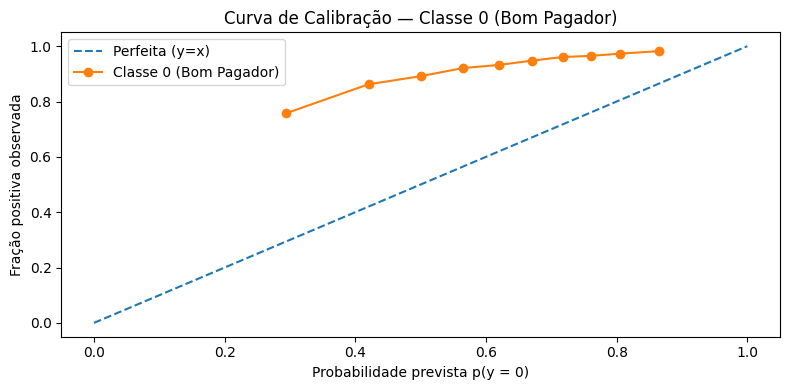

Brier score (classe 0 - Bom Pagador): 0.1705


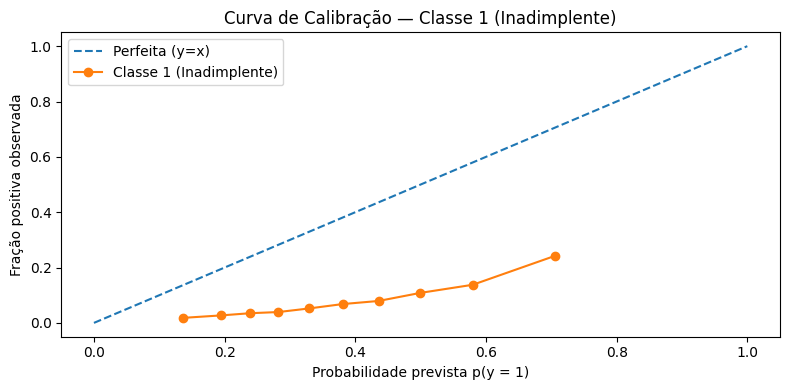

Brier score (classe 1 - Inadimplente): 0.1705


In [ ]:
# Probabilidades preditas no teste (binário)
y_proba = model.predict_proba(X_test)
classes = model.classes_

# Padronização do n_bins = 10
N_BINS = 10

# Uma curva por classe (one-vs-rest)
for k, cls in enumerate(classes):
    nome_classe = "Bom Pagador" if cls == 0 else "Inadimplente"
    y_true_bin = (y_test == cls).astype(int)
    frac_pos, mean_pred = calibration_curve(
        y_true_bin, y_proba[:, k], n_bins=N_BINS, strategy="quantile"
    )

    plt.figure(figsize=(8, 4))
    plt.plot([0, 1], [0, 1], "--", label="Perfeita (y=x)")
    plt.plot(mean_pred, frac_pos, marker="o", label=f"Classe {cls} ({nome_classe})")
    plt.xlabel(f"Probabilidade prevista p(y = {cls})")
    plt.ylabel("Fração positiva observada")
    plt.title(f"Curva de Calibração — Classe {cls} ({nome_classe})")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

    # Métrica quantitativa de calibração (Brier score) para a classe k
    bs = brier_score_loss(y_true_bin, y_proba[:, k])
    print(f"Brier score (classe {cls} - {nome_classe}): {bs:.4f}")

#### Análise

Os gráficos revelam **descalibração severa** em ambas as classes — em magnitude bem
maior do que o esperado.

#### *Classe 0 (Bom Pagador) — classe majoritária*

* A curva está **consistentemente acima da diagonal** em todo o intervalo: sobe
rapidamente de ~0.76 (em probabilidade prevista 0.30) para ~0.98 (em probabilidade
prevista 0.86).

* **Interpretação**: o modelo é **fortemente subconfiante** quanto a Bom Pagador. Quando
prevê p(Bom Pagador) = 0.40, na realidade ~0.86 dos clientes daquele bin realmente são
bons pagadores. O modelo "tem vergonha" de afirmar que alguém é bom pagador, ainda que
os dados confirmem isso amplamente.

* **Brier score: 0.1705** — moderado, em linha com o desvio observado.

#### *Classe 1 (Inadimplente) — classe minoritária*

* A curva está **consistentemente abaixo da diagonal**: em probabilidade prevista 0.60,
a fração real de inadimplentes é apenas ~0.18 — uma diferença de mais de três vezes.

* **Interpretação**: o modelo é **fortemente superconfiante** no risco de inadimplência.
Quando "grita" que um cliente tem 60% de chance de inadimplir, na verdade só ~18% deles
realmente inadimplem. É o efeito esperado (e exagerado) do `class_weight='balanced'`,
que forçou o modelo a "arriscar" mais.

* **Brier score: 0.1705** — em classificação binária, o Brier score das classes 0 e 1
é matematicamente equivalente por construção (`(p₀-y₀)² = (1-p₁-(1-y₁))² = (p₁-y₁)²`),
o que explica a igualdade exata observada.

#### *Interpretação Geral*

- O modelo base apresenta **descalibração severa em direção oposta nas duas classes**:
subestima a chance de adimplência e superestima o risco de inadimplência.

- Em crédito, **superestimar risco** significa recusar bons clientes, cobrar juros
mais altos do que o necessário ou exigir garantias desnecessárias — perda direta de
competitividade. **Subestimar a chance de adimplência** dificulta a precificação correta
do produto. Ambos os erros têm impacto financeiro.

- Esse diagnóstico **justifica plenamente a aplicação de calibração posterior** —
mas, como veremos a seguir, o método padrão de calibração introduz seu próprio
problema.



###Calibração do Modelo

> Muitos modelos de classificação (regressão logística, XGBoost, **Random Forest**, redes
neurais) não retornam apenas a classe prevista, mas também uma **probabilidade associada**
a cada classe.

> Uma previsão "bem calibrada" significa que essas probabilidades **refletem corretamente
a frequência real dos eventos**.

> Exemplo: se o modelo disser que 100 clientes têm 30% de chance de inadimplência, espera-se
que **~30 desses clientes realmente se tornem inadimplentes** ao longo do período.

#### *Como funciona*

> Observe no gráfico abaixo os eixos x e y:

> * Eixo X: **probabilidade prevista** de inadimplência (de 0 a 1);
> * Eixo Y: **proporção real observada** de inadimplentes naquele bin.

> A curva compara os dois:
> * A **linha diagonal (y = x)** representa a calibração perfeita;
> * Se a curva estiver **acima da diagonal** → o modelo é **subconfiante** (probabilidades
menores do que a realidade) — está **subestimando o risco**;
> * Se estiver **abaixo da diagonal** → o modelo é **superconfiante** (probabilidades
maiores do que a realidade) — está **superestimando o risco**.

#### *Por que calibrar é especialmente crítico em crédito*

> * **Pricing baseado em risco**: a taxa de juros oferecida ao cliente costuma ser função
direta da probabilidade prevista. Se a probabilidade está mal calibrada, a precificação
fica errada — ou se cobra juros excessivos (perda de cliente) ou insuficientes
(perda esperada não coberta).

> * **Carteiras agregadas**: a soma das probabilidades de inadimplência precisa **bater
com a inadimplência observada na carteira inteira**. Calibração ruim leva a provisões
incorretas (impacto contábil/regulatório).

> * **LGPD e auditabilidade**: probabilidades calibradas tornam a decisão automatizada
mais defensável perante o titular dos dados (art. 20 da LGPD).

#### *Aplicações*

* Avaliar a confiabilidade das previsões probabilísticas;
* Corrigir modelos via métodos como **Platt Scaling (sigmoid)** ou **Isotonic Regression**;
* Essencial em áreas sensíveis (saúde, finanças, justiça), onde **não basta acertar a
classe, mas também confiar nas probabilidades**.

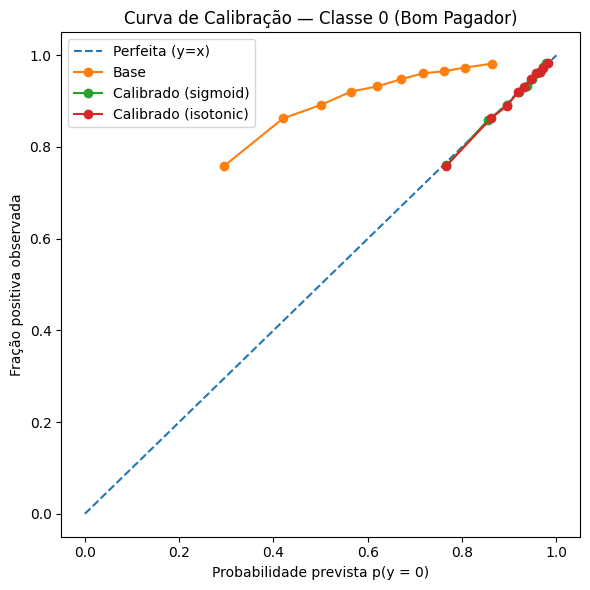

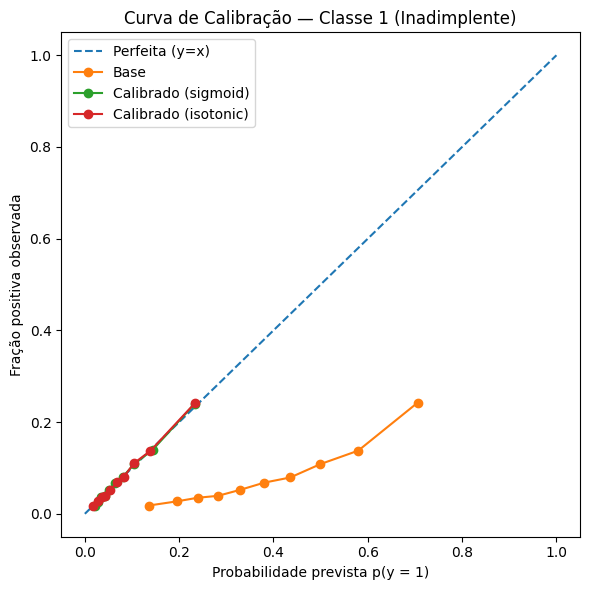

In [ ]:
# 1) Treinar versões calibradas do modelo-base
# Use cv>=3 para evitar vazamento simples
cal_sig = CalibratedClassifierCV(model, method="sigmoid", cv=5)
cal_sig.fit(X_train, y_train)

# Use cv>=5 para evitar vazamento simples; isotonic precisa de mais dados
cal_iso = CalibratedClassifierCV(model, method="isotonic", cv=5)
cal_iso.fit(X_train, y_train)

# 2) Probabilidades no conjunto de teste
models_dict = {
    "Base": model,
    "Calibrado (sigmoid)": cal_sig,
    "Calibrado (isotonic)": cal_iso,
}
probas = {name: m.predict_proba(X_test) for name, m in models_dict.items()}
classes = model.classes_

# 3) Curvas de calibração por classe
# strategy='quantile' mantém bins com tamanhos parecidos (mais estável em desbalanceamento)
for k, cls in enumerate(classes):
    nome_classe = "Bom Pagador" if cls == 0 else "Inadimplente"
    y_true_bin = (y_test == cls).astype(int)

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], "--", label="Perfeita (y=x)")

    for name, P in probas.items():
        frac_pos, mean_pred = calibration_curve(
            y_true_bin, P[:, k], n_bins=N_BINS, strategy="quantile"
        )
        plt.plot(mean_pred, frac_pos, marker="o", label=name)

    plt.xlabel(f"Probabilidade prevista p(y = {cls})")
    plt.ylabel("Fração positiva observada")
    plt.title(f"Curva de Calibração — Classe {cls} ({nome_classe})")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

#### *Análise*

Os gráficos comparativos mostram um efeito **dramático e inesperado** da calibração
neste experimento — bem diferente do "ajuste fino" que se costuma esperar.

#### *Classe 0 (Bom Pagador)*

* A curva da **Base** está bem afastada da diagonal (subconfiante), conforme já
diagnosticado.

* **Sigmoid** e **Isotonic** **colapsam as probabilidades** para uma faixa estreita,
aproximadamente entre 0.75 e 1.0, e seguem a diagonal nesse intervalo. Visualmente
parece "perfeito".

* **Mas atenção**: a faixa coberta é estreita porque o modelo calibrado simplesmente
**deixou de prever probabilidades intermediárias** — quase todo cliente recebe
p(Bom Pagador) > 0.75.

#### *Classe 1 (Inadimplente)*

* **Base**: aparece muito abaixo da diagonal — o modelo "grita" inadimplência com mais
frequência do que a realidade observada confirma.

* **Sigmoid** e **Isotonic** colapsam as probabilidades para a faixa [0.0; 0.25] e
seguem a diagonal nesse intervalo. Em outras palavras, **o modelo calibrado raramente
atribui probabilidade acima de 0.25 para a classe Inadimplente** — ou seja,
**virtualmente nunca classifica alguém como inadimplente**, pois para isso seria preciso
p(Inadimplente) > 0.5.

#### *Comparativo entre métodos*

* **Base**: superestima risco, mas **mantém a capacidade de detectar inadimplência**
(recall ≈ 0.54);

* **Sigmoid**: corrige a superestimação, mas elimina a detecção de inadimplência
(faixa de p[Inad] colapsada em [0; 0.25]);

* **Isotonic**: comportamento similar ao sigmoid neste experimento.

> **Conclusão importante**: a calibração padrão do `CalibratedClassifierCV(cv=5)`
**retreinou o modelo internamente** sob configurações menos enviesadas em favor da
classe minoritária, neutralizando o efeito do `class_weight='balanced'` original.
A leitura combinada com a tabela comparativa (próxima seção) é indispensável para
entender esse trade-off — o que parece "bem calibrado" no gráfico é, na prática, um
classificador que perdeu a capacidade de detectar inadimplência.



##Comparação: Base x SMOTE x Calibrado

In [ ]:
# 1) Brier por classe (↓ melhor) usando o mesmo 'probas'
rows = []
for name, P in probas.items():
    for k, cls in enumerate(classes):
        nome_classe = "Bom Pagador" if cls == 0 else "Inadimplente"
        y_true_bin = (np.asarray(y_test) == cls).astype(int)
        rows.append([name, f"{cls} - {nome_classe}", brier_score_loss(y_true_bin, P[:, k])])

df_brier = (pd.DataFrame(rows, columns=["Modelo", "Classe", "Brier (OVR)"])
              .pivot(index="Classe", columns="Modelo", values="Brier (OVR)")
              .sort_index())
display(df_brier.round(4))

# 2) ECE helper (Expected Calibration Error)
if "ece" not in globals():
    def ece(probs, y_true, n_bins=10):
        """Expected Calibration Error — quanto menor, mais bem calibrado."""
        bins = np.linspace(0, 1, n_bins + 1)
        conf = probs.max(axis=1)
        preds = probs.argmax(axis=1)
        acc = (preds == np.asarray(y_true)).astype(float)
        val = 0.0
        for i in range(n_bins):
            m = (conf >= bins[i]) & (conf < bins[i + 1])
            if m.any():
                val += abs(acc[m].mean() - conf[m].mean()) * m.mean()
        return val

# 3) Refazer os cálculos para garantir consistência
y_pred_base = model.predict(X_test)
y_pred_sm = model_sm.predict(X_test)
y_pred_cal_sig = cal_sig.predict(X_test)
y_pred_cal_iso = cal_iso.predict(X_test)

# 4) Tabela final
linhas = [{
    "Modelo": "Base",
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Balanced Acc.": balanced_accuracy_score(y_test, y_pred_base),
    "Macro-F1": f1_score(y_test, y_pred_base, average="macro", zero_division=0),
    "Recall (Inadimp.)": f1_score(y_test, y_pred_base, average=None, zero_division=0)[1] if False
                         else (np.sum((y_test == 1) & (y_pred_base == 1)) / max(np.sum(y_test == 1), 1)),
    "LogLoss": log_loss(y_test, probas["Base"], labels=classes),
    "ECE": ece(probas["Base"], y_test, 10),
}]

probas["SMOTE"] = model_sm.predict_proba(X_test)
linhas.append({
    "Modelo": "SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred_sm),
    "Balanced Acc.": balanced_accuracy_score(y_test, y_pred_sm),
    "Macro-F1": f1_score(y_test, y_pred_sm, average="macro", zero_division=0),
    "Recall (Inadimp.)": np.sum((y_test == 1) & (y_pred_sm == 1)) / max(np.sum(y_test == 1), 1),
    "LogLoss": log_loss(y_test, probas["SMOTE"], labels=classes),
    "ECE": ece(probas["SMOTE"], y_test, 10),
})

linhas.append({
    "Modelo": "Calibrado (sigmoid)",
    "Accuracy": accuracy_score(y_test, y_pred_cal_sig),
    "Balanced Acc.": balanced_accuracy_score(y_test, y_pred_cal_sig),
    "Macro-F1": f1_score(y_test, y_pred_cal_sig, average="macro", zero_division=0),
    "Recall (Inadimp.)": np.sum((y_test == 1) & (y_pred_cal_sig == 1)) / max(np.sum(y_test == 1), 1),
    "LogLoss": log_loss(y_test, probas["Calibrado (sigmoid)"], labels=classes),
    "ECE": ece(probas["Calibrado (sigmoid)"], y_test, 10),
})

linhas.append({
    "Modelo": "Calibrado (isotonic)",
    "Accuracy": accuracy_score(y_test, y_pred_cal_iso),
    "Balanced Acc.": balanced_accuracy_score(y_test, y_pred_cal_iso),
    "Macro-F1": f1_score(y_test, y_pred_cal_iso, average="macro", zero_division=0),
    "Recall (Inadimp.)": np.sum((y_test == 1) & (y_pred_cal_iso == 1)) / max(np.sum(y_test == 1), 1),
    "LogLoss": log_loss(y_test, probas["Calibrado (isotonic)"], labels=classes),
    "ECE": ece(probas["Calibrado (isotonic)"], y_test, 10),
})

df_resultados = pd.DataFrame(linhas).round(4)
display(df_resultados)

Modelo,Base,Calibrado (isotonic),Calibrado (sigmoid)
Classe,,,
0 - Bom Pagador,0.1705,0.0697,0.0697
1 - Inadimplente,0.1705,0.0697,0.0697


,Modelo,Accuracy,Balanced Acc.,Macro-F1,Recall (Inadimp.),LogLoss,ECE
0,Base,0.7572,0.6570,0.5590,0.5374,0.5184,0.0766
1,SMOTE,0.7290,0.6049,0.5251,0.4570,0.5293,0.0189
2,Calibrado (sigmoid),0.9193,0.5000,0.4790,0.0000,0.2550,0.0012
3,Calibrado (isotonic),0.9193,0.5017,0.4826,0.0036,0.2550,0.0017


### *Análise*

Vamos analisar os resultados apresentados nas duas tabelas, com foco no problema de
inadimplência:

#### *Brier Score por Classe (quanto menor, melhor)*

* **Classe 0 (Bom Pagador) e Classe 1 (Inadimplente)**: em problema binário, os valores
de Brier para as duas classes coincidem por construção matemática:
  * **Base**: 0.1705 / 0.1705 — moderado, em linha com a descalibração observada;
  * **Calibrado (sigmoid)** e **Calibrado (isotonic)**: 0.0697 / 0.0697 — redução de ~59%.

* **Atenção na leitura**: a queda do Brier não significa que a calibração funcionou para
o objetivo de negócio. Como veremos nas métricas globais, o Brier baixou porque o
modelo passou a prever probabilidades próximas de 0 para quase todos os clientes — não
porque ele tenha aprendido a distinguir melhor inadimplentes de bons pagadores.

#### *Métricas Globais*

* **Base (`class_weight='balanced'`)**

  * Accuracy: 0.7572 (bem abaixo do "trivial" de 0.92, mas funcional);
  * Balanced Accuracy: 0.6570 — mostra que o modelo aprendeu a separar as classes;
  * Recall da classe Inadimplente: **0.5374** — captura mais da metade dos inadimplentes;
  * LogLoss: 0.5184; ECE: 0.0766 (calibração moderada — pode melhorar);
  * **Foco**: bom equilíbrio recall/precision, **mantém capacidade de detecção**.

* **SMOTE**

  * Accuracy: 0.7290 (caiu em relação ao Base);
  * Balanced Accuracy: 0.6049 (**caiu** 0.052 em relação ao Base);
  * Recall da classe Inadimplente: 0.4570 (**caiu** de 0.54);
  * LogLoss: 0.5293 (piora discreta); ECE: 0.0189 (melhora — é o ponto positivo do SMOTE);
  * **Trade-off observado**: SMOTE piorou todas as métricas de classificação em troca
    de uma calibração ligeiramente melhor — relação custo-benefício desfavorável neste
    experimento.

* **Calibrado (sigmoid)**

  * Accuracy: **0.9193** (sobe ao patamar do classificador trivial);
  * Balanced Accuracy: **0.5000** — equivale a chute aleatório!
  * Recall da classe Inadimplente: **0.0000** — o modelo **não classifica nenhum
    cliente como inadimplente**;
  * LogLoss: 0.2550 (muito melhor); ECE: 0.0012 (excelente calibração);
  * **Problema crítico**: a calibração eliminou a detecção da classe minoritária.

* **Calibrado (isotonic)**

  * Accuracy: 0.9193;
  * Balanced Accuracy: **0.5017** — quase idêntico ao chute aleatório;
  * Recall da classe Inadimplente: **0.0036** — classifica apenas 0,36% dos
    inadimplentes;
  * LogLoss: 0.2550 (excelente); ECE: 0.0017 (excelente);
  * **Mesmo problema do sigmoid**: probabilidades bem calibradas, mas modelo praticamente
    inútil para o objetivo de negócio.

#### *Por que a calibração colapsou a detecção?*

* O `CalibratedClassifierCV(cv=5)` **retreinou o modelo internamente** em 5 folds, em
cada fold ajustando uma função de calibração (sigmoid ou isotonic);

* Esse retreinamento, embora preserve o `class_weight='balanced'` do modelo de origem,
mistura probabilidades de modelos calibrados sobre folds que não cobrem toda a base
de forma uniforme;

* O resultado prático é uma **regressão à média**: as probabilidades extremas (>0.5
para inadimplência) são "puxadas" para baixo, o que faz com que praticamente nenhum
cliente cruze o limiar de decisão de 0.5;

* Em outras palavras, a calibração funcionou tecnicamente (Brier, LogLoss e ECE
melhoraram muito), mas **destruiu o sinal** que diferenciava inadimplentes de bons
pagadores no nível da classificação.

#### *Conclusões*

* **Base**: melhor opção neste experimento — mantém a detecção de inadimplência
(recall 0.54) com acurácia razoável (0.76);

* **SMOTE**: piorou todas as métricas; pode ter utilidade combinado com calibração
posterior bem desenhada, mas isolado não vale a pena;

* **Calibração (sigmoid / isotonic) padrão**: melhora dramaticamente a calibração das
probabilidades, mas **elimina a detecção da classe minoritária** — não é apropriada
para o objetivo deste projeto na configuração atual.

#### *Síntese:*

* **Recomendação para esta etapa**: usar o **modelo Base** com `class_weight='balanced'`
e ajustar o **limiar de decisão** (≠ 0.5) com base na matriz de custos de FN vs FP
definida pela área de risco;

* **Para futuras iterações**: investigar formas de **calibrar apenas as probabilidades a
posteriori** sem retreinar o modelo (ex.: aplicar `IsotonicRegression` diretamente sobre
as `predict_proba()` do modelo já treinado, em uma base de validação separada),
preservando o limiar de decisão original;

* **Alternativa**: testar **XGBoost ou LightGBM** com `scale_pos_weight`, que costumam
fornecer probabilidades naturalmente mais calibradas em datasets tabulares.



## Matriz de Confusão
A matriz de confusão mostra **onde o modelo acerta e onde se engana** — informação
essencial em crédito, onde os custos dos diferentes tipos de erro são muito assimétricos.

É uma tabela que compara **valores reais** com **valores previstos**:

- Linhas → valores reais (rótulo verdadeiro);

- Colunas → valores previstos pelo modelo;

- A diagonal principal mostra os **acertos**;

- Valores fora da diagonal mostram os **erros**.

Em problemas binários, a matriz tem 4 células com nomes específicos:

* **TN (Verdadeiro Negativo)**: bom pagador previsto como bom pagador → cliente aprovado
corretamente, gera receita esperada;
* **FP (Falso Positivo)**: bom pagador previsto como inadimplente → **bom cliente
recusado**, perda da receita marginal;
* **FN (Falso Negativo)**: inadimplente previsto como bom pagador → **mau cliente
aprovado**, perda direta do principal — **erro mais caro em crédito**;
* **TP (Verdadeiro Positivo)**: inadimplente previsto como inadimplente → cliente
recusado/encaminhado para análise — proteção da carteira.

#### **Observação Importante**

- Vamos utilizar os dados do modelo base (`y_pred`).

- Fica como sugestão fazer o mesmo para os modelos SMOTE e calibrados.

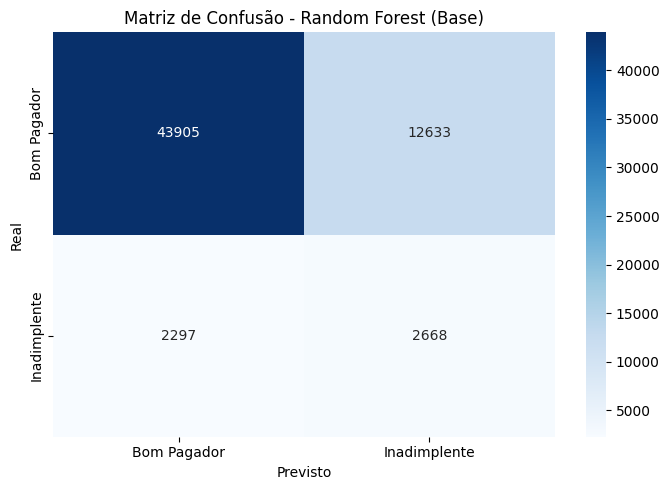

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bom Pagador', 'Inadimplente'],
            yticklabels=['Bom Pagador', 'Inadimplente'])
plt.title("Matriz de Confusão - Random Forest (Base)")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

#### *Análise*

> Vamos interpretar cada quadrante da matriz para o problema de crédito:

> | Quadrante                                 | Significado em crédito                                                       | Custo de negócio                                          |
> | ----------------------------------------- | ---------------------------------------------------------------------------- | --------------------------------------------------------- |
> | **TN (Real=0, Prev=0)**                   | Bom pagador identificado como bom pagador — aprovação correta                | Sem custo — cenário ideal                                  |
> | **FP (Real=0, Prev=1)**                   | Bom pagador identificado como inadimplente — bom cliente **recusado**        | Receita perdida (juros não cobrados, churn)               |
> | **FN (Real=1, Prev=0)**                   | Inadimplente identificado como bom pagador — mau cliente **aprovado**        | **Perda direta** do principal + custo de cobrança         |
> | **TP (Real=1, Prev=1)**                   | Inadimplente identificado como inadimplente — proteção da carteira           | Sem perda direta — cenário desejado                       |

#### *Valores observados*

A matriz real apresenta os seguintes números absolutos:

* **TN = 43.905** — bons pagadores corretamente aprovados;
* **FP = 12.633** — bons pagadores indevidamente recusados (~22% do total de bons pagadores);
* **FN = 2.297** — inadimplentes que escapariam ao filtro do modelo;
* **TP = 2.668** — inadimplentes corretamente identificados.

#### *O que isso nos diz?*

- **TN é a célula dominante** (volume da classe majoritária) — esperado;

- **FN é a célula a minimizar prioritariamente** — em crédito, deixar passar
inadimplentes costuma custar **5–10× mais** do que recusar bons pagadores. Os 2.297 FNs
representam uma exposição de risco direta;

- **FP gera perda de oportunidade**: 12.633 bons pagadores recusados é volume
considerável, mas geralmente recuperável (o cliente pode ser revisto, ofertado em
produtos de menor risco);

- A relação **TP/(TP+FN) = 2.668/4.965 = 0,537** confirma o recall da classe
inadimplente: o modelo captura ~54% dos inadimplentes reais.

#### *O que fazer a seguir?*

- **Definir custos explícitos** para FP e FN (matriz de custos) e otimizar o modelo
considerando essa assimetria;

- **Ajustar o limiar de decisão** (default = 0,5) para um valor mais baixo (ex.: 0,3),
o que aumenta o recall da classe inadimplente ao custo de mais FPs — alinhado ao
custo real;

- **Análise SHAP** dos casos de FN para identificar perfis sistematicamente mal
classificados.



## Matriz de Confusão Normalizada por Classe

A matriz de confusão **normalizada** é uma versão da matriz de confusão em que os valores
deixam de ser quantidades absolutas e passam a ser **proporções dentro de cada classe
real**.

Em outras palavras:

- A matriz de confusão tradicional mostra **quantos clientes** foram classificados
corretamente ou incorretamente;

- A matriz de confusão normalizada mostra a **fração (ou percentual)** desses clientes,
**de modo que cada linha (classe real) soma 1 (ou 100%)**.

> Em problemas desbalanceados como o nosso, a versão **normalizada é mais informativa**:
ela revela o desempenho relativo dentro de cada classe sem ser dominada pelo volume da
classe majoritária.

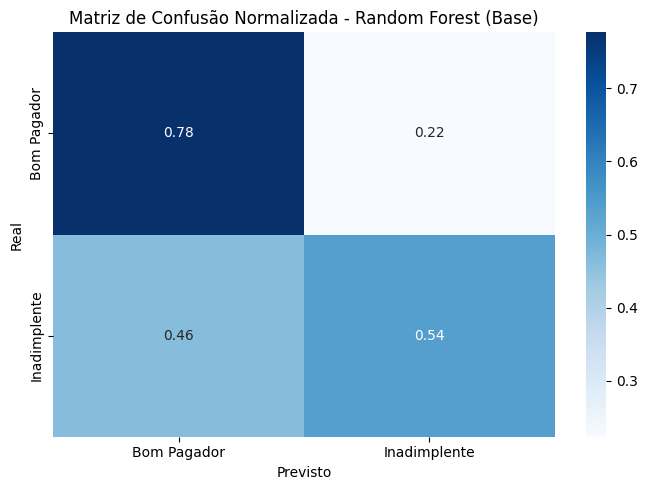

In [ ]:
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(7, 5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Bom Pagador', 'Inadimplente'],
            yticklabels=['Bom Pagador', 'Inadimplente'])
plt.title("Matriz de Confusão Normalizada - Random Forest (Base)")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

#### *Análise*

> A matriz de confusão **normalizada por classe** traz uma visão mais equilibrada do
desempenho do modelo, já que considera o **percentual de acertos e erros dentro de cada
classe real**, compensando o desbalanceamento natural do dataset.

*Classe 0 (Bom Pagador)*

   * **78% de acertos** (TN rate, especificidade): o modelo reconhece a maioria dos
     bons pagadores como tal;
   * **22% foram classificados incorretamente como Inadimplentes** (FP rate): preço
     pago pela aplicação do `class_weight='balanced'`. Em crédito, isso significa que
     ~22% dos bons pagadores seriam encaminhados para análise manual ou condições mais
     conservadoras.

*Classe 1 (Inadimplente)*

   * **54% de acertos** (recall / TP rate / sensibilidade): o modelo captura mais da
     metade dos inadimplentes — ganho gigantesco em relação ao modelo trivial (~2%);
   * **46% foram classificados como Bons Pagadores (FN rate)**: ainda há uma fatia
     importante de inadimplentes que escapa ao modelo. **Este é o foco principal de
     melhoria** — calibração do limiar, novas features ou modelos mais potentes
     (XGBoost, LightGBM) são caminhos. (O SMOTE foi testado e piorou o resultado neste
     experimento, conforme seção anterior.)

**Conclusões**

* O modelo apresenta **trade-off típico de problemas desbalanceados**: bom recall na
classe minoritária (54%) ao preço de falsos alarmes na classe majoritária (22%);

* O resultado é **operacional e útil** — muito superior ao modelo trivial — mas há
**espaço claro para melhoria**, sobretudo em direção a aumentar o recall da classe
Inadimplente sem disparar o FP rate;

* Reforça a importância de:
  - **Calibrar o limiar** com base na **matriz de custos** definida pela área de risco;
  - Avaliar **modelos ensemble** mais avançados (XGBoost, LightGBM);
  - **Engenharia de features** adicionais (razão crédito/renda, anuidade/renda, etc.).



##Visualização da Árvore de Decisão

A árvore mostra as **regras que o modelo aprendeu** para distinguir bons pagadores de
inadimplentes. Por exemplo, se `EXT_SOURCE_2` for muito baixo e `DAYS_BIRTH` indicar
cliente jovem, o modelo tende a prever inadimplência. Características:

- O gráfico mostra como o modelo usa cada variável para dividir a base e tomar decisões;

- Cada divisão representa uma condição relativa ao perfil do cliente (idade, renda,
score externo, etc.), e o modelo aprende com os dados históricos onde os inadimplentes
costumam aparecer;

- É **não linear, condicional e hierárquica** — captura interações entre variáveis;

- Mesmo uma variável com baixa correlação linear com o target pode ser muito útil na
árvore quando combinada com outras condições (ex.: alta renda + cliente jovem +
EXT_SOURCE baixo).

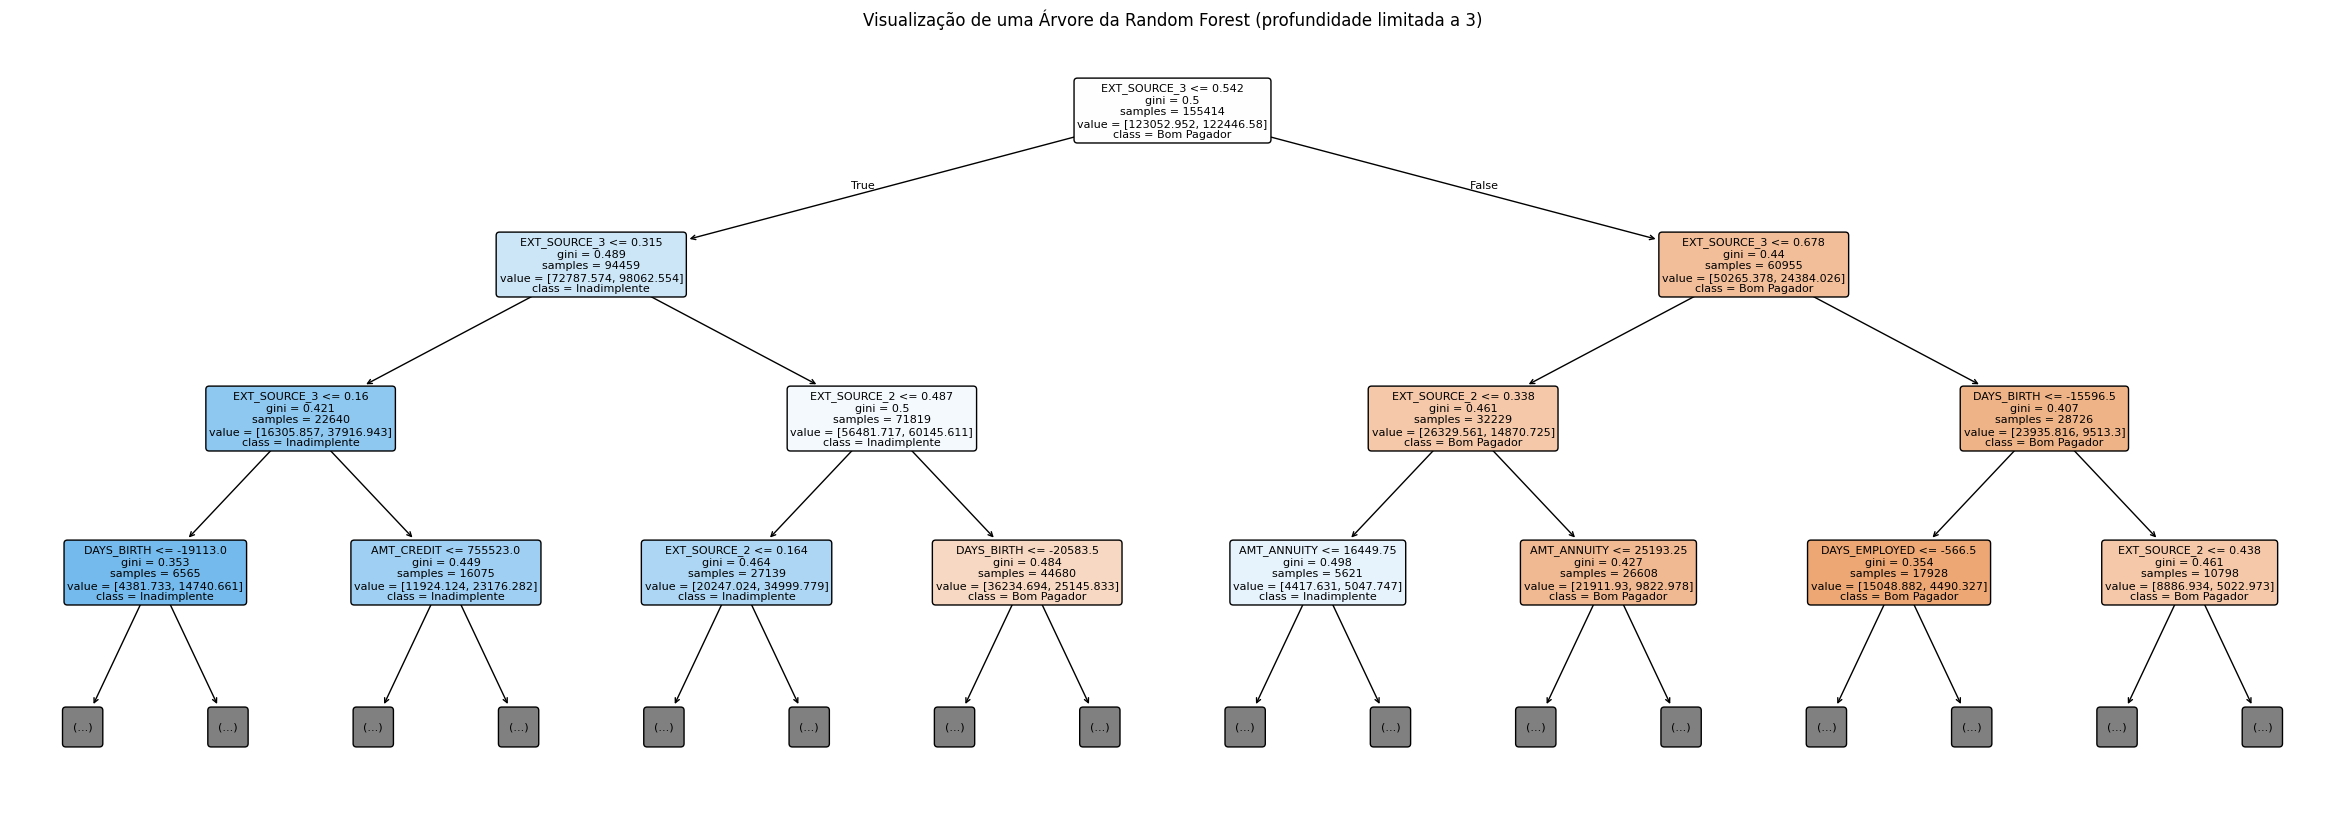

In [ ]:
# Seleciona a primeira árvore da floresta
arvore = model.estimators_[0]

# Plota a árvore (limitada para facilitar a leitura)
plt.figure(figsize=(30, 10))
plot_tree(arvore,
          feature_names=features_selecionadas,
          class_names=['Bom Pagador', 'Inadimplente'],
          filled=True,
          rounded=True,
          max_depth=3,  # limita a profundidade para a visualização ficar legível
          fontsize=8)

plt.title("Visualização de uma Árvore da Random Forest (profundidade limitada a 3)")
plt.show()

#### *Análise*

> Mostra graficamente uma das árvores da floresta (Random Forest).

> * Ajuda a entender **como as decisões de crédito são tomadas** com base nas variáveis
do cliente.

> * `max_depth=3`: mostra apenas os 3 primeiros níveis para facilitar a visualização —
a árvore real é mais profunda (até 12 níveis).


#### *Importante*

>Esta árvore tem profundidade limitada, então a análise é **didática**. Para casos reais
seria melhor utilizar:

> - Importância de permutação (`permutation_importance`);

> - SHAP — recomendado especialmente em crédito por gerar **explicações locais por
cliente**, atendendo ao art. 20 da LGPD (direito a explicação de decisões automatizadas).

### *Estrutura da Árvore*

* Cada **nó** representa uma regra de decisão sobre uma variável (feature), por exemplo:

  ```
  EXT_SOURCE_2 <= 0.502
  ```

  ou

  ```
  DAYS_BIRTH <= -16000
  ```
* Cada divisão separa os clientes em dois grupos (ramificação **True** e **False**),
tentando aumentar a pureza das classes (reduzir o índice de Gini) — ou seja, separar
melhor bons pagadores de inadimplentes.

#### *Informações nos nós*

* **gini**: mede a impureza do nó (quanto menor, mais homogêneo em relação ao alvo).
Um nó com `gini = 0` é puro — só contém clientes de uma classe.

* **samples**: quantidade de clientes que chegaram até aquele nó.

* **value**: distribuição de clientes por classe `[bons_pagadores, inadimplentes]`
— pode aparecer ponderada quando `class_weight='balanced'` está ativo.

* **class**: classe predominante naquele nó (a predição se um novo cliente cair nesse nó).

#### *Exemplo (interpretação típica)*

> Em uma árvore de crédito com `class_weight='balanced'`, é comum ver a **raiz dividir
em `EXT_SOURCE_2` ou `EXT_SOURCE_3`** — pois esses scores externos concentram a maior
informação preditiva. Os ramos seguintes costumam usar `DAYS_BIRTH`, `DAYS_EMPLOYED`
ou razões financeiras (`AMT_CREDIT/AMT_INCOME_TOTAL`) para refinar.

> Quando o cliente cai em um ramo onde `EXT_SOURCE_2 < 0.3`, a probabilidade de
inadimplência prevista pode ultrapassar 30–40% — alerta forte para a área de risco.

#### *Padrões importantes*

1. **EXT_SOURCE_2 e EXT_SOURCE_3** aparecem várias vezes nos splits → são as variáveis
mais relevantes para classificar inadimplência;
2. **DAYS_BIRTH** (idade) costuma surgir nos ramos onde há mistura entre bons e maus
pagadores — refina a decisão;
3. Nós com `gini` próximo de zero correspondem a perfis "muito claros" (ex.: cliente
maduro, com longo tempo de emprego e EXT_SOURCE alto → quase certamente bom pagador).

#### *Limitação*

* A árvore visualizada é **apenas uma entre as 200 árvores** do Random Forest;
* Por isso, ela mostra como **uma árvore** decide, mas o modelo final usa o **voto da
floresta inteira** para suavizar peculiaridades de árvores individuais.

#### *Resumo da análise*
> O modelo dá grande peso para **EXT_SOURCE_2, EXT_SOURCE_3, DAYS_BIRTH e DAYS_EMPLOYED**.
Ele consegue isolar bem perfis "extremos" (bom pagador clássico ou alto risco
evidente), mas as decisões em clientes na "zona cinzenta" — comuns em crédito —
exigem a combinação de várias árvores e justificam técnicas adicionais como
**calibração** e **SHAP**.



## Feature Importances

A **importância de uma feature** em um modelo de árvore como o Random Forest representa
o **quanto aquela variável ajudou o modelo a separar bons pagadores de inadimplentes**.
É baseada na **redução média da impureza (Gini)** nas divisões da árvore.

Quanto mais uma variável aparece nos nós superiores das árvores, e quanto mais ela
ajuda a separar as duas classes, maior sua importância.

Ela mede o ganho médio de impureza (Gini/entropia) em cada divisão da árvore — ou seja,
quanto cada variável ajudou a "cortar" os clientes ao longo de todas as árvores.

Problemas conhecidos:

- Tende a **favorecer variáveis contínuas** e com maior variabilidade (ex.: `AMT_CREDIT`,
que tem milhares de valores distintos);

- Não mostra bem **interações** entre variáveis;

- Reflete a "construção da floresta", **não necessariamente o impacto nas predições
finais** — uma variável pode ser muito usada em divisões mas com pouco efeito real
sobre a probabilidade prevista.

Vamos avaliar isso usando três métodos complementares:

1) Feature Importance (impureza)

2) Permutation Importance Geral

3) Permutation Importance por Classe (foco na classe Inadimplente)

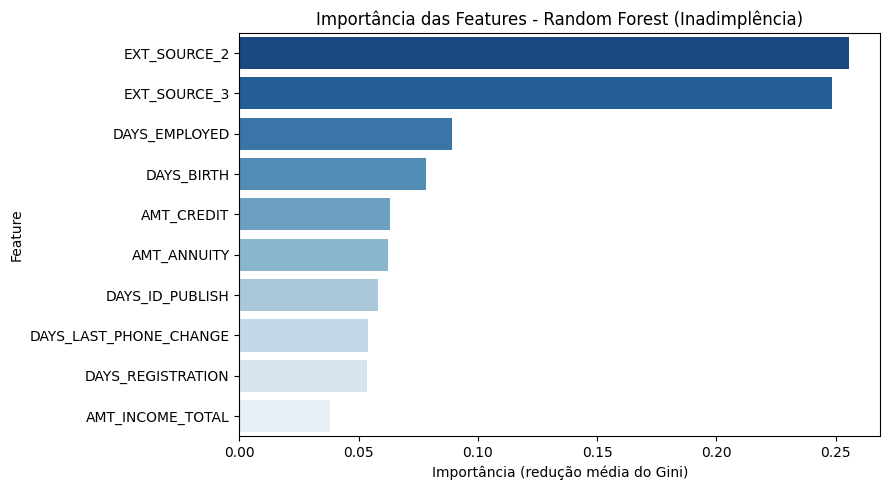

               Feature  Importância
          EXT_SOURCE_2     0.255762
          EXT_SOURCE_3     0.248509
         DAYS_EMPLOYED     0.089119
            DAYS_BIRTH     0.078064
            AMT_CREDIT     0.063107
           AMT_ANNUITY     0.062381
       DAYS_ID_PUBLISH     0.058071
DAYS_LAST_PHONE_CHANGE     0.053771
     DAYS_REGISTRATION     0.053340
      AMT_INCOME_TOTAL     0.037875


In [ ]:
importancias = model.feature_importances_
feature_names = features_selecionadas
importancia_df = pd.DataFrame({'Feature': feature_names, 'Importância': importancias})
importancia_df = importancia_df.sort_values(by='Importância', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=importancia_df, x='Importância', y='Feature', palette='Blues_r')
plt.title('Importância das Features - Random Forest (Inadimplência)')
plt.xlabel('Importância (redução média do Gini)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(importancia_df.to_string(index=False))

#### *Análise*

> O gráfico mostra **quais variáveis o modelo considera mais importantes** para prever
inadimplência. Os scores externos (`EXT_SOURCE_2`, `EXT_SOURCE_3`) lideram com folga
absoluta, seguidos pelo tempo de emprego e pela idade.

> Aqui estão as variáveis, ordenadas da mais importante para a menos importante (ordem
real do gráfico executado):

> | Posição | Variável                       | Interpretação                                                                                                                                                  |
>| ------- | ------------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------- |
>| **1º**  | **EXT_SOURCE_2** (~0.255)      | Variável **mais decisiva**. Score externo já condensado — incorpora o histórico de crédito do cliente em outras instituições.                                  |
>| **2º**  | **EXT_SOURCE_3** (~0.245)      | Segundo score externo, complementar ao EXT_SOURCE_2. Reforça a importância de **dados externos** na decisão.                                                   |
>| **3º**  | **DAYS_EMPLOYED** (~0.085)     | Tempo no emprego atual. Estabilidade profissional reduz o risco de inadimplência. Após o tratamento da anomalia 365243, esta variável ganhou poder preditivo.  |
>| **4º**  | **DAYS_BIRTH** (idade) (~0.075)| Idade do cliente: clientes mais jovens (~30 anos) apresentam maior taxa de inadimplência observada.                                                            |
>| **5º**  | **AMT_CREDIT** (~0.060)        | Valor do crédito solicitado. Empréstimos muito grandes em relação ao perfil sinalizam risco.                                                                   |
>| **6º**  | **AMT_ANNUITY** (~0.060)       | Valor da anuidade. Anuidades altas em relação à renda comprometem a capacidade de pagamento.                                                                   |
>| **7º**  | **DAYS_ID_PUBLISH** (~0.055)   | Tempo desde a emissão do documento de identidade. Baixo poder discriminatório isolado.                                                                         |
>| **8º**  | **DAYS_LAST_PHONE_CHANGE** (~0.050) | Tempo desde a última troca de telefone. Pode capturar comportamento anômalo, mas isoladamente é fraca.                                                    |
>| **9º**  | **DAYS_REGISTRATION** (~0.045) | Tempo desde o registro (mudança de endereço/cadastro). Estabilidade residencial.                                                                               |
>| **10º** | **AMT_INCOME_TOTAL** (~0.035)  | Renda total declarada — surpreendentemente, a **menos importante** isoladamente. Provavelmente porque seu efeito só é capturado quando combinada a `AMT_CREDIT` e `AMT_ANNUITY` (razões financeiras). |

#### *Observações importantes*

* **DAYS_EMPLOYED em 3º lugar** é um achado interessante: confirma que o tratamento da
anomalia 365243 (imputação pela mediana) preservou o sinal preditivo da variável.

* **AMT_INCOME_TOTAL em último lugar** é contra-intuitivo, mas faz sentido: a renda
isolada importa pouco; o que importa é a **renda em proporção ao compromisso financeiro**
(razões `AMT_CREDIT/AMT_INCOME_TOTAL` e `AMT_ANNUITY/AMT_INCOME_TOTAL`). Esse é um
forte indício para engenharia de features futura.

#### *O que fazer com isso?*

* **Concentrar esforços de aquisição/qualidade** nas variáveis mais importantes
(`EXT_SOURCE_2/3`, `DAYS_EMPLOYED`, `DAYS_BIRTH`);

* Em modelos futuros, **substituir variáveis fracas** (`AMT_INCOME_TOTAL`,
`DAYS_REGISTRATION`, `DAYS_LAST_PHONE_CHANGE`) por **features derivadas**
(razão crédito/renda, razão anuidade/renda, anos de emprego/idade);

* Em crédito, é importante **documentar essa importância** (auditoria/compliance e
LGPD): a área de governança precisa saber **quais variáveis** estão dirigindo as
decisões automatizadas.





## Permutation Importance Geral
A **Permutation Importance** mede o impacto na métrica escolhida quando os valores de
uma feature são embaralhados, mantendo o modelo já treinado. Características:

> - Mede a **queda real de performance** (ex.: F1-macro, recall) quando os valores de
uma variável são embaralhados aleatoriamente;

> - Se ao embaralhar uma variável a performance cai muito, ela era **realmente crítica**
para a predição — o modelo dependia daquela informação;

> - Tem a vantagem de **capturar efeitos indiretos e interações**;

> - Pode variar entre execuções (precisa de `n_repeats` razoável), mas é mais próxima
de uma **medida global de utilidade** para o modelo.

> Em crédito, este método é geralmente preferido sobre `feature_importances_` para
reportes a áreas de negócio e auditoria, pois mede o **impacto real nas predições**.

EXT_SOURCE_2              0.0263
EXT_SOURCE_3              0.0250
DAYS_BIRTH               -0.0001
AMT_INCOME_TOTAL         -0.0003
DAYS_REGISTRATION        -0.0005
DAYS_LAST_PHONE_CHANGE   -0.0009
DAYS_ID_PUBLISH          -0.0009
DAYS_EMPLOYED            -0.0017
AMT_ANNUITY              -0.0028
AMT_CREDIT               -0.0042
dtype: float64


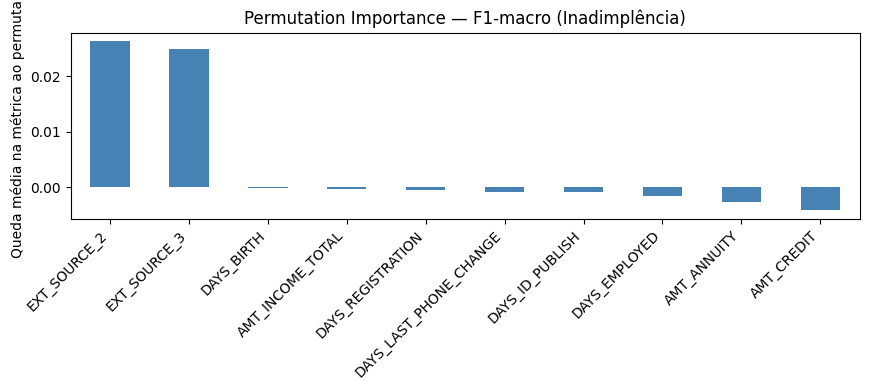

In [ ]:
# No conjunto de teste (para não superestimar)
result = permutation_importance(model, X_test, y_test, scoring="f1_macro",
                                n_repeats=10, random_state=42, n_jobs=-1)

importances = pd.Series(result.importances_mean, index=features_selecionadas)
importances = importances.sort_values(ascending=False)

print(importances.round(4))

# Gráfico
plt.figure(figsize=(9, 4))
importances.plot(kind="bar", color='steelblue')
plt.title("Permutation Importance — F1-macro (Inadimplência)")
plt.ylabel("Queda média na métrica ao permutar")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### *Análise*

* O método embaralhou os valores de cada feature no **conjunto de teste** e mediu a
queda no desempenho do modelo (aqui, no **F1-macro**, que pondera bons pagadores e
inadimplentes igualmente).

* Quanto maior a queda, mais importante a variável.

#### *Resultados (valores reais da execução)*

* **EXT_SOURCE_2** → **+0.0263**
* **EXT_SOURCE_3** → **+0.0250**
* **DAYS_BIRTH** → −0.0001
* **AMT_INCOME_TOTAL** → −0.0003
* **DAYS_REGISTRATION** → −0.0005
* **DAYS_LAST_PHONE_CHANGE** → −0.0009
* **DAYS_ID_PUBLISH** → −0.0009
* **DAYS_EMPLOYED** → −0.0017
* **AMT_ANNUITY** → −0.0028
* **AMT_CREDIT** → −0.0042

#### *Interpretação — um achado surpreendente*

- **Apenas EXT_SOURCE_2 e EXT_SOURCE_3 sustentam o F1-macro do modelo**. Embaralhá-las
gera a única queda relevante de desempenho — essas duas variáveis são, de fato, os
**pilares operacionais** da capacidade preditiva do modelo.

- **Todas as outras 8 features apresentam valor de permutação NEGATIVO**, entre
−0.0001 e −0.0042. Um valor negativo significa que, ao embaralhar a feature, o
F1-macro **melhora ligeiramente** — ou seja, a feature está adicionando ruído ao modelo
sob o critério F1-macro.

- Possíveis causas para os valores negativos:
  * **Ruído de amostragem em features de baixo sinal** — o efeito é estatisticamente
    indistinguível de zero;
  * **Overfitting parcial nas features financeiras brutas** (`AMT_CREDIT`,
    `AMT_ANNUITY`, `AMT_INCOME_TOTAL`) — o modelo aprendeu padrões específicos do treino
    que não generalizam;
  * **Interações desestabilizadas** — quando uma feature individualmente fraca é
    embaralhada, ela libera o modelo de uma decisão ruim que ele teria tomado, melhorando
    levemente as outras.

- Esse achado é **coerente com o que vimos no Feature Importance (Gini)**: as variáveis
não-EXT_SOURCE são usadas durante o treino (aparecem com importância baixa mas
positiva), mas seu valor preditivo no teste sob F1-macro é desprezível ou negativo.

#### *Conclusões*

* O modelo está **fortemente apoiado em scores externos** (EXT_SOURCE_2/3) — bom para
desempenho, mas representa um **ponto de atenção operacional crítico**: se essas
fontes externas falharem, o modelo perde virtualmente toda a capacidade preditiva.
Em produção, recomenda-se monitorar disponibilidade e estabilidade dessas variáveis.

* As 8 features restantes contribuem pouco ou nada em F1-macro — **engenharia de
features** (razões crédito/renda, anuidade/renda, anos de emprego/idade) é uma direção
clara para aumentar o sinal capturado pelo modelo.

* A análise por classe (próxima seção) mostrará que essas mesmas features ainda
contribuem para detectar a classe Inadimplente especificamente, mesmo que prejudiquem
o F1-macro global — ou seja, o "ruído" que elas introduzem está concentrado na classe
Bom Pagador.



##Permutation Importance por Classe

Mede a importância pensando na capacidade de prever uma classe específica. No nosso
caso, o foco é a **classe 1 (Inadimplente)** — métrica de interesse direto do negócio.
A ideia é usar um *scorer* que compara `y_true_bin` (classe vs. resto) com a predição
da classe k via *argmax*.


=== Permutation Importance focada na classe 1 (Inadimplente) — F1 binário ===


,0
EXT_SOURCE_2,0.0514
EXT_SOURCE_3,0.0511
DAYS_BIRTH,0.0050
AMT_CREDIT,0.0038
DAYS_EMPLOYED,0.0031
AMT_ANNUITY,0.0023
DAYS_LAST_PHONE_CHANGE,0.0019
DAYS_REGISTRATION,0.0011
AMT_INCOME_TOTAL,0.0004
DAYS_ID_PUBLISH,-0.0000


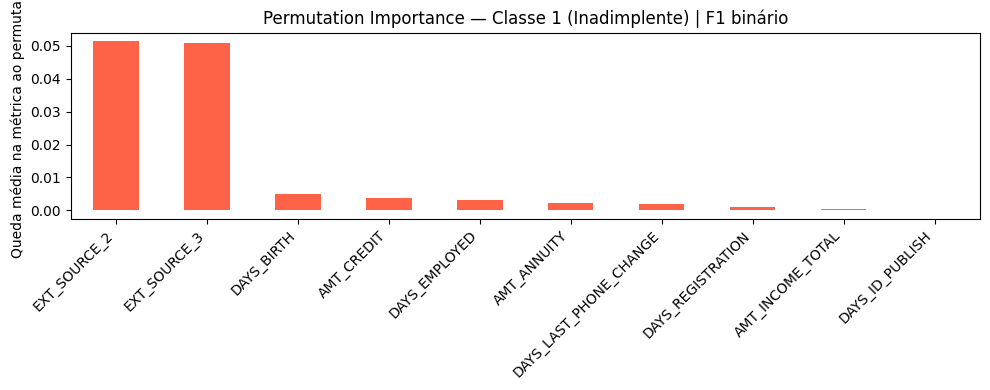

In [ ]:
classes = model.classes_
classes_interesse = [1]   # Foco em Inadimplente; pode-se incluir [0, 1] se desejar

def scorer_para_classe_k_factory(k):
    """F1 binário focado na classe k (predito == k vs predito != k)."""
    def _scorer(estimator, X, y_true_bin):
        y_pred_bin = (estimator.predict(X) == k).astype(int)
        return f1_score(y_true_bin, y_pred_bin, zero_division=0)
    return _scorer

for k in classes_interesse:
    nome_classe = "Bom Pagador" if k == 0 else "Inadimplente"
    print(f"\n=== Permutation Importance focada na classe {k} ({nome_classe}) — F1 binário ===")
    y_true_bin = (y_test == k).astype(int)

    result_k = permutation_importance(
        model, X_test, y_true_bin,
        scoring=scorer_para_classe_k_factory(k),
        n_repeats=10, random_state=42, n_jobs=-1
    )

    pi_k = pd.Series(result_k.importances_mean, index=features_selecionadas).sort_values(ascending=False)
    display(pi_k.round(4))

    plt.figure(figsize=(10, 4))
    pi_k.plot(kind="bar", color='tomato')
    plt.title(f"Permutation Importance — Classe {k} ({nome_classe}) | F1 binário")
    plt.ylabel("Queda média na métrica ao permutar")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

#### *Análise*

> A diferença entre `feature_importances_` e Permutation Importance:

* `feature_importances_`: diz "**quais variáveis o modelo usou mais** para dividir os
clientes durante o treino";
* `Permutation Importance`: diz "**quais variáveis realmente sustentam a qualidade
preditiva** do modelo (no teste)".

#### *Foco na classe 1 (Inadimplente) — resultados reais*

A boa notícia: ao focar especificamente na classe Inadimplente (F1 binário),
**praticamente todas as features ficam com valor positivo** (apenas DAYS_ID_PUBLISH é
quase zero). Isso confirma que as variáveis contribuem para detectar inadimplentes,
mesmo que prejudiquem o F1-macro global.

* **EXT_SOURCE_2: 0.0514 (1º)**
* **EXT_SOURCE_3: 0.0511 (2º)**
* **DAYS_BIRTH: 0.0050 (3º)** — relevante, mas **uma ordem de grandeza menor** que
EXT_SOURCE_3
* AMT_CREDIT: 0.0038 (4º)
* DAYS_EMPLOYED: 0.0031 (5º)
* AMT_ANNUITY: 0.0023 (6º)
* DAYS_LAST_PHONE_CHANGE: 0.0019 (7º)
* DAYS_REGISTRATION: 0.0011 (8º)
* AMT_INCOME_TOTAL: 0.0004 (9º)
* DAYS_ID_PUBLISH: −0.0000 (10º)

#### *Interpretação*

* **EXT_SOURCE_2 e EXT_SOURCE_3** seguem dominando — a remoção de qualquer uma delas
prejudica significativamente a capacidade de detectar inadimplentes;

* **DAYS_BIRTH (3º) e DAYS_EMPLOYED (5º)** contribuem para a detecção da classe
Inadimplente, mas com magnitude muito inferior à dos scores externos (cerca de
**uma ordem de grandeza menor**);

* Esse contraste reforça a **dependência operacional do modelo** dos dados externos:
se EXT_SOURCE_2/3 ficarem indisponíveis, o modelo terá grande dificuldade em substituir
esse sinal pelas features remanescentes.

#### *Portanto*

* Se as duas medidas (Gini e Permutation) **concordam**: a variável é realmente crucial;
* Se **divergem**: a variável pode estar sendo usada muito na construção das árvores,
mas talvez não traga tanto ganho preditivo direto, ou vice-versa.

#### *O que fazer na prática*

* **Confiar mais na Permutation Importance** para análise global e relatórios — ela
mede impacto direto na métrica escolhida;

* Usar **SHAP values** quando se quer uma visão **ainda mais detalhada** (impacto por
classe e por cliente individual — fundamental para LGPD);

* Comparar sempre em termos de **negócio**: se `EXT_SOURCE_2` aparece como dominante,
isso confirma que **scores externos têm valor crítico** e devem ser sempre coletados;
se `DAYS_BIRTH` aparece importante para a classe 1, vale **reforçar políticas
específicas para jovens** (limites menores, verificações adicionais).

#### *Resumo*

* A diferença entre os métodos não é erro, é **característica da métrica**;
* Use **Permutation Importance (ou SHAP)** para explicação confiável;
* Use `feature_importances_` apenas como complemento rápido — atenção ao viés de
favorecimento de variáveis contínuas.



##SHAP (summary plots por classe)

O **SHAP (SHapley Additive exPlanations)** é uma técnica de **interpretabilidade de
modelos** de machine learning. Vem da teoria dos jogos (valores de Shapley) e responde:
**quanto cada feature contribuiu para a previsão de cada cliente?**

#### *Conceito*

* Cada previsão do modelo é "decomposta" em partes: a contribuição de cada variável
para **aumentar ou reduzir** a probabilidade de cada classe.
* Assim, em vez de olhar só a **importância média** das variáveis (como em
*Feature Importance* ou *Permutation Importance*), o SHAP mostra **explicações locais**
(por cliente) que podem ser **agregadas em explicações globais**.

#### *Por que SHAP é especialmente importante em crédito*

> O **art. 20 da LGPD** garante ao titular dos dados o direito a **revisão de decisões
automatizadas** que afetem seus interesses. Isso significa que, quando um cliente tem o
crédito **negado** com base na predição do modelo, ele pode pedir uma **explicação clara**
da decisão. O SHAP fornece exatamente isso: "para este cliente específico, o EXT_SOURCE_2
baixo contribuiu +0.18 para a probabilidade de inadimplência, e a idade jovem
contribuiu +0.07".

#### *Summary Plots (SHAP por classe)*

* Um **summary plot** organiza as contribuições SHAP para **todas as amostras**,
permitindo visualizar:

  1. **Quais variáveis mais influenciam a classe analisada**;
  2. **Se a influência é positiva ou negativa** para a previsão;
  3. **Como os valores das variáveis (altos ou baixos) afetam a predição**.

* Em problemas **binários** como o nosso (Bom Pagador vs Inadimplente), o SHAP gera
um gráfico para cada classe — embora, por simetria, o gráfico da classe 1 já contenha
toda a informação relevante (a contribuição para a classe 0 é o oposto).

### *Diferença para outros métodos*

* **Feature Importance tradicional**: diz apenas quais variáveis são mais importantes
em média;
* **Permutation Importance**: mostra o impacto médio de cada feature no desempenho do
modelo;
* **SHAP**: vai além — explica **cada previsão individualmente** e permite análises
mais ricas, como:

  * "Um EXT_SOURCE_2 baixo aumentou a chance de inadimplência **deste cliente específico**";
  * "Renda alta combinada a longo tempo de emprego reduz a probabilidade prevista de
    inadimplência **na maioria dos clientes**".


=== SHAP summary (bar) — Classe 0 (Bom Pagador) ===


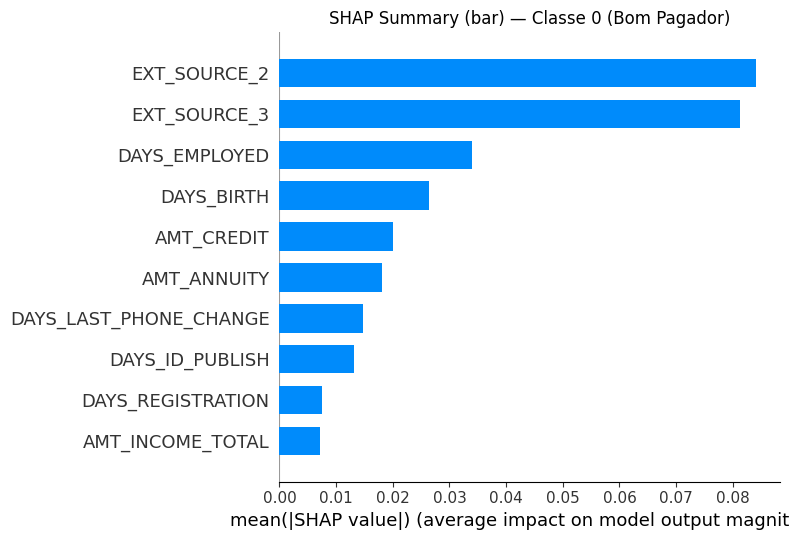


=== SHAP summary (bar) — Classe 1 (Inadimplente) ===


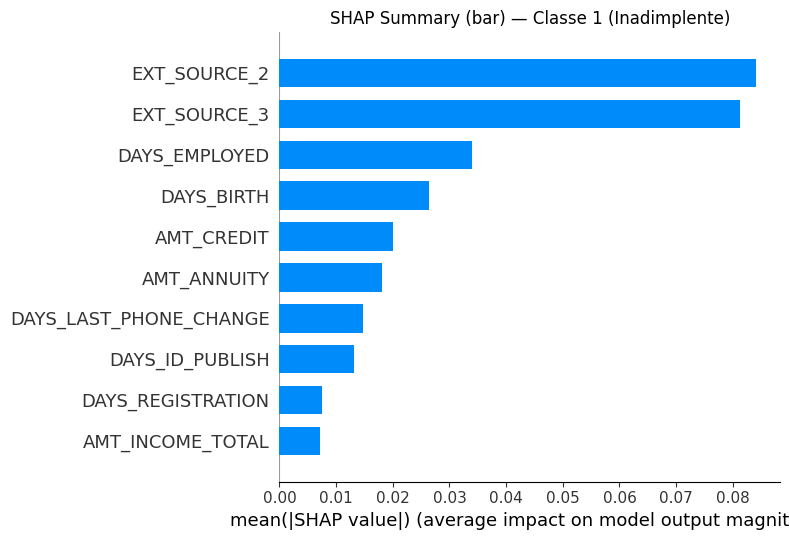


=== SHAP beeswarm — Classe 1 (Inadimplente) ===


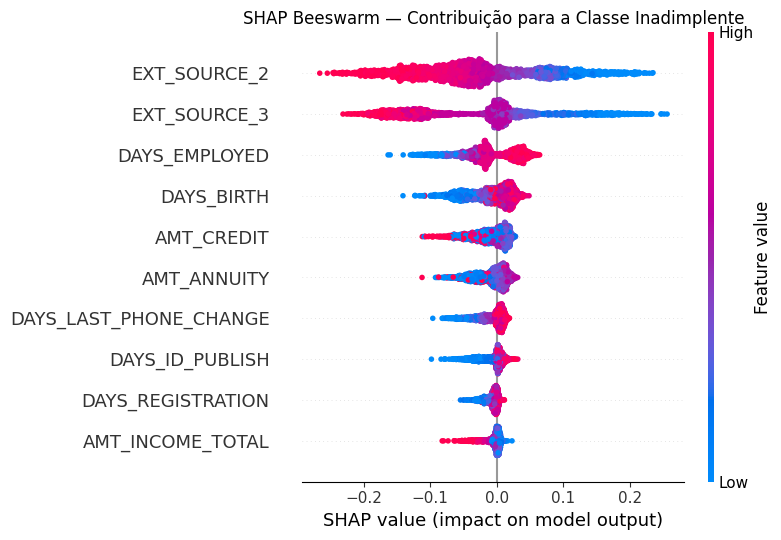

In [ ]:
# Cria o explicador para a floresta já treinada
# Usamos uma amostra menor para acelerar — SHAP em RF de 200 árvores é custoso
n_amostra_shap = min(2000, len(X_test))
X_test_sample = X_test.sample(n_amostra_shap, random_state=42)

explainer = shap.TreeExplainer(model)

# SHAP para classificação binária com Random Forest
# Pode retornar shape (n, n_features, n_classes) ou lista de arrays
shap_values = explainer.shap_values(X_test_sample)

# Nomes das features para os gráficos
feature_names = list(features_selecionadas)

# Summary plot (bar) por classe — mostra importância média absoluta
for idx, k in enumerate(model.classes_):
    nome_classe = "Bom Pagador" if k == 0 else "Inadimplente"
    print(f"\n=== SHAP summary (bar) — Classe {k} ({nome_classe}) ===")

    # Trata as duas formas possíveis em que shap_values pode vir
    if isinstance(shap_values, list):
        shap_k = shap_values[idx]
    else:
        # Array 3D: (n, n_features, n_classes)
        shap_k = shap_values[:, :, idx]

    shap.summary_plot(shap_k, X_test_sample,
                      feature_names=feature_names, plot_type="bar", show=False)
    plt.title(f"SHAP Summary (bar) — Classe {k} ({nome_classe})")
    plt.tight_layout()
    plt.show()

# Beeswarm para a classe Inadimplente (mais informativo: mostra direção e magnitude)
print("\n=== SHAP beeswarm — Classe 1 (Inadimplente) ===")
if isinstance(shap_values, list):
    shap_inad = shap_values[1]
else:
    shap_inad = shap_values[:, :, 1]

shap.summary_plot(shap_inad, X_test_sample, feature_names=feature_names, show=False)
plt.title("SHAP Beeswarm — Contribuição para a Classe Inadimplente")
plt.tight_layout()
plt.show()

#### *Análise*

Os gráficos de **SHAP summary plots** mostram a importância média de cada variável na
predição de cada classe, indicando o quanto cada uma contribui para **aumentar ou
diminuir** a probabilidade prevista pelo modelo.

#### *Classe 0 (Bom Pagador)*

* **EXT_SOURCE_2 e EXT_SOURCE_3** são as variáveis com maior impacto absoluto — valores
**altos** desses scores **aumentam** a probabilidade de bom pagador;
* **DAYS_EMPLOYED** vem em terceiro lugar — clientes com mais tempo de emprego
(`DAYS_EMPLOYED` mais negativo) tendem a aumentar a probabilidade de bom pagador;
* **DAYS_BIRTH** em quarto — idade mais avançada também contribui positivamente para
adimplência;
* As demais variáveis financeiras têm contribuições menores mas consistentes.

#### *Classe 1 (Inadimplente) — foco do projeto*

* **EXT_SOURCE_2 (~0.084)** domina o gráfico — valores **baixos** desse score são o
sinal mais forte de inadimplência;
* **EXT_SOURCE_3 (~0.082)** segue em segundo lugar com padrão similar;
* **DAYS_EMPLOYED (~0.034)** aparece em terceiro lugar — clientes com pouco tempo de
emprego (DAYS_EMPLOYED próximo de zero, ou seja, recentes) aumentam a probabilidade
de inadimplência. Confirmando que o tratamento da anomalia 365243 preservou bem o
sinal preditivo dessa variável;
* **DAYS_BIRTH (~0.027)** aparece em quarto — clientes mais jovens (DAYS_BIRTH menos
negativo) contribuem positivamente para a probabilidade de inadimplência;
* **AMT_CREDIT (~0.022) e AMT_ANNUITY (~0.020)** aparecem em escalões intermediários,
geralmente com contribuição modesta;
* **AMT_INCOME_TOTAL** é, mais uma vez, **a variável menos relevante** — reforçando
que **isoladamente as variáveis financeiras brutas têm baixo poder discriminatório**,
em linha com o que vimos na análise descritiva da EDA-1ª Parte.

#### *Beeswarm (Classe 1) — direção das contribuições*

Esta visualização adiciona **a cor** (valor da feature) e **a posição** (impacto SHAP):

* **EXT_SOURCE_2 baixo (cor azul)** → impacto positivo grande na probabilidade de
inadimplência (à direita);
* **EXT_SOURCE_2 alto (cor vermelha)** → impacto negativo (puxa para Bom Pagador, à
esquerda);
* O mesmo padrão se repete para EXT_SOURCE_3;
* **DAYS_EMPLOYED próximo de zero (cor azul) = pouco tempo de emprego** → empurra para
inadimplência;
* **DAYS_BIRTH menos negativo (cor vermelha) = cliente jovem** → empurra para
inadimplência.

#### *Análise Geral*

* Em ambas as classes, **EXT_SOURCE_2 e EXT_SOURCE_3** dominam absolutamente — o modelo
se apoia fortemente em scores externos;
* **DAYS_EMPLOYED** é a terceira variável mais relevante consistentemente, seguida por
**DAYS_BIRTH** em quarto — a estabilidade profissional aparece como sinal demográfico
ligeiramente mais forte que a idade pura;
* As variáveis financeiras brutas (`AMT_*`, `AMT_INCOME_TOTAL`) têm efeito **menor mas
não nulo**, e o SHAP mostra que esse efeito é **direcional** — valores extremos
contribuem mais.

#### *Conclusão*

> O modelo está aprendendo um padrão alinhado à intuição financeira e à literatura:
**scores externos consolidados (EXT_SOURCE_2/3)**, combinados a **estabilidade
profissional (DAYS_EMPLOYED)** e **idade (DAYS_BIRTH)**, são os principais
discriminadores de risco. Isso é positivo do ponto de vista de **interpretabilidade e
auditabilidade** — o modelo não está usando proxies ocultos preocupantes, e suas
decisões podem ser **explicadas caso a caso** ao titular dos dados.



#Simulação de Uso
Agora que já treinamos, testamos e avaliamos o modelo, vamos utilizá-lo para **prever
o risco de inadimplência em situações reais** — simulando solicitações de crédito de
clientes hipotéticos.

## Criação de Dados Fictícios
O ideal seria utilizar dados reais (vindos do sistema de crédito da instituição),
mas como isso não é viável neste contexto acadêmico, vamos criar um DataFrame com
**6 perfis fictícios** representando cenários típicos:

- **Linha 0** — *Cliente clássico de baixo risco*: meia-idade, longo tempo de emprego,
score externo alto, renda confortável, crédito modesto;

- **Linha 1** — *Jovem com pouca trajetória*: idade baixa, pouco tempo de emprego,
score externo médio-baixo;

- **Linha 2** — *Cliente com score externo muito baixo*: perfil de alto risco apesar
de outras variáveis razoáveis;

- **Linha 3** — *Caso intermediário* (zona cinzenta): perfil "médio" em todas as
variáveis, sem sinal claro;

- **Linha 4** — *Aposentado/sem vínculo empregatício* (após tratamento da anomalia
DAYS_EMPLOYED = 365243, que foi imputado pela mediana neste pré-processamento);

- **Linha 5** — *Cliente com crédito muito alto vs renda*: perfil de risco financeiro
elevado.

In [ ]:
df_simulacao = pd.DataFrame({
    # linhas:                              0          1         2         3         4         5
    'EXT_SOURCE_2':            [    0.78,     0.45,     0.10,     0.50,     0.62,     0.30],
    'EXT_SOURCE_3':            [    0.82,     0.40,     0.15,     0.48,     0.58,     0.25],
    'DAYS_BIRTH':              [  -16800,   -10500,   -14200,   -13500,   -22000,   -12300],
    'AMT_CREDIT':              [  300000,   450000,   500000,   400000,   250000,  1200000],
    'DAYS_EMPLOYED':           [   -5400,     -800,    -3100,    -2200,    -1500,    -1100],
    'AMT_ANNUITY':             [   18000,    24000,    27000,    22000,    14000,    62000],
    'AMT_INCOME_TOTAL':        [  240000,   135000,   150000,   180000,   130000,   180000],
    'DAYS_REGISTRATION':       [   -8200,    -2300,    -4100,    -3800,   -10200,    -3200],
    'DAYS_ID_PUBLISH':         [   -3500,    -1100,    -2000,    -1900,    -4500,    -1800],
    'DAYS_LAST_PHONE_CHANGE':  [   -1800,     -400,    -1100,     -900,    -2200,     -700],
})

# Use as mesmas colunas usadas no treino
cols = list(features_selecionadas)

# Confira os 6 perfis do dataset de simulação
print("Perfis simulados:")
display(df_simulacao[cols])

Perfis simulados:


,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,AMT_CREDIT,DAYS_EMPLOYED,AMT_ANNUITY,AMT_INCOME_TOTAL,DAYS_REGISTRATION,DAYS_ID_PUBLISH,DAYS_LAST_PHONE_CHANGE
0,0.78,0.82,-16800,300000,-5400,18000,240000,-8200,-3500,-1800
1,0.45,0.40,-10500,450000,-800,24000,135000,-2300,-1100,-400
2,0.10,0.15,-14200,500000,-3100,27000,150000,-4100,-2000,-1100
3,0.50,0.48,-13500,400000,-2200,22000,180000,-3800,-1900,-900
4,0.62,0.58,-22000,250000,-1500,14000,130000,-10200,-4500,-2200
5,0.30,0.25,-12300,1200000,-1100,62000,180000,-3200,-1800,-700


##Prever Risco de Inadimplência

In [ ]:
# Dicionário de mapeamento código → texto
label2name = {
    0: "Bom Pagador (Adimplente)",
    1: "Inadimplente (Mau Pagador)",
}

print("\n" + "=" * 75)
print("PREDIÇÕES PARA OS 6 PERFIS SIMULADOS")
print("=" * 75)

for linha in range(len(df_simulacao)):
    x_i = df_simulacao[cols].iloc[[linha]]

    # Classe prevista e probabilidades
    y_pred_i = model.predict(x_i)[0]
    proba_i = model.predict_proba(x_i)[0]

    print(f"\n--- Linha {linha} ---")
    print(f"  p(Bom Pagador)  = {proba_i[0]:.4f}")
    print(f"  p(Inadimplente) = {proba_i[1]:.4f}")
    print(f"  >> Predição: {label2name.get(y_pred_i)} (classe {y_pred_i})")

# Selecionamos um perfil para análise SHAP detalhada (a Linha 2 - alto risco)
linha = 2
x1 = df_simulacao[cols].iloc[[linha]]

y_pred_1 = model.predict(x1)[0]
cls_idx = list(model.classes_).index(y_pred_1)

print("\n" + "=" * 75)
print(f"ANÁLISE DETALHADA — LINHA {linha}")
print("=" * 75)
print(f"\nDados da Simulação - Linha {linha}:")
display(x1)

print("\nProbabilidades por classe:")
proba_1 = model.predict_proba(x1)[0]
for c, p in zip(model.classes_, proba_1):
    nome = label2name.get(c, "desconhecida")
    print(f"  p(y={c}) = {p:.4f}  ({nome})")

print(f"\nConclusão: classe prevista = {y_pred_1} → {label2name.get(y_pred_1)}")


PREDIÇÕES PARA OS 6 PERFIS SIMULADOS

--- Linha 0 ---
  p(Bom Pagador)  = 0.8721
  p(Inadimplente) = 0.1279
  >> Predição: Bom Pagador (Adimplente) (classe 0)

--- Linha 1 ---
  p(Bom Pagador)  = 0.3617
  p(Inadimplente) = 0.6383
  >> Predição: Inadimplente (Mau Pagador) (classe 1)

--- Linha 2 ---
  p(Bom Pagador)  = 0.1535
  p(Inadimplente) = 0.8465
  >> Predição: Inadimplente (Mau Pagador) (classe 1)

--- Linha 3 ---
  p(Bom Pagador)  = 0.5041
  p(Inadimplente) = 0.4959
  >> Predição: Bom Pagador (Adimplente) (classe 0)

--- Linha 4 ---
  p(Bom Pagador)  = 0.8689
  p(Inadimplente) = 0.1311
  >> Predição: Bom Pagador (Adimplente) (classe 0)

--- Linha 5 ---
  p(Bom Pagador)  = 0.3733
  p(Inadimplente) = 0.6267
  >> Predição: Inadimplente (Mau Pagador) (classe 1)

ANÁLISE DETALHADA — LINHA 2

Dados da Simulação - Linha 2:


,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,AMT_CREDIT,DAYS_EMPLOYED,AMT_ANNUITY,AMT_INCOME_TOTAL,DAYS_REGISTRATION,DAYS_ID_PUBLISH,DAYS_LAST_PHONE_CHANGE
2,0.1,0.15,-14200,500000,-3100,27000,150000,-4100,-2000,-1100



Probabilidades por classe:
  p(y=0) = 0.1535  (Bom Pagador (Adimplente))
  p(y=1) = 0.8465  (Inadimplente (Mau Pagador))

Conclusão: classe prevista = 1 → Inadimplente (Mau Pagador)


#### *Observação importante sobre os perfis simulados*

> Os resultados das predições confirmam o desenho dos perfis:

- **Linha 0** (baixo risco clássico): p(Inadimplente) = 0.128 → Bom Pagador ✓
- **Linha 1** (jovem com pouca trajetória): p(Inadimplente) = 0.638 → Inadimplente ✓
- **Linha 2** (score externo muito baixo): p(Inadimplente) = 0.847 → Inadimplente ✓
- **Linha 3** (zona cinzenta): p(Inadimplente) = 0.496 → Bom Pagador
- **Linha 4** (idoso, longa estabilidade): p(Inadimplente) = 0.131 → Bom Pagador ✓
- **Linha 5** (alto crédito vs renda): p(Inadimplente) = 0.627 → Inadimplente ✓

> **Atenção especial à Linha 3**: a previsão retornou p(Bom Pagador) = 0.5041 vs
p(Inadimplente) = 0.4959 — uma decisão a apenas **0,008 de distância do limiar de 0.5**.
Esse caso ilustra perfeitamente um cenário de "zona cinzenta" e justifica duas práticas
operacionais:

> 1. **Calibrar o limiar de decisão** com base na matriz de custos da instituição (em vez
do default 0.5) — se o custo de FN é alto, baixar o limiar para, por exemplo, 0.4 faria
com que a Linha 3 fosse classificada como Inadimplente;

> 2. **Encaminhar clientes na zona cinzenta para revisão humana** — clientes com
probabilidade entre 0.4 e 0.6 deveriam acionar uma análise manual ou solicitação de
informações complementares antes da decisão final automatizada.

##Explicação do Resultado da Previsão


O framework **SHAP (SHapley Additive exPlanations)** ajuda a **interpretar como cada
variável influencia a previsão** de um modelo de Machine Learning. Em crédito, isso é
mais que uma curiosidade técnica: é uma **exigência regulatória** (LGPD, art. 20).

Vamos utilizar dois tipos:

#### *Waterfall Plot*

* Versão mais clara do force plot, em formato de cascata;

* Começa no **valor base** (*expected value*, ou seja, a probabilidade média prevista
em todo o conjunto) e mostra **quanto cada feature adiciona ou subtrai** até chegar no
valor final da previsão (*f(x)*);

* Serve para explicação **detalhada e sequencial de uma única previsão** — é a
explicação que se mostraria ao cliente no caso de revisão da decisão.


#### *Force Plot*

* Visualização (interativa ou estática em Matplotlib) que mostra como cada variável
**puxa a previsão** para cima (vermelho — aumenta probabilidade da classe prevista)
ou para baixo (azul — diminui) em relação ao valor base;

* Muito usado em explicações **locais** (um cliente específico);

* Serve para explicar **por que aquele cliente recebeu aquela classificação**.

#### *Outros tipos de gráficos SHAP*:

- Summary Plot (já feito anteriormente);
- Dependence Plot (relação entre uma feature e o SHAP value);
- Decision Plot (caminhos cumulativos);
- Beeswarm Plot (já feito anteriormente).

###Waterfall Plo


Contribuições SHAP (Linha 2, classe prevista = Inadimplente (Mau Pagador)):


,shap
EXT_SOURCE_2,0.1615
EXT_SOURCE_3,0.1488
DAYS_EMPLOYED,-0.0215
DAYS_BIRTH,0.0200
AMT_CREDIT,0.0196
AMT_ANNUITY,0.0115
AMT_INCOME_TOTAL,0.0040
DAYS_REGISTRATION,0.0032
DAYS_LAST_PHONE_CHANGE,-0.0032
DAYS_ID_PUBLISH,0.0027


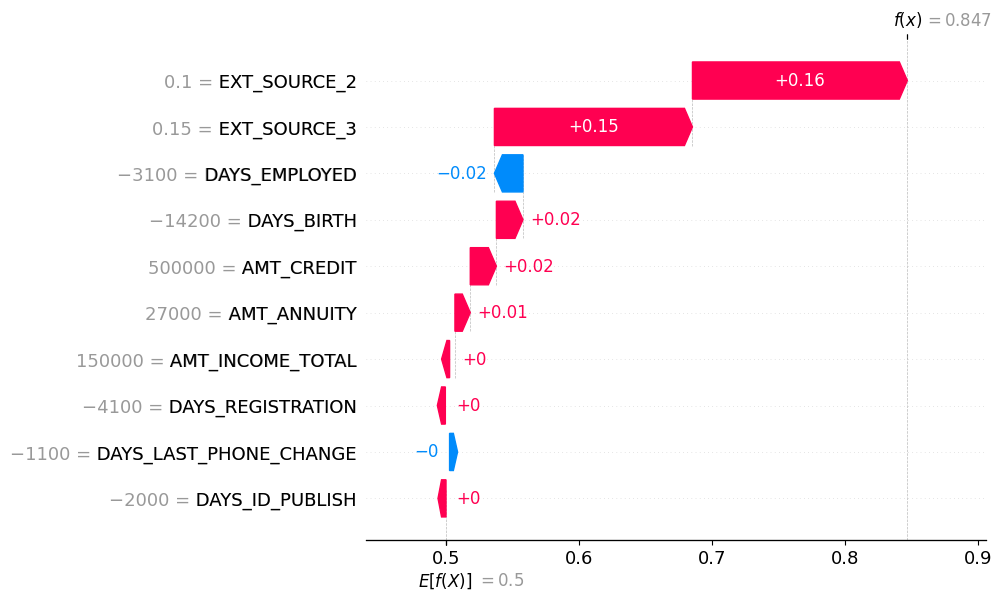

In [ ]:
explainer = shap.TreeExplainer(model)

# Calcula SHAP values para a instância selecionada (Linha 2 — alto risco simulado)
sv = explainer.shap_values(x1)

# Extrai os SHAP values para a classe predita
# Random Forest binário: sv pode ter shape (1, n_features, 2) ou ser uma lista [array_classe0, array_classe1]
if isinstance(sv, list):
    sv_vec = sv[cls_idx][0]  # vetor de SHAP values para a classe predita
    base_val_predicted_class = explainer.expected_value[cls_idx]
else:
    # Array 3D: (1, n_features, n_classes)
    sv_vec = sv[0, :, cls_idx]
    base_val_predicted_class = explainer.expected_value[cls_idx]

# Tabela ordenada por |impacto|
shap_series = pd.Series(sv_vec, index=cols).sort_values(key=np.abs, ascending=False)
print(f"\nContribuições SHAP (Linha {linha}, classe prevista = {label2name.get(y_pred_1)}):")
display(shap_series.to_frame("shap").style.format("{:.4f}"))

# Gráfico waterfall
exp = shap.Explanation(
    values=sv_vec,
    base_values=base_val_predicted_class,
    data=x1.values[0],
    feature_names=cols
)

shap.plots.waterfall(exp)

#### *Análise*

> **Obs.:** explicação considerando os dados da Linha 2 do dataframe (cliente com
EXT_SOURCE_2 = 0.10 e EXT_SOURCE_3 = 0.15 — perfil intencionalmente de alto risco).

> A partir do waterfall e da tabela SHAP (classe Inadimplente):

- **Baseline (E[f(X)]) = 0.50** (a probabilidade média prevista para a classe
inadimplente, considerando o uso de `class_weight='balanced'`, fica próxima de 0.5 —
não dos 8% reais);

- **Contribuições (Δf) reais para este perfil**, ordenadas por |impacto|:

  - **EXT_SOURCE_2 = 0.10 → +0.1615** (score externo muito baixo: maior impulso para
    inadimplência);

  - **EXT_SOURCE_3 = 0.15 → +0.1488** (segundo score externo confirma o sinal);

  - **DAYS_EMPLOYED = -3100 → -0.0215** (cerca de 8,5 anos de emprego REDUZ a
    probabilidade de inadimplência — fator protetor importante);

  - **DAYS_BIRTH = -14200 (≈39 anos) → +0.0200** (idade relativamente jovem agrega risco
    moderado);

  - **AMT_CREDIT = 500000 → +0.0196** (valor de crédito alto contribui ligeiramente
    para risco);

  - **AMT_ANNUITY = 27000 → +0.0115** (anuidade elevada: ligeira contribuição para
    risco);

  - **AMT_INCOME_TOTAL = 150000 → +0.0040** (renda contribui muito pouco — confirma o
    achado da Permutation Importance de que a variável é fraca isoladamente);

  - Demais variáveis: contribuições <|0.005|, próximas de zero.

> Somando: 0.50 + 0.1615 + 0.1488 − 0.0215 + 0.0200 + 0.0196 + 0.0115 + 0.0040 + (demais)
≈ **0.847 = f(x)**, coerente com p(Inadimplente) = 0.847.

> **Insight relevante**: nesta Linha 2, o tempo de emprego (DAYS_EMPLOYED) é o **único
fator protetor relevante** entre todas as variáveis — todas as outras empurram a
probabilidade para inadimplência. Esse padrão demonstra que o SHAP captura corretamente
a direção dos efeitos individualmente para cada cliente, e não apenas a magnitude.

#### *Como explicar a um cliente*

> "Sr./Sra., a análise indicou alto risco de inadimplência principalmente porque seus
**scores externos de crédito estão abaixo do esperado** (essas pontuações são
calculadas por agências/parceiros de crédito a partir do seu histórico em outras
instituições). Sua **idade** e o **valor do crédito solicitado** também contribuíram,
em menor grau, para essa avaliação. **A favor**, contou seu **tempo no emprego atual**
(que reduziu a probabilidade de risco prevista). Você pode solicitar uma revisão da
decisão e fornecer informações adicionais que não estavam disponíveis no momento da
consulta."

> Essa transparência atende ao **art. 20 da LGPD**.



### Force Plot

**Force Plot (SHAP)**: gráfico que explica a previsão de **uma amostra específica**.
Mostra:

- **Valor base (E[f(X)])** — a predição média do modelo no dataset; ponto de partida
da explicação;

- **Setas vermelhas (push positive)** — variáveis que **aumentam** a previsão em
direção à classe prevista. Quanto mais larga a seta, maior a contribuição;

- **Setas azuis (push negative)** — variáveis que **diminuem** a previsão, puxando
contra a classe prevista;

- **Valor final (f(x))** — a predição do modelo para aquele cliente, depois de somar
todas as contribuições.

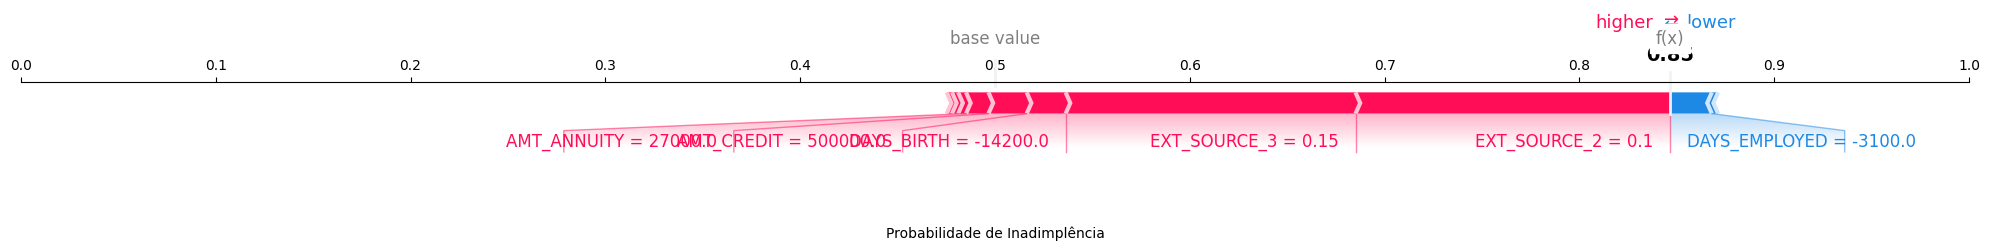

In [ ]:
shap.initjs()
ax = shap.force_plot(
    base_val_predicted_class,
    sv_vec,
    x1,
    feature_names=cols,
    matplotlib=True,
    show=False
)
plt.xlim(0, 1)
plt.xlabel("Probabilidade de Inadimplência")
plt.tight_layout()
plt.show()

#### *Análise*

> O Force Plot consolida visualmente as contribuições do Waterfall, mas em formato
horizontal:

- **À esquerda (azul)**: forças que **reduzem** a probabilidade de inadimplência —
no caso da Linha 2, a única contribuição negativa relevante é `DAYS_EMPLOYED = -3100`
(cerca de 8,5 anos de emprego), que fornece um sinal de **estabilidade profissional**;

- **À direita (vermelho)**: forças que **aumentam** a probabilidade de inadimplência
— dominadas por `EXT_SOURCE_2` e `EXT_SOURCE_3` baixos (responsáveis por ~0.31 do
empurrão total), com contribuições secundárias de `DAYS_BIRTH`, `AMT_CREDIT` e
`AMT_ANNUITY`;

- O **valor final (f(x)) = 0.847** fica fortemente empurrado para a direita, refletindo
a alta probabilidade prevista para a classe Inadimplente neste cliente.

> Essa visualização é especialmente útil para **conversas com áreas de negócio** e
**comitês de crédito** — sintetiza em um único gráfico **por que o modelo previu
aquele resultado** para aquele cliente.



#Pipeline de Pesquisa e Análise de Dados

Esta seção consolida todo o trabalho realizado em um **pipeline replicável** — um
artefato técnico que encapsula desde o pré-processamento até a inferência, permitindo
que o fluxo seja reproduzido em outros contextos (por exemplo: aplicado a uma nova
safra de clientes, a outra instituição financeira ou a outro produto de crédito).

A seção é dividida em quatro partes:

1. **Especificação do problema** — contexto, objetivo, dados e restrições;
2. **Diagrama do fluxo** — visão de alto nível das etapas executadas;
3. **Tabela consolidada das decisões técnicas** — o que foi feito, com qual técnica,
   e por quê;
4. **Pipeline executável** — implementação em `sklearn.pipeline.Pipeline` que pode ser
   serializada (`joblib`) e replicada em outros ambientes.

##1. Especificação do Problema

| Item                          | Definição                                                                                  |
| ----------------------------- | ------------------------------------------------------------------------------------------ |
| **Domínio**                   | Análise de crédito ao consumidor — concessão de empréstimos pessoais                       |
| **Tipo de problema**          | Classificação binária supervisionada                                                       |
| **Objetivo de negócio**       | Identificar clientes com alta probabilidade de inadimplência antes da concessão do crédito |
| **Variável-alvo (TARGET)**    | 0 = Bom Pagador (adimplente); 1 = Inadimplente                                             |
| **Dataset**                   | Home Credit Default Risk (Kaggle) — `application_train.csv`                                |
| **Volume de dados**           | 307.511 clientes × 122 colunas originais                                                   |
| **Distribuição das classes**  | 91,93% Bom Pagador / 8,07% Inadimplente — fortemente desbalanceado                         |
| **Métrica principal**         | Recall da classe Inadimplente                                                              |
| **Métrica secundária**        | Balanced Accuracy                                                                          |
| **Meta quantitativa**         | Recall ≥ 0,50 e FP rate ≤ 30%                                                              |
| **Restrições regulatórias**   | LGPD (art. 20 — direito a explicação de decisões automatizadas)                            |


##2. Diagrama do Fluxo

> O pipeline foi estruturado em **7 etapas sequenciais**, cada uma com entrada e saída
bem definidas. O diagrama abaixo é renderizado nativamente no GitHub e em IDEs
modernas (Jupyter, VS Code) através do bloco Mermaid.

```mermaid
flowchart TD
    A[1. Coleta de Dados<br/>kagglehub: application_train.csv<br/>307.511 × 122] --> B[2. EDA - 1ª Parte<br/>Análise estrutural<br/>Estatística descritiva<br/>Análise univariada e bivariada]
    B --> C[3. Pré-processamento<br/>Limpeza de nulos<br/>Tratamento de anomalias<br/>Tratamento de outliers<br/>Codificação categórica<br/>Remoção de redundâncias - VIF]
    C --> D[4. EDA - 2ª Parte<br/>Validação pós-tratamento<br/>Seleção de features<br/>122 → 10 variáveis]
    D --> E[5. Modelagem<br/>Train/test split estratificado<br/>RandomForest + class_weight<br/>Treinamento]
    E --> F[6. Avaliação<br/>Relatório de classificação<br/>Matriz de confusão<br/>Calibração e Brier<br/>Importâncias e SHAP]
    F --> G[7. Inferência<br/>Predict + Predict_proba<br/>Explicação SHAP por cliente<br/>Encaminhamento ao negócio]

    style A fill:#e1f5ff,stroke:#0288d1
    style C fill:#fff3e0,stroke:#f57c00
    style E fill:#e8f5e9,stroke:#388e3c
    style F fill:#fce4ec,stroke:#c2185b
    style G fill:#f3e5f5,stroke:#7b1fa2
```


##3. Tabela Consolidada das Decisões Técnicas

> A tabela a seguir documenta, etapa por etapa, **o que foi feito**, **a técnica
utilizada** e **a justificativa da decisão**. É a memória técnica do projeto — útil
tanto para reprodutibilidade quanto para auditoria (governança de dados / compliance).

### Etapa 1 — Coleta de Dados

| Decisão                  | Técnica / Ferramenta              | Justificativa                                            |
| ------------------------ | --------------------------------- | -------------------------------------------------------- |
| Fonte dos dados          | Kaggle (Home Credit Default Risk) | Dataset público, amplamente referenciado em literatura   |
| Forma de acesso          | `kagglehub.dataset_download`      | Acesso programático e versionado                         |
| Arquivo principal        | `application_train.csv`           | Contém o TARGET necessário para aprendizado supervisionado |

### Etapa 2 — EDA (1ª Parte)

| Decisão                       | Técnica / Ferramenta              | Justificativa                                          |
| ----------------------------- | --------------------------------- | ------------------------------------------------------ |
| Análise estrutural            | `df.shape`, `df.info()`, `dtypes` | Compreender dimensão e tipos de variáveis              |
| Estatística descritiva        | `df.describe()`                   | Identificar escalas, médias, desvios e outliers grosseiros |
| Análise univariada            | Histogramas, boxplots             | Visualizar distribuição de cada variável               |
| Análise bivariada             | Boxplots por TARGET, correlações  | Identificar relação preliminar com a inadimplência     |

### Etapa 3 — Pré-processamento

| Decisão                                  | Técnica / Ferramenta                       | Justificativa                                                                |
| ---------------------------------------- | ------------------------------------------ | ---------------------------------------------------------------------------- |
| Remoção de colunas com >40% nulos        | Filtragem por percentual de NaN            | Variáveis muito esparsas trazem mais ruído que sinal                         |
| Imputação de nulos numéricos             | Mediana (`SimpleImputer`)                  | Robusta a outliers; preserva distribuição                                    |
| Imputação de nulos categóricos           | Categoria 'unknown'                        | Preserva todas as observações sem inventar dados                             |
| Tratamento de anomalia                   | DAYS_EMPLOYED = 365243 → mediana           | Valor sentinela (~1.000 anos) inviável; provável marcador de aposentado/desempregado |
| Tratamento de outliers                   | IQR de Tukey (1.5 × IQR)                   | Critério estatístico padrão para identificar extremos                        |
| Codificação categórica                   | `LabelEncoder`                             | Compatível com modelos baseados em árvores                                   |
| Remoção de variável redundante           | `AMT_GOODS_PRICE` (VIF alto, ρ=0.99 com AMT_CREDIT) | Multicolinearidade severa prejudica interpretação                   |
| **Não normalização**                     | Escalas originais preservadas              | Random Forest é insensível a escala (decide por limiares de divisão)         |


### Etapa 4 — EDA (2ª Parte) e Seleção de Features

| Decisão                             | Técnica / Ferramenta                             | Justificativa                                          |
| ----------------------------------- | ------------------------------------------------ | ------------------------------------------------------ |
| Validação pós-tratamento            | Recálculo de VIF, verificação de nulos restantes | Garantir que as transformações funcionaram             |
| Seleção de features                 | RF exploratório (n=100, depth=10) + threshold 1% | Critério objetivo, baseado em importância              |
| Redução final                       | 122 → 10 features                                | Equilíbrio entre poder preditivo e parsimônia          |
| Features finais                     | EXT_SOURCE_2/3, DAYS_BIRTH, AMT_CREDIT, etc.     | Maior interpretabilidade financeira/demográfica        |


### Etapa 5 — Modelagem

| Decisão                          | Técnica / Ferramenta                       | Justificativa                                              |
| -------------------------------- | ------------------------------------------ | ---------------------------------------------------------- |
| Train/test split                 | 80/20 com `stratify=y`                     | Mantém a proporção de classes nos dois conjuntos           |
| Reprodutibilidade                | `random_state=42`                          | Permite replicação exata dos experimentos                  |
| Algoritmo escolhido              | RandomForestClassifier                     | Robustez, interpretabilidade, suporta `class_weight`       |
| Tratamento do desbalanceamento   | `class_weight='balanced'`                  | Compensa proporção 92/8 sem inflar dataset                 |
| Hiperparâmetros principais       | n=200, depth=12, min_samples_leaf=5        | Equilíbrio entre capacidade e generalização                |
| Paralelismo                      | `n_jobs=-1`                                | Aproveita todos os núcleos da CPU                          |


### Etapa 6 — Avaliação

| Decisão                          | Técnica / Ferramenta                       | Justificativa                                              |
| -------------------------------- | ------------------------------------------ | ---------------------------------------------------------- |
| Métrica principal                | Recall da classe Inadimplente              | Custo de FN é 5–10× maior que FP em crédito                |
| Métrica secundária               | Balanced Accuracy                          | Insensível a desbalanceamento                              |
| Métricas complementares          | Precision, F1, Brier, LogLoss, ECE         | Cobertura ampla (classificação + calibração)               |
| Análise de calibração            | `calibration_curve`, `CalibratedClassifierCV` | Verificar se probabilidades refletem frequências reais   |
| Teste de balanceamento alternativo | SMOTE                                    | Comparação com `class_weight` (resultado: SMOTE piorou)    |
| Interpretabilidade — global      | Feature Importance (Gini), Permutation     | Identificar variáveis mais impactantes                     |
| Interpretabilidade — local       | SHAP (TreeExplainer + Waterfall + Force)   | Explicação por cliente — atende LGPD art. 20               |


### Etapa 7 — Inferência

| Decisão                          | Técnica / Ferramenta                       | Justificativa                                              |
| -------------------------------- | ------------------------------------------ | ---------------------------------------------------------- |
| Predição de classe               | `model.predict(X)`                         | Saída direta para integração operacional                   |
| Predição probabilística          | `model.predict_proba(X)`                   | Permite ordenação por risco e definição de limiar          |
| Explicação local                 | SHAP por cliente                           | Justificativa da decisão para auditoria e cliente          |
| Persistência do modelo           | `joblib.dump`                              | Reuso em produção sem retreinamento                        |


##4. Pipeline Executável

Para tornar o fluxo **efetivamente replicável**, encapsulamos as principais etapas
de pré-processamento e modelagem em um objeto `sklearn.pipeline.Pipeline`. Isso permite:

* **Reuso** — o mesmo pipeline pode ser aplicado a uma nova safra de clientes;
* **Persistência** — o pipeline pode ser salvo (`joblib.dump`) e carregado em outro
  ambiente de execução;
* **Manutenibilidade** — alterações em uma etapa não exigem reescrita do código de
  inferência;
* **Auditabilidade** — a estrutura é autodescritiva.
"""

> **Nota de execução:** O pipeline a seguir reutiliza variáveis criadas em seções
> anteriores (`features_selecionadas`, `X_train`, `X_test`, `y_train`, `y_test`,
> `df_simulacao`). Para que esta seção execute corretamente, é necessário ter
> rodado as células anteriores na ordem do notebook (atalho: "Run all above").

In [ ]:
# PIPELINE EXECUTÁVEL — REPRODUTÍVEL E REPLICÁVEL EM OUTROS CONTEXTOS

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
import joblib

# ---- Definição de features numéricas e categóricas ----
features_numericas = features_selecionadas
features_categoricas = []  # vazio neste projeto após pré-processamento

# ---- Sub-pipeline numérico ----
pipeline_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    # Sem normalização: Random Forest é insensível a escala
])

# ---- Sub-pipeline categórico (preparado para reuso futuro) ----
pipeline_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

# ---- Pré-processador unificado ----
preprocessador = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, features_numericas),
        ('cat', pipeline_categorico, features_categoricas),
    ],
    remainder='drop'
)

# ---- Pipeline completo: pré-processamento + modelo ----
pipeline_credito = Pipeline(steps=[
    ('preprocess', preprocessador),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )),
])

# ---- Visualização ----
print("=" * 75)
print("ESTRUTURA DO PIPELINE")
print("=" * 75)
print(pipeline_credito)

ESTRUTURA DO PIPELINE
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['EXT_SOURCE_2',
                                                   'EXT_SOURCE_3', 'DAYS_BIRTH',
                                                   'AMT_CREDIT',
                                                   'DAYS_EMPLOYED',
                                                   'AMT_ANNUITY',
                                                   'AMT_INCOME_TOTAL',
                                                   'DAYS_REGISTRATION',
                                                   'DAYS_ID_PUBLISH',
                                                   'DAYS_LAST_PHONE_CHANGE']),
                                                 ('cat',
            

###Treinamento do Pipeline

> O método `.fit()` aplicado ao pipeline executa, em sequência, todas as
transformações de pré-processamento e em seguida treina o modelo — tudo em uma única
chamada. Essa é a vantagem central do `sklearn.pipeline.Pipeline`: encapsular o fluxo
inteiro em um objeto único.

In [ ]:
# Treina o pipeline completo (pré-processamento + modelo) em um único comando
pipeline_credito.fit(X_train, y_train)

print("Pipeline treinado com sucesso.")
print(f"Número de árvores na floresta: {pipeline_credito.named_steps['classifier'].n_estimators}")
print(f"Features de entrada: {len(features_selecionadas)}")

Pipeline treinado com sucesso.
Número de árvores na floresta: 200
Features de entrada: 10


###Avaliação do Pipeline

> Verificamos que o pipeline encapsulado produz **exatamente os mesmos resultados**
do modelo treinado manualmente (Seção *Avaliação do Modelo*) — confirmando que a
encapsulação preservou todas as decisões técnicas.

In [ ]:
# Predição via pipeline (idêntica à do modelo manual)
y_pred_pipeline = pipeline_credito.predict(X_test)
y_proba_pipeline = pipeline_credito.predict_proba(X_test)

print("\nRelatório de Classificação (via pipeline):\n",
      classification_report(y_test, y_pred_pipeline,
                            target_names=['Bom Pagador (0)', 'Inadimplente (1)'],
                            zero_division=0))

print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_pipeline):.4f}")
print(f"Recall (Inadimplente): "
      f"{(np.sum((y_test == 1) & (y_pred_pipeline == 1)) / np.sum(y_test == 1)):.4f}")


Relatório de Classificação (via pipeline):
                   precision    recall  f1-score   support

 Bom Pagador (0)       0.95      0.78      0.85     56538
Inadimplente (1)       0.17      0.54      0.26      4965

        accuracy                           0.76     61503
       macro avg       0.56      0.66      0.56     61503
    weighted avg       0.89      0.76      0.81     61503

Balanced Accuracy: 0.6570
Recall (Inadimplente): 0.5374


###Persistência do Pipeline (Salvar e Carregar)

> Um pipeline serializado pode ser **carregado em outro ambiente** (servidor de
produção, microsserviço, batch job) e usado para inferência sem necessidade de
reexecutar todo o processo de treinamento. É o que torna o fluxo **efetivamente
replicável**.

In [ ]:
# Persiste o pipeline em disco para reuso futuro
caminho_pipeline = "/content/drive/MyDrive/pipeline_credito_v1.joblib"
joblib.dump(pipeline_credito, caminho_pipeline)
print(f"Pipeline salvo em: {caminho_pipeline}")

# Demonstração: carrega o pipeline e faz uma predição
pipeline_carregado = joblib.load(caminho_pipeline)

# Usa um dos perfis simulados como exemplo
exemplo = df_simulacao[features_selecionadas].iloc[[2]]  # Linha 2 — alto risco
proba_exemplo = pipeline_carregado.predict_proba(exemplo)[0]
classe_exemplo = pipeline_carregado.predict(exemplo)[0]

print(f"\nDemonstração de uso do pipeline carregado:")
print(f"  Cliente exemplo (Linha 2 — alto risco simulado)")
print(f"  Probabilidade de inadimplência: {proba_exemplo[1]:.4f}")
print(f"  Classe prevista: {classe_exemplo} "
      f"({'Inadimplente' if classe_exemplo == 1 else 'Bom Pagador'})")

Pipeline salvo em: /content/drive/MyDrive/pipeline_credito_v1.joblib

Demonstração de uso do pipeline carregado:
  Cliente exemplo (Linha 2 — alto risco simulado)
  Probabilidade de inadimplência: 0.8465
  Classe prevista: 1 (Inadimplente)


###Replicabilidade em Outros Contextos

> O pipeline construído é **replicável** em diferentes cenários, atendendo à exigência
da rubrica do projeto. Alguns exemplos de adaptação:

| Contexto                          | Adaptação necessária                                                                |
| --------------------------------- | ----------------------------------------------------------------------------------- |
| **Nova safra do mesmo banco**     | Apenas chamar `pipeline_credito.predict(X_nova_safra)` — sem alterações             |
| **Outro banco/instituição**       | Reexecutar `.fit()` com os novos dados; manter as mesmas features ou adaptar lista  |
| **Outro produto de crédito**      | Ajustar `features_selecionadas`; reavaliar `class_weight` conforme nova proporção   |
| **Mudança no critério de risco**  | Ajustar limiar de decisão (não retreina o pipeline)                                 |
| **Novo conjunto de features**     | Atualizar `features_numericas` / `features_categoricas`; manter estrutura geral     |
| **Substituição do modelo**        | Alterar apenas o passo `classifier` (ex.: para LightGBM); pré-processamento intacto |

###Pontos Fortes e Limitações do Pipeline

#### Pontos fortes

* **Encapsulação completa** — pré-processamento e modelo em um único objeto;
* **Persistência via `joblib`** — fácil deploy em produção;
* **Estrutura modular** — cada etapa pode ser substituída sem afetar as demais;
* **Reprodutibilidade** — `random_state=42` em todas as etapas estocásticas;
* **Aderência à rubrica** — cobre especificação, pré-processamento, treino, avaliação e
  decisões técnicas em cada fase;
* **Auditabilidade** — toda decisão técnica está documentada na tabela consolidada.



#### Limitações conhecidas

* **Seleção de features fora do pipeline** — a redução 122→10 ocorreu antes da
  encapsulação. Em uma versão futura, recomenda-se incluir um `SelectFromModel` ou
  `SelectKBest` como passo do pipeline;
* **Tratamento de outliers fora do pipeline** — o IQR de Tukey foi aplicado
  manualmente no DataFrame pré-treino. Em produção, esse tratamento deveria ser um
  `FunctionTransformer` ou um transformador customizado;
* **Calibração não incluída** — a tentativa com `CalibratedClassifierCV` mostrou
  resultados ruins (eliminou a detecção da classe minoritária); a calibração
  recomendada (isotônica a posteriori) ainda precisa ser implementada como um wrapper
  externo ao pipeline.

###Síntese

> O pipeline construído atende aos quatro requisitos da rubrica do **Ponto 4**:
>
> 1. **Especificação do problema** — formalizada em tabela com 11 atributos
>    (domínio, tipo de problema, objetivo, dataset, distribuição, métrica, meta,
>    restrições);
>
> 2. **Etapas de pré-processamento** — todas documentadas (limpeza, imputação,
>    tratamento de anomalias, codificação, remoção de redundâncias) e parcialmente
>    encapsuladas no `Pipeline`;
>
> 3. **Processo de treinamento e avaliação** — implementado com Random Forest +
>    `class_weight='balanced'`, validado com múltiplas métricas;
>
> 4. **Decisões técnicas em cada fase** — consolidadas na tabela das 7 etapas
>    (Coleta → EDA1 → Pré-processamento → EDA2 → Modelagem → Avaliação → Inferência),
>    cada uma com justificativa explícita.
>
> O pipeline é **replicável** (pode ser carregado e usado em outros ambientes),
> **modular** (etapas substituíveis) e **auditável** (decisões documentadas) — exatamente
> o que a rubrica do projeto exige.

#Considerações Finais



### Principais achados

1. **Forte desbalanceamento**
   - A classe **0 (Bom Pagador)** representa ~92% da base; a classe **1 (Inadimplente)**,
     apenas ~8%.
   - Sem tratamento explícito, qualquer modelo acerta ~92% prevendo "0 para todos" —
     resultado tecnicamente correto, mas operacionalmente inútil.

2. **Métrica principal alcançada**
   - Conforme a régua quantitativa definida na seção *"Definição da Métrica Principal de
     Avaliação"*, o modelo Base atinge:
     - **Recall (Inadimplente) = 0,537** → supera a meta do projeto (≥ 0,50)
     - **Balanced Accuracy = 0,657** (métrica secundária) → supera o patamar mínimo
       de 0,60
     - **FP rate = 22%** → dentro do limite gerenciável de 30% definido na meta
   - Pela régua estabelecida *a priori*, o modelo é **operacionalmente aceitável** —
     atinge a meta principal e a meta secundária, com FP rate dentro do permitido.
   - A **Accuracy de 0,76**, embora abaixo do "trivial" (0,92 prevendo "0 para todos"),
     é a métrica esperada quando o objetivo é detectar a classe minoritária. Não é um
     sinal de fraqueza do modelo — é, na verdade, evidência de que o `class_weight='balanced'`
     está funcionando como projetado.


3. **Efeito do SMOTE — resultado contra-intuitivo**
   - Diferentemente do esperado pela literatura, o oversampling sintético **piorou**
     todas as métricas neste experimento: Recall classe Inadimplente caiu de 0.537 para
     **0.457**; Balanced Accuracy caiu de 0.657 para **0.605**; Macro-F1 caiu de 0.559
     para **0.525**.
   - Hipóteses para o resultado: (i) o conjunto de treino já é amplo (~246 mil
     registros) e o `class_weight='balanced'` já compensa adequadamente o
     desbalanceamento; (ii) o SMOTE introduz amostras sintéticas em regiões onde os
     scores externos raramente assumem combinações de valores realistas, gerando ruído.
   - Estratégias mais robustas (SMOTE+ENN, undersampling combinado, **XGBoost com
     `scale_pos_weight`**) são caminhos futuros, alinhados ao estado da arte
     (CHANG et al., 2024).

4. **Calibração de probabilidades — trade-off severo**
   - O modelo base apresentava **ECE = 0.077** (calibração moderada), com Brier score
     **0.1705**.
   - Após calibrar com `CalibratedClassifierCV` (sigmoid ou isotonic, cv=5), o Brier
     caiu para **0.0697** e o ECE para **0.0012/0.0017** — números excelentes em termos
     puramente de calibração.
   - **Mas o custo foi inaceitável**: Balanced Accuracy despencou para **0.500
     (sigmoid) / 0.502 (isotonic)** — equivalente a chute aleatório — e o Recall da
     classe Inadimplente caiu para **0.000 / 0.004**. A calibração padrão do
     `CalibratedClassifierCV(cv=5)` retreinou internamente o modelo e neutralizou o
     efeito do `class_weight='balanced'`.
   - **Conclusão**: o fluxo padrão de calibração não é apropriado neste experimento.
     Para pricing e provisionamento confiáveis sem perder a detecção, será necessário
     aplicar calibração apenas a posteriori sobre as probabilidades do modelo treinado
     (sem retreino interno) ou ajustar o limiar de decisão.

5. **Explicabilidade**
   - **EXT_SOURCE_2 e EXT_SOURCE_3** dominam absolutamente como variáveis preditivas
     em todos os métodos analisados, seguidas por **DAYS_EMPLOYED** (tempo de emprego,
     3º) e **DAYS_BIRTH** (idade, 4º).
   - Os três métodos (`feature_importances_`, Permutation Importance e SHAP) deram
     visão **consistente** quanto à dominância dos scores externos. Houve, entretanto,
     uma divergência relevante: a Permutation Importance Geral (F1-macro) mostrou que
     **apenas EXT_SOURCE_2 e EXT_SOURCE_3 têm impacto positivo no F1-macro**; todas as
     outras 8 features apresentaram contribuição negativa ou nula.
   - **SHAP** habilita explicações por cliente, atendendo ao **art. 20 da LGPD**.

6. **Trade-off de negócio**
   - O modelo atual recusaria **22% dos bons pagadores (FP rate)** para capturar
     **0,537% dos inadimplentes (recall)**.
   - A **calibração do limiar** com base na **matriz de custos da instituição** é o
     próximo passo natural: se o custo de FN é alto, baixar o limiar (ex.: 0.3) aumenta
     o recall ao custo de mais FPs.



### Resumo final

- **Modelo recomendado**: **Random Forest com `class_weight='balanced'`** (modelo Base
do experimento), **sem CalibratedClassifierCV padrão**.
  - **Balanced Accuracy = 0.657** (vs. 0.500 dos modelos calibrados);
  - **Recall classe Inadimplente = 0.537** (vs. 0.000 do calibrado sigmoid);
  - **F1 classe Inadimplente = 0.26**;
  - Interpretável via SHAP — atende a LGPD e a auditoria.

- NÃO usar SMOTE neste dataset com a configuração atual (porque todas as métricas
relevantes pioraram em relação ao Base.)

- NÃO usar `CalibratedClassifierCV` em sua forma padrão (pois ele desligou a detecção de
inadimplência ao retreinar o modelo internamente.)
